# **Tahap Modeling pada Dataset CIC IoT 2023**

## **Langkah 1: Import Library, Mount Google Drive, dan Setup**

####**Import Library**

In [ ]:
pip install shap

In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])

0

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import os, gc, json, time, pickle
import psutil
from datetime import datetime
from collections import Counter

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix, classification_report,
    roc_auc_score, average_precision_score
)
from sklearn.inspection import permutation_importance

# XGBoost & LightGBM
import xgboost as xgb
import lightgbm as lgb

# Imbalanced-learn (untuk Borderline-SMOTE)
from imblearn.over_sampling import BorderlineSMOTE

# PyTorch untuk CVAE
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# TensorFlow/Keras untuk DNN Classifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Cek GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" PyTorch device: {device}")

# Cek TensorFlow GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f" TensorFlow GPU tersedia: {len(gpus)} GPU")
else:
    print(" TensorFlow menggunakan CPU")
print(" Library Deep Learning berhasil di-import")

# Import Library untuk EFI (Ensemble Feature Importance)
# SHAP untuk feature importance
try:
    import shap
    print(" SHAP tersedia")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap
    print("SHAP berhasil diinstal.")

print("Library EFI berhasil di-import")


# Import Library Visualisasi
# Scikit-learn untuk dimensionality reduction
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Scipy untuk statistical tests
from scipy import stats
from scipy.stats import ks_2samp

print(" Library Visualisasi berhasil di-import")

 PyTorch device: cuda
 TensorFlow GPU tersedia: 1 GPU
 Library Deep Learning berhasil di-import
 SHAP tersedia
Library EFI berhasil di-import
 Library Visualisasi berhasil di-import


####**Mount GDrive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive berhasil di-mount!")

Mounted at /content/drive
Google Drive berhasil di-mount!


####**Setup Folder/Paths**

In [ ]:
# Baseline Paths (Read-only)
BASELINE_PROCESSED_DIR = '/content/drive/My Drive/Baseline/Processed_Data/'
BASELINE_RESULTS_DIR = '/content/drive/My Drive/Baseline/Results/'

# Framework Paths(Read-Write)
FRAMEWORK_BASE_DIR = '/content/drive/My Drive/Framework/CICIoT2023/'
FRAMEWORK_CHECKPOINTS_DIR = os.path.join(FRAMEWORK_BASE_DIR, 'Checkpoints/')
FRAMEWORK_MODELS_DIR = os.path.join(FRAMEWORK_BASE_DIR, 'Models/')
FRAMEWORK_RESULTS_DIR = os.path.join(FRAMEWORK_BASE_DIR, 'Results/')

# Subdirektori untuk checkpoints
GIR_DIR = os.path.join(FRAMEWORK_CHECKPOINTS_DIR, '01_GIR/')
SEGMENTATION_DIR = os.path.join(FRAMEWORK_CHECKPOINTS_DIR, '02_Segmentation/')
CAFW_DIR = os.path.join(FRAMEWORK_CHECKPOINTS_DIR, '03_CAFW/')
CVAE_DIR = os.path.join(FRAMEWORK_CHECKPOINTS_DIR, '04_CVAE/')
SMOTE_DIR = os.path.join(FRAMEWORK_CHECKPOINTS_DIR, '05_SMOTE/')
FINAL_DIR = os.path.join(FRAMEWORK_CHECKPOINTS_DIR, '06_Final/')

# Subdirektori untuk results
CONFUSION_MATRIX_DIR = os.path.join(FRAMEWORK_RESULTS_DIR, 'Confusion_Matrices/')
VISUALIZATION_DIR = os.path.join(FRAMEWORK_RESULTS_DIR, 'Visualizations/')

# Membuat Semua Direktori
print("Membuat direktori framework...")

directories = [
    FRAMEWORK_BASE_DIR,
    FRAMEWORK_CHECKPOINTS_DIR,
    FRAMEWORK_MODELS_DIR,
    FRAMEWORK_RESULTS_DIR,
    GIR_DIR,
    SEGMENTATION_DIR,
    CAFW_DIR,
    CVAE_DIR,
    SMOTE_DIR,
    FINAL_DIR,
    CONFUSION_MATRIX_DIR,
    VISUALIZATION_DIR
]

for directory in directories:
    os.makedirs(directory, exist_ok=True)
    print(f"  {directory}")

print("\n Semua direktori berhasil dibuat!")

print("\n" + "="*80)
print("RINGKASAN PATHS")
print("="*80)
print("\n[BASELINE - Read Only]")
print(f"  Processed Data : {BASELINE_PROCESSED_DIR}")
print(f"  Results        : {BASELINE_RESULTS_DIR}")

print("\n[FRAMEWORK - Read/Write]")
print(f"  Base Directory : {FRAMEWORK_BASE_DIR}")
print(f"  Checkpoints    : {FRAMEWORK_CHECKPOINTS_DIR}")
print(f"  Models         : {FRAMEWORK_MODELS_DIR}")
print(f"  Results        : {FRAMEWORK_RESULTS_DIR}")

Membuat direktori framework...
  /content/drive/My Drive/Framework/CICIoT2023/
  /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/
  /content/drive/My Drive/Framework/CICIoT2023/Models/
  /content/drive/My Drive/Framework/CICIoT2023/Results/
  /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/01_GIR/
  /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/02_Segmentation/
  /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/03_CAFW/
  /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/04_CVAE/
  /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/05_SMOTE/
  /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/06_Final/
  /content/drive/My Drive/Framework/CICIoT2023/Results/Confusion_Matrices/
  /content/drive/My Drive/Framework/CICIoT2023/Results/Visualizations/

 Semua direktori berhasil dibuat!

RINGKASAN PATHS

[BASELINE - Read Only]
  Processed Data : /content/drive/My Drive/Baseline/Processed_Data/
  Results        : /content/drive/My Drive/

####**Setup Folder Binary OvR**

In [ ]:
# Root folder binary - semua output disimpan di sini
BINARY_BASE_DIR        = '/content/drive/My Drive/Framework/CICIoT2023/Binary/'
BINARY_CHECKPOINTS_DIR = '/content/drive/My Drive/Framework/CICIoT2023/Binary/Checkpoints/'
BINARY_MODELS_DIR      = '/content/drive/My Drive/Framework/CICIoT2023/Binary/Models/'
BINARY_RESULTS_DIR     = '/content/drive/My Drive/Framework/CICIoT2023/Binary/Results/'
BINARY_CM_DIR          = '/content/drive/My Drive/Framework/CICIoT2023/Binary/Results/Confusion_Matrices/'
BINARY_VIZ_DIR         = '/content/drive/My Drive/Framework/CICIoT2023/Binary/Results/Visualizations/'

# Sub-folder per classifier di dalam Models
BINARY_RF_DIR    = os.path.join(BINARY_MODELS_DIR, 'RandomForest/')
BINARY_XGB_DIR   = os.path.join(BINARY_MODELS_DIR, 'XGBoost/')
BINARY_LGB_DIR   = os.path.join(BINARY_MODELS_DIR, 'LightGBM/')
BINARY_DNN_DIR   = os.path.join(BINARY_MODELS_DIR, 'DNN/')

for d in [
    BINARY_BASE_DIR, BINARY_CHECKPOINTS_DIR,
    BINARY_MODELS_DIR, BINARY_RESULTS_DIR,
    BINARY_CM_DIR, BINARY_VIZ_DIR,
    BINARY_RF_DIR, BINARY_XGB_DIR,
    BINARY_LGB_DIR, BINARY_DNN_DIR
]:
    os.makedirs(d, exist_ok=True)

print("Folder Binary OvR berhasil dibuat:")
print(f"  Base      : {BINARY_BASE_DIR}")
print(f"  Models    : {BINARY_MODELS_DIR}")
print(f"  Results   : {BINARY_RESULTS_DIR}")
print(f"  CM        : {BINARY_CM_DIR}")
print(f"  Viz       : {BINARY_VIZ_DIR}")

Folder Binary OvR berhasil dibuat:
  Base      : /content/drive/My Drive/Framework/CICIoT2023/Binary/
  Models    : /content/drive/My Drive/Framework/CICIoT2023/Binary/Models/
  Results   : /content/drive/My Drive/Framework/CICIoT2023/Binary/Results/
  CM        : /content/drive/My Drive/Framework/CICIoT2023/Binary/Results/Confusion_Matrices/
  Viz       : /content/drive/My Drive/Framework/CICIoT2023/Binary/Results/Visualizations/


####**Setup Reproducibility (Seed)**

In [ ]:
# Definisi seed
SEED = 42

# Python random
import random
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # Untuk multi-GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# TensorFlow
tf.random.set_seed(SEED)

print(f" Semua random seeds diset ke: {SEED}")
print(" Reproducibility terjamin!")

 Semua random seeds diset ke: 42
 Reproducibility terjamin!


####**Setup Konfigurasi Framework**

In [ ]:
# Konfigurasi untuk framework
FRAMEWORK_CONFIG = {
    # METADATA
    'framework_name': 'CAFW-CVAE-SMOTE Framework',  # Nama sementara
    'dataset': 'CICIoT2023',
    'num_categories': 8,
    'num_features': 39,
    'seed': SEED,
    'created_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),

    # INOVASI
    'innovations': [
        'Two-Stage Hybrid Augmentation (CVAE + Borderline-SMOTE)',
        'Category-Aware Feature Weighting (CAFW)',
        'Dynamic Threshold GIR (DT-GIR)',
        'Ensemble Feature Importance (EFI)'
    ],

    # GIR THRESHOLDS (akan di-kalkulasikan nanti)
    'gir_thresholds': {
        'method': 'dynamic',  # Bukan fixed percentile
        'dominant_threshold': None,  # Akan dihitung
        'moderate_threshold': None,  # Akan dihitung
        'critical_threshold': None   # Akan dihitung
    },

    # CAFW CONFIG
    'cafw': {
        'top_k_features': 30,
        'min_samples_threshold': 50000, # Jika < ini, pakai EFI untuk stabilitas
    },

    # EFI CONFIG
    'efi': {
        'method': 'ensemble',
        'weights': {
            'discriminator': 0.4,
            'shap': 0.3,
            'random_forest': 0.3
        }
    },

    # CVAE CONFIG
    'cvae': {
        'latent_dim': 128,
        'architecture': {
            'encoder': [39, 128, 64, 128],  # Input → Hidden → Latent
            'decoder': [128, 64, 128, 39]   # Latent → Hidden → Output
        },
        'loss_beta': 0.75,  # Weight untuk reconstruction loss
        'batch_size': 512,
        'epochs': 50,
        'early_stopping_patience': 10,
        'learning_rate': 0.001
    },

    # BORDERLINE-SMOTE CONFIG
    'borderline_smote': {
        'k_neighbors': 5,
        'sampling_strategy': 'auto',
        'kind': 'borderline-1'  # atau 'borderline-2'
    },

    # VALIDATION CONFIG
    'validation': {
        'methods': ['t-SNE', 'KS-test', 'Discriminator'],
        't_sne_perplexity': 30,
        't_sne_n_iter': 1000,
        'ks_test_alpha': 0.05
    },

    # PATHS
    'paths': {
        'baseline_processed': BASELINE_PROCESSED_DIR,
        'baseline_results': BASELINE_RESULTS_DIR,
        'framework_base': FRAMEWORK_BASE_DIR,
        'checkpoints': FRAMEWORK_CHECKPOINTS_DIR,
        'models': FRAMEWORK_MODELS_DIR,
        'results': FRAMEWORK_RESULTS_DIR
    }
}

# Simpan konfigurasi
config_path = os.path.join(FRAMEWORK_BASE_DIR, 'framework_config.json')
with open(config_path, 'w') as f:
    json.dump(FRAMEWORK_CONFIG, f, indent=4)

print(f" Konfigurasi framework tersimpan di: {config_path}")

 Konfigurasi framework tersimpan di: /content/drive/My Drive/Framework/CICIoT2023/framework_config.json


In [ ]:
print("Informasi Sistem...")

# RAM
mem = psutil.virtual_memory()
print(f"\n RAM Sistem:")
print(f"  Total     : {mem.total / (1024**3):.2f} GB")
print(f"  Available : {mem.available / (1024**3):.2f} GB")
print(f"  Used      : {mem.used / (1024**3):.2f} GB ({mem.percent}%)")

# GPU (PyTorch)
if torch.cuda.is_available():
    print(f"\n GPU (PyTorch):")
    print(f"  Device Name : {torch.cuda.get_device_name(0)}")
    print(f"  Memory Total: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")

# GPU (TensorFlow)
if gpus:
    print(f"\n GPU (TensorFlow):")
    for i, gpu in enumerate(gpus):
        print(f"  GPU {i}: {gpu.name}")

print("\n" + "="*80)
print(" LANGKAH 1 SELESAI!")
print("="*80)
print("\n Summary:")
print("   Semua library berhasil di-import")
print("   Google Drive ter-mount")
print("   Folder framework sudah dibuat")
print(f"   Random seed diset ke {SEED}")
print("   Konfigurasi framework tersimpan")
print("\n Siap lanjut ke Langkah 2: Load Data Baseline")
print("="*80)

Informasi Sistem...

 RAM Sistem:
  Total     : 50.99 GB
  Available : 48.22 GB
  Used      : 2.17 GB (5.4%)

 GPU (PyTorch):
  Device Name : Tesla T4
  Memory Total: 14.56 GB

 GPU (TensorFlow):
  GPU 0: /physical_device:GPU:0

 LANGKAH 1 SELESAI!

 Summary:
   Semua library berhasil di-import
   Google Drive ter-mount
   Folder framework sudah dibuat
   Random seed diset ke 42
   Konfigurasi framework tersimpan

 Siap lanjut ke Langkah 2: Load Data Baseline


##**Langkah 2: Load Data Baseline**

####**2.1 Load Pre-Processed Data dari Model Baseline**

In [ ]:
print("2.1 LOAD PRE-PROCESSED DATA")
# Daftar file yang dibutuhkan dari baseline
FILES_REQUIRED = {
    'X_train'       : os.path.join(BASELINE_PROCESSED_DIR, 'X_train.npy'),
    'X_test'        : os.path.join(BASELINE_PROCESSED_DIR, 'X_test.npy'),
    'y_train'       : os.path.join(BASELINE_PROCESSED_DIR, 'y_train.npy'),
    'y_test'        : os.path.join(BASELINE_PROCESSED_DIR, 'y_test.npy'),
    'scaler'        : os.path.join(BASELINE_PROCESSED_DIR, 'scaler.pkl'),
    'label_encoder' : os.path.join(BASELINE_PROCESSED_DIR, 'label_encoder_category.pkl'),
    'feature_names' : os.path.join(BASELINE_PROCESSED_DIR, 'feature_names.json'),
}

# Cek keberadaan semua file sebelum load
print("Mengecek keberadaan file...")
all_exist = True
for name, path in FILES_REQUIRED.items():
    exists   = os.path.exists(path)
    size_mb  = os.path.getsize(path) / (1024 ** 2) if exists else 0
    status   = "OK" if exists else "TIDAK DITEMUKAN"
    size_str = f"({size_mb:.2f} MB)" if exists else ""
    print(f"  {status:<15} {name:<15} {size_str}")
    if not exists:
        all_exist = False

if not all_exist:
    raise FileNotFoundError(
        "Ada file yang tidak ditemukan. "
        "Pastikan preprocessing baseline sudah selesai dijalankan."
    )

print("\nSemua file ditemukan. Memulai loading...")

2.1 LOAD PRE-PROCESSED DATA
Mengecek keberadaan file...
  OK              X_train         (5093.66 MB)
  OK              X_test          (1273.42 MB)
  OK              y_train         (130.61 MB)
  OK              y_test          (32.65 MB)
  OK              scaler          (0.00 MB)
  OK              label_encoder   (0.00 MB)
  OK              feature_names   (0.00 MB)

Semua file ditemukan. Memulai loading...


In [ ]:
# Load numpy arrays
print("Loading X_train.npy (file terbesar, butuh waktu)...")
t0      = datetime.now()
X_train = np.load(FILES_REQUIRED['X_train'])
print(f"  X_train loaded   shape: {X_train.shape}   dtype: {X_train.dtype}   waktu: {(datetime.now()-t0).seconds}s")

print("Loading X_test.npy...")
t0     = datetime.now()
X_test = np.load(FILES_REQUIRED['X_test'])
print(f"  X_test loaded    shape: {X_test.shape}    dtype: {X_test.dtype}    waktu: {(datetime.now()-t0).seconds}s")

print("Loading y_train.npy...")
y_train = np.load(FILES_REQUIRED['y_train'])
print(f"  y_train loaded   shape: {y_train.shape}   dtype: {y_train.dtype}")

print("Loading y_test.npy...")
y_test  = np.load(FILES_REQUIRED['y_test'])
print(f"  y_test loaded    shape: {y_test.shape}    dtype: {y_test.dtype}")

# Load scaler
print("Loading scaler.pkl...")
with open(FILES_REQUIRED['scaler'], 'rb') as f:
    scaler = pickle.load(f)
print(f"  Scaler loaded    type: {type(scaler).__name__}")

# Load label encoder
print("Loading label_encoder_category.pkl...")
with open(FILES_REQUIRED['label_encoder'], 'rb') as f:
    label_encoder = pickle.load(f)
print(f"  LabelEncoder loaded   classes: {list(label_encoder.classes_)}")

# Load feature names
print("Loading feature_names.json...")
with open(FILES_REQUIRED['feature_names'], 'r') as f:
    feature_names = json.load(f)
print(f"  Feature names loaded   jumlah: {len(feature_names)} fitur")

print("\nSemua data berhasil di-load.")

Loading X_train.npy (file terbesar, butuh waktu)...
  X_train loaded   shape: (17118883, 39)   dtype: float64   waktu: 72s
Loading X_test.npy...
  X_test loaded    shape: (4279721, 39)    dtype: float64    waktu: 19s
Loading y_train.npy...
  y_train loaded   shape: (17118883,)   dtype: int64
Loading y_test.npy...
  y_test loaded    shape: (4279721,)    dtype: int64
Loading scaler.pkl...
  Scaler loaded    type: StandardScaler
Loading label_encoder_category.pkl...
  LabelEncoder loaded   classes: ['Benign', 'Brute_Force', 'DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing', 'Web_Based']
Loading feature_names.json...
  Feature names loaded   jumlah: 39 fitur

Semua data berhasil di-load.


2.1.1 Validasi Data

In [ ]:
# Validasi 1: Konsistensi Shape
print("\n[Validasi 1: Konsistensi Shape]")

assert X_train.shape[0] == y_train.shape[0], \
    f"Mismatch X_train ({X_train.shape[0]}) vs y_train ({y_train.shape[0]})"
assert X_test.shape[0] == y_test.shape[0], \
    f"Mismatch X_test ({X_test.shape[0]}) vs y_test ({y_test.shape[0]})"
assert X_train.shape[1] == X_test.shape[1], \
    f"Mismatch jumlah fitur: X_train ({X_train.shape[1]}) vs X_test ({X_test.shape[1]})"
assert X_train.shape[1] == len(feature_names), \
    f"Mismatch fitur: X_train ({X_train.shape[1]}) vs feature_names ({len(feature_names)})"

print(f"  X_train shape     : {X_train.shape}   ({X_train.shape[0]:,} sampel, {X_train.shape[1]} fitur)")
print(f"  X_test shape      : {X_test.shape}    ({X_test.shape[0]:,} sampel, {X_test.shape[1]} fitur)")
print(f"  y_train shape     : {y_train.shape}   ({y_train.shape[0]:,} sampel)")
print(f"  y_test shape      : {y_test.shape}    ({y_test.shape[0]:,} sampel)")
print(f"  Feature names     : {len(feature_names)} fitur (cocok dengan X)")
print(f"  Total sampel      : {X_train.shape[0] + X_test.shape[0]:,}")
print("  PASSED")

# Validasi 2: Tipe Data dan Range Nilai
print("\n[Validasi 2: Tipe Data dan Range Nilai]")
print(f"  X_train dtype     : {X_train.dtype}")
print(f"  X_test  dtype     : {X_test.dtype}")
print(f"  y_train dtype     : {y_train.dtype}")
print(f"  y_test  dtype     : {y_test.dtype}")
print(f"  X_train min/max   : {X_train.min():.4f} / {X_train.max():.4f}")
print(f"  X_test  min/max   : {X_test.min():.4f} / {X_test.max():.4f}")
print(f"  X_train mean/std  : {X_train.mean():.8f} / {X_train.std():.8f}")

mean_ok = abs(X_train.mean()) < 0.01
std_ok  = abs(X_train.std() - 1.0) < 0.01
if mean_ok and std_ok:
    print("  StandardScaler valid: mean ~ 0, std ~ 1   PASSED")
else:
    print(f"  PERINGATAN: mean={X_train.mean():.4f}, std={X_train.std():.4f}  (perlu cek ulang)")

# Validasi 3: Missing dan Infinite Values
print("\n[Validasi 3: Missing dan Infinite Values]")
nan_train = int(np.isnan(X_train).sum())
inf_train = int(np.isinf(X_train).sum())
nan_test  = int(np.isnan(X_test).sum())
inf_test  = int(np.isinf(X_test).sum())

print(f"  X_train   NaN: {nan_train}   Inf: {inf_train}")
print(f"  X_test    NaN: {nan_test}    Inf: {inf_test}")

if nan_train == 0 and inf_train == 0 and nan_test == 0 and inf_test == 0:
    print("  Data bersih dari NaN dan Inf   PASSED")
else:
    print("  PERINGATAN: Ditemukan NaN/Inf, perlu penanganan tambahan.")

# Validasi 4: Label Encoding
print("\n[Validasi 4: Label Encoding]")
unique_train = np.unique(y_train)
unique_test  = np.unique(y_test)

print(f"  Unique labels y_train : {unique_train.tolist()}")
print(f"  Unique labels y_test  : {unique_test.tolist()}")
print(f"  Jumlah kelas (train)  : {len(unique_train)}")
print(f"  Jumlah kelas (test)   : {len(unique_test)}")

if set(unique_test).issubset(set(unique_train)):
    print("  Semua kelas di test ada di train (stratified split valid)   PASSED")
else:
    print("  PERINGATAN: Ada kelas di test yang tidak ada di train.")

# Validasi 5: Label Encoder Konsistensi
print("\n[Validasi 5: Label Encoder Konsistensi]")
print(f"  Classes di LabelEncoder : {list(label_encoder.classes_)}")
print(f"  Jumlah classes          : {len(label_encoder.classes_)}")
print()
print(f"  {'Kode':<6} {'Kategori':<14} {'Train Count':>12} {'Test Count':>11}")
print(f"  {'-'*6} {'-'*14} {'-'*12} {'-'*11}")
for enc_val, class_name in enumerate(label_encoder.classes_):
    n_train = int((y_train == enc_val).sum())
    n_test  = int((y_test  == enc_val).sum())
    print(f"  {enc_val:<6} {class_name:<14} {n_train:>12,} {n_test:>11,}")

# Validasi 6: Penggunaan Memori
print("\n[Validasi 6: Penggunaan Memori]")
mem_X_train = X_train.nbytes / (1024 ** 2)
mem_X_test  = X_test.nbytes  / (1024 ** 2)
mem_y_train = y_train.nbytes / (1024 ** 2)
mem_y_test  = y_test.nbytes  / (1024 ** 2)
mem_total   = mem_X_train + mem_X_test + mem_y_train + mem_y_test

print(f"  X_train        : {mem_X_train:>8.2f} MB")
print(f"  X_test         : {mem_X_test:>8.2f} MB")
print(f"  y_train        : {mem_y_train:>8.2f} MB")
print(f"  y_test         : {mem_y_test:>8.2f} MB")
print(f"  Total data     : {mem_total:>8.2f} MB  ({mem_total / 1024:.2f} GB)")

ram = psutil.virtual_memory()
print(f"\n  RAM total      : {ram.total     / (1024**3):.2f} GB")
print(f"  RAM tersisa    : {ram.available  / (1024**3):.2f} GB")
print(f"  RAM terpakai   : {ram.percent:.1f}%")

print("\nSemua validasi selesai.")


[Validasi 1: Konsistensi Shape]
  X_train shape     : (17118883, 39)   (17,118,883 sampel, 39 fitur)
  X_test shape      : (4279721, 39)    (4,279,721 sampel, 39 fitur)
  y_train shape     : (17118883,)   (17,118,883 sampel)
  y_test shape      : (4279721,)    (4,279,721 sampel)
  Feature names     : 39 fitur (cocok dengan X)
  Total sampel      : 21,398,604
  PASSED

[Validasi 2: Tipe Data dan Range Nilai]
  X_train dtype     : float64
  X_test  dtype     : float64
  y_train dtype     : int64
  y_test  dtype     : int64
  X_train min/max   : -36.2533 / 3244.7335
  X_test  min/max   : -36.2533 / 3881.0019
  X_train mean/std  : -0.00000000 / 1.00000000
  StandardScaler valid: mean ~ 0, std ~ 1   PASSED

[Validasi 3: Missing dan Infinite Values]
  X_train   NaN: 0   Inf: 0
  X_test    NaN: 0    Inf: 0
  Data bersih dari NaN dan Inf   PASSED

[Validasi 4: Label Encoding]
  Unique labels y_train : [0, 1, 2, 3, 4, 5, 6, 7]
  Unique labels y_test  : [0, 1, 2, 3, 4, 5, 6, 7]
  Jumlah kelas (

####**2.2 Distribusi Kelas di Training Set**

In [ ]:
# Label mapping (sesuai baseline)
LABEL_NAMES = {
    0: 'Benign',
    1: 'Brute_Force',
    2: 'DDoS',
    3: 'DoS',
    4: 'Mirai',
    5: 'Recon',
    6: 'Spoofing',
    7: 'Web_Based',
}

# Warna per kelas untuk visualisasi yang konsisten di semua langkah
CATEGORY_COLORS = {
    'DDoS':        '#E74C3C',   # Merah  – Dominant
    'DoS':         '#E67E22',   # Oranye – Dominant
    'Mirai':       '#3498DB',   # Biru   – Moderate
    'Benign':      '#2ECC71',   # Hijau  – Moderate
    'Recon':       '#9B59B6',   # Ungu   – Moderate
    'Spoofing':    '#1ABC9C',   # Teal   – Moderate
    'Web_Based':   '#F39C12',   # Kuning – Critical
    'Brute_Force': '#C0392B',   # Merah Tua – Critical
}

# Hitung distribusi train dan test
train_counter = Counter(y_train)
test_counter  = Counter(y_test)

dist_rows = []
for enc_val in sorted(LABEL_NAMES.keys()):
    name      = LABEL_NAMES[enc_val]
    n_train   = int(train_counter.get(enc_val, 0))
    n_test    = int(test_counter.get(enc_val, 0))
    n_total   = n_train + n_test
    pct_train = round(n_train / len(y_train) * 100, 4)
    pct_test  = round(n_test  / len(y_test)  * 100, 4)
    pct_total = round(n_total / (len(y_train) + len(y_test)) * 100, 4)
    dist_rows.append({
        'Kode'        : enc_val,
        'Kategori'    : name,
        'Train_Count' : n_train,
        'Test_Count'  : n_test,
        'Total_Count' : n_total,
        'Train_Pct'   : pct_train,
        'Test_Pct'    : pct_test,
        'Total_Pct'   : pct_total,
    })

dist_df = pd.DataFrame(dist_rows).sort_values('Train_Count', ascending=False)

# Hitung GIR preview (detail di Langkah 3)
n_max        = dist_df['Train_Count'].max()
dist_df['GIR'] = round((1.0 * n_max) / (2.0 * dist_df['Train_Count']), 2)

# Hitung imbalance ratio
n_majority    = int(dist_df['Train_Count'].max())
n_minority    = int(dist_df['Train_Count'].min())
ir_ratio      = n_majority / n_minority
majority_name = dist_df.loc[dist_df['Train_Count'].idxmax(), 'Kategori']
minority_name = dist_df.loc[dist_df['Train_Count'].idxmin(), 'Kategori']

# Tampilkan tabel distribusi
print()
print(f"  {'Kategori':<14}  {'Train Count':>12}  {'Test Count':>11}  {'Total':>10}  {'Train %':>9}  {'GIR':>8}")
print(f"  {'-'*14}  {'-'*12}  {'-'*11}  {'-'*10}  {'-'*9}  {'-'*8}")
for _, row in dist_df.iterrows():
    print(f"  {row['Kategori']:<14}  {row['Train_Count']:>12,}  {row['Test_Count']:>11,}  "
          f"{row['Total_Count']:>10,}  {row['Train_Pct']:>8.4f}%  {row['GIR']:>8.2f}")
print(f"  {'-'*14}  {'-'*12}  {'-'*11}  {'-'*10}  {'-'*9}  {'-'*8}")
total_train = int(dist_df['Train_Count'].sum())
total_test  = int(dist_df['Test_Count'].sum())
total_all   = int(dist_df['Total_Count'].sum())
print(f"  {'TOTAL':<14}  {total_train:>12,}  {total_test:>11,}  {total_all:>10,}  {'100.0000%':>9}")

print()
print("Ringkasan Imbalance:")
print(f"  Imbalance Ratio (IR) : 1:{ir_ratio:.0f}")
print(f"  Kelas mayoritas      : {majority_name} ({n_majority:,} sampel)")
print(f"  Kelas minoritas      : {minority_name} ({n_minority:,} sampel)")


  Kategori         Train Count   Test Count       Total    Train %       GIR
  --------------  ------------  -----------  ----------  ---------  --------
  DDoS              10,083,136    2,520,784  12,603,920   58.9007%      0.50
  DoS                3,255,270      813,818   4,069,088   19.0157%      1.55
  Mirai              1,963,699      490,925   2,454,624   11.4710%      2.57
  Benign               875,041      218,760   1,093,801    5.1116%      5.76
  Recon                547,578      136,894     684,472    3.1987%      9.21
  Spoofing             363,923       90,981     454,904    2.1259%     13.85
  Web_Based             19,786        4,947      24,733    0.1156%    254.80
  Brute_Force           10,450        2,612      13,062    0.0610%    482.45
  --------------  ------------  -----------  ----------  ---------  --------
  TOTAL             17,118,883    4,279,721  21,398,604  100.0000%

Ringkasan Imbalance:
  Imbalance Ratio (IR) : 1:965
  Kelas mayoritas      : DDoS (1

2.2.1 Visualisasi Bar Plot (linear + Log Scale)

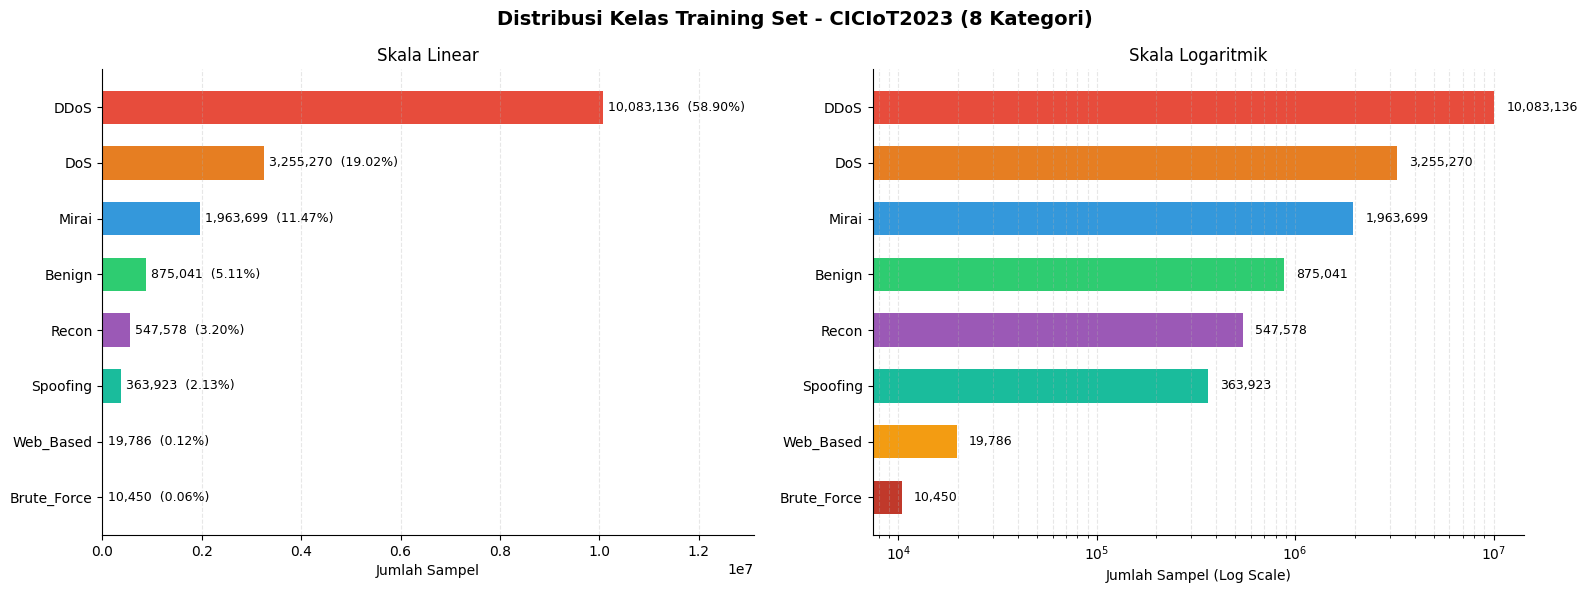

  Plot tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Results/Visualizations/langkah2_distribusi_kelas.png


In [ ]:
# Urutan plot: terkecil di atas, terbesar di bawah (barh)
plot_df     = dist_df.sort_values('Train_Count', ascending=True)
plot_labels = plot_df['Kategori'].tolist()
plot_values = plot_df['Train_Count'].tolist()
plot_pcts   = plot_df['Train_Pct'].tolist()
plot_colors = [CATEGORY_COLORS[c] for c in plot_labels]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribusi Kelas Training Set - CICIoT2023 (8 Kategori)',
             fontsize=14, fontweight='bold')

# Plot 1: Skala Linear
ax1   = axes[0]
bars1 = ax1.barh(plot_labels, plot_values, color=plot_colors, height=0.6)
ax1.set_xlabel('Jumlah Sampel')
ax1.set_title('Skala Linear')
ax1.set_xlim(0, max(plot_values) * 1.30)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

for bar, val, pct in zip(bars1, plot_values, plot_pcts):
    ax1.text(
        bar.get_width() + max(plot_values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}  ({pct:.2f}%)',
        va='center', ha='left', fontsize=9
    )

# Plot 2: Skala Log
ax2   = axes[1]
bars2 = ax2.barh(plot_labels, plot_values, color=plot_colors, height=0.6)
ax2.set_xlabel('Jumlah Sampel (Log Scale)')
ax2.set_title('Skala Logaritmik')
ax2.set_xscale('log')
ax2.grid(axis='x', alpha=0.3, linestyle='--', which='both')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for bar, val in zip(bars2, plot_values):
    ax2.text(
        bar.get_width() * 1.15,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}',
        va='center', ha='left', fontsize=9
    )

plt.tight_layout()
save_path = os.path.join(VISUALIZATION_DIR, 'langkah2_distribusi_kelas.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Plot tersimpan: {save_path}")

2.2.2 Visualisasi Pie Chart + Grouped Bar Train Vs Test

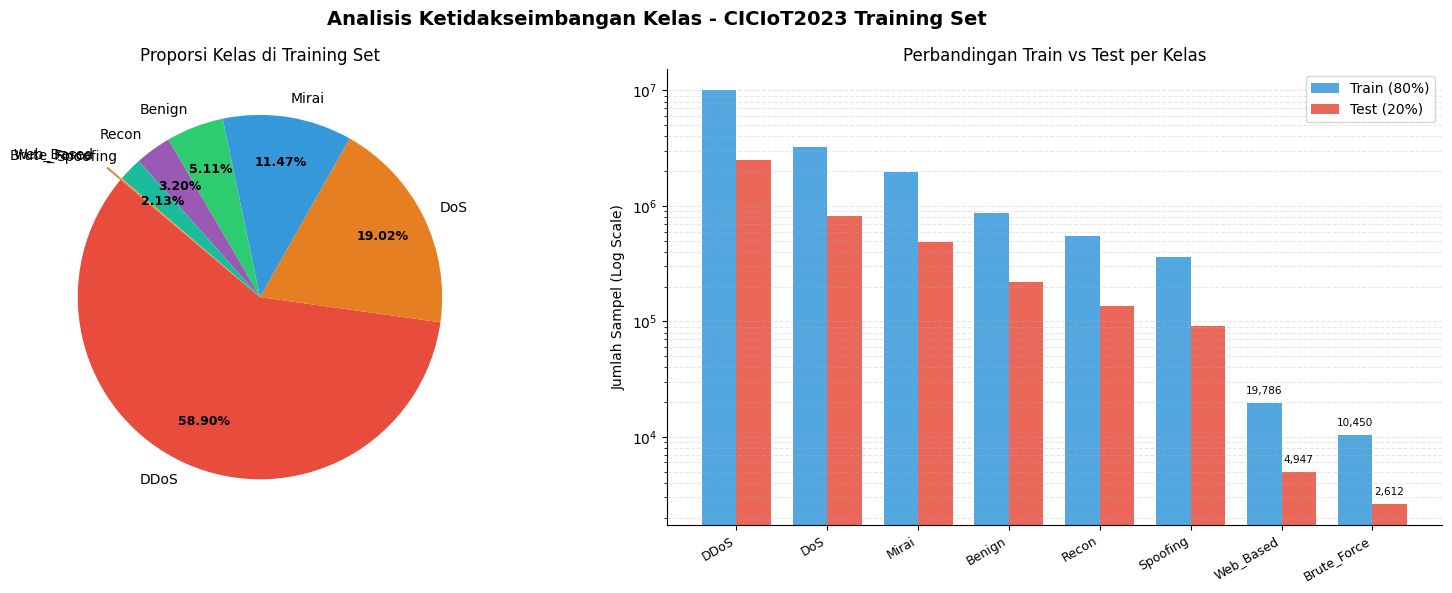

  Plot tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Results/Visualizations/langkah2_imbalance_analysis.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analisis Ketidakseimbangan Kelas - CICIoT2023 Training Set',
             fontsize=14, fontweight='bold')

# Pie chart
ax_pie = axes[0]
pie_df      = dist_df.sort_values('Train_Count', ascending=False)
pie_labels  = pie_df['Kategori'].tolist()
pie_values  = pie_df['Train_Count'].tolist()
pie_colors  = [CATEGORY_COLORS[c] for c in pie_labels]
explode     = [0.10 if c in ['Web_Based', 'Brute_Force'] else 0.0 for c in pie_labels]

wedges, texts, autotexts = ax_pie.pie(
    pie_values,
    labels=pie_labels,
    autopct=lambda p: f'{p:.2f}%' if p > 0.5 else '',
    colors=pie_colors,
    explode=explode,
    startangle=140,
    pctdistance=0.75,
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

ax_pie.set_title('Proporsi Kelas di Training Set')

# Grouped bar train vs test
ax_bar = axes[1]
sorted_df     = dist_df.sort_values('Train_Count', ascending=False)
sorted_cats   = sorted_df['Kategori'].tolist()
sorted_trains = sorted_df['Train_Count'].tolist()
sorted_tests  = sorted_df['Test_Count'].tolist()

x     = np.arange(len(sorted_cats))
width = 0.38

bars_tr = ax_bar.bar(x - width/2, sorted_trains, width,
                     label='Train (80%)', color='#3498DB', alpha=0.85)
bars_te = ax_bar.bar(x + width/2, sorted_tests,  width,
                     label='Test (20%)',  color='#E74C3C', alpha=0.85)

ax_bar.set_yscale('log')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(sorted_cats, rotation=30, ha='right', fontsize=9)
ax_bar.set_ylabel('Jumlah Sampel (Log Scale)')
ax_bar.set_title('Perbandingan Train vs Test per Kelas')
ax_bar.legend(fontsize=10)
ax_bar.grid(axis='y', alpha=0.3, linestyle='--', which='both')
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

# Anotasi angka hanya untuk kelas kecil
for bar, val in zip(bars_tr, sorted_trains):
    if val < 100_000:
        ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.15,
                    f'{val:,}', ha='center', va='bottom', fontsize=7.5)
for bar, val in zip(bars_te, sorted_tests):
    if val < 20_000:
        ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.15,
                    f'{val:,}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
save_path2 = os.path.join(VISUALIZATION_DIR, 'langkah2_imbalance_analysis.png')
plt.savefig(save_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Plot tersimpan: {save_path2}")

2.2.3 Summary Statistik Imbalance

In [ ]:
# Segmentasi awal berdasarkan GIR preview
dominant_cats = dist_df[dist_df['GIR'] < 5]['Kategori'].tolist()
moderate_cats = dist_df[(dist_df['GIR'] >= 5) & (dist_df['GIR'] < 50)]['Kategori'].tolist()
critical_cats = dist_df[dist_df['GIR'] >= 50]['Kategori'].tolist()

total_dominant = int(dist_df[dist_df['Kategori'].isin(dominant_cats)]['Train_Count'].sum())
total_moderate = int(dist_df[dist_df['Kategori'].isin(moderate_cats)]['Train_Count'].sum())
total_critical = int(dist_df[dist_df['Kategori'].isin(critical_cats)]['Train_Count'].sum())

# Shannon entropy
counts = dist_df['Train_Count'].values.astype(float)
probs  = counts / counts.sum()

from scipy.stats import entropy as scipy_entropy
shannon_entropy = float(scipy_entropy(probs, base=2))
max_entropy     = float(np.log2(len(counts)))
entropy_ratio   = shannon_entropy / max_entropy

print()
print("Kelompok DOMINANT (GIR < 5)  -> tidak perlu augmentasi")
for c in dominant_cats:
    row = dist_df[dist_df['Kategori'] == c].iloc[0]
    print(f"  {c:<14}  {row['Train_Count']:>10,}  ({row['Train_Pct']:.4f}%)")
print(f"  Subtotal: {total_dominant:,}  ({total_dominant / total_train * 100:.2f}%)")

print()
print("Kelompok MODERATE (5 <= GIR < 50)  -> augmentasi CVAE")
for c in moderate_cats:
    row = dist_df[dist_df['Kategori'] == c].iloc[0]
    print(f"  {c:<14}  {row['Train_Count']:>10,}  ({row['Train_Pct']:.4f}%)")
print(f"  Subtotal: {total_moderate:,}  ({total_moderate / total_train * 100:.2f}%)")

print()
print("Kelompok CRITICAL (GIR >= 50)  -> augmentasi Borderline-SMOTE")
for c in critical_cats:
    row = dist_df[dist_df['Kategori'] == c].iloc[0]
    print(f"  {c:<14}  {row['Train_Count']:>10,}  ({row['Train_Pct']:.4f}%)")
print(f"  Subtotal: {total_critical:,}  ({total_critical / total_train * 100:.2f}%)")

print()
print("Metrik Imbalance:")
print(f"  Imbalance Ratio (IR)           : 1:{ir_ratio:.0f}")
print(f"  Shannon Entropy                : {shannon_entropy:.4f} bit")
print(f"  Entropy Ratio (0=buruk,1=ideal): {entropy_ratio:.4f}")
print(f"  Jumlah kelas Critical          : {len(critical_cats)} ({', '.join(critical_cats)})")
print(f"  Jumlah kelas Moderate          : {len(moderate_cats)} ({', '.join(moderate_cats)})")
print(f"  Jumlah kelas Dominant          : {len(dominant_cats)} ({', '.join(dominant_cats)})")

print()
print("Estimasi kebutuhan augmentasi (target = level Moderate terendah):")
target_min_moderate = int(dist_df[dist_df['Kategori'].isin(moderate_cats)]['Train_Count'].min())
for c in critical_cats:
    row    = dist_df[dist_df['Kategori'] == c].iloc[0]
    needed = max(0, target_min_moderate - row['Train_Count'])
    print(f"  {c:<14}  perlu ~{needed:,} sampel  "
          f"(dari {row['Train_Count']:,} -> target >= {target_min_moderate:,})")

print()
print("Catatan: Target augmentasi final ditentukan secara dinamis oleh DT-GIR di Langkah 3.")


Kelompok DOMINANT (GIR < 5)  -> tidak perlu augmentasi
  DDoS            10,083,136  (58.9007%)
  DoS              3,255,270  (19.0157%)
  Mirai            1,963,699  (11.4710%)
  Subtotal: 15,302,105  (89.39%)

Kelompok MODERATE (5 <= GIR < 50)  -> augmentasi CVAE
  Benign             875,041  (5.1116%)
  Recon              547,578  (3.1987%)
  Spoofing           363,923  (2.1259%)
  Subtotal: 1,786,542  (10.44%)

Kelompok CRITICAL (GIR >= 50)  -> augmentasi Borderline-SMOTE
  Web_Based           19,786  (0.1156%)
  Brute_Force         10,450  (0.0610%)
  Subtotal: 30,236  (0.18%)

Metrik Imbalance:
  Imbalance Ratio (IR)           : 1:965
  Shannon Entropy                : 1.7776 bit
  Entropy Ratio (0=buruk,1=ideal): 0.5925
  Jumlah kelas Critical          : 2 (Web_Based, Brute_Force)
  Jumlah kelas Moderate          : 3 (Benign, Recon, Spoofing)
  Jumlah kelas Dominant          : 3 (DDoS, DoS, Mirai)

Estimasi kebutuhan augmentasi (target = level Moderate terendah):
  Web_Based   

####**2.3 Save Checkpoint Langkah 2**

In [ ]:
checkpoint_l2 = {
    'langkah'   : 2,
    'timestamp' : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'status'    : 'SELESAI',
    'data_info' : {
        'X_train_shape' : list(X_train.shape),
        'X_test_shape'  : list(X_test.shape),
        'y_train_shape' : list(y_train.shape),
        'y_test_shape'  : list(y_test.shape),
        'n_features'    : len(feature_names),
        'n_classes'     : len(LABEL_NAMES),
    },
    'distribusi_train' : {
        row['Kategori']: {
            'count'       : int(row['Train_Count']),
            'pct'         : float(row['Train_Pct']),
            'gir_preview' : float(row['GIR']),
        }
        for _, row in dist_df.iterrows()
    },
    'imbalance_metrics' : {
        'imbalance_ratio' : float(ir_ratio),
        'majority_class'  : majority_name,
        'minority_class'  : minority_name,
        'shannon_entropy' : shannon_entropy,
        'entropy_ratio'   : entropy_ratio,
    },
    'segmentasi_preview' : {
        'Dominant' : dominant_cats,
        'Moderate' : moderate_cats,
        'Critical' : critical_cats,
    },
    'validasi' : {
        'nan_train'  : nan_train,
        'inf_train'  : inf_train,
        'nan_test'   : nan_test,
        'inf_test'   : inf_test,
        'scaling_ok' : bool(mean_ok and std_ok),
    },
}

ckpt_path = os.path.join(GIR_DIR, 'langkah2_checkpoint.json')
with open(ckpt_path, 'w') as f:
    json.dump(checkpoint_l2, f, indent=4)

print(f"  Checkpoint tersimpan: {ckpt_path}")

  Checkpoint tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/01_GIR/langkah2_checkpoint.json


####**Ringkasan**

In [ ]:
print("LANGKAH 2 SELESAI")

print("\nData yang tersedia:")
print(f"  X_train        : {X_train.shape}   ({mem_X_train:.0f} MB)")
print(f"  X_test         : {X_test.shape}    ({mem_X_test:.0f} MB)")
print(f"  y_train        : {y_train.shape}")
print(f"  y_test         : {y_test.shape}")

print("\nObjek yang tersedia untuk langkah berikutnya:")
print("  scaler           -> StandardScaler (sudah difit di baseline)")
print("  label_encoder    -> LabelEncoder (8 kategori)")
print("  feature_names    -> list 39 nama fitur")
print("  LABEL_NAMES      -> dict {0..7 : nama kelas}")
print("  CATEGORY_COLORS  -> dict warna konsisten per kelas")
print("  dist_df          -> DataFrame distribusi + GIR preview")

print("\nLangkah berikutnya:")
print("  LANGKAH 3 -> Dynamic Threshold GIR Calculation")
print("               Menghitung GIR dan menentukan segmentasi")
print("               Dominant / Moderate / Critical secara adaptif")

LANGKAH 2 SELESAI

Data yang tersedia:
  X_train        : (17118883, 39)   (5094 MB)
  X_test         : (4279721, 39)    (1273 MB)
  y_train        : (17118883,)
  y_test         : (4279721,)

Objek yang tersedia untuk langkah berikutnya:
  scaler           -> StandardScaler (sudah difit di baseline)
  label_encoder    -> LabelEncoder (8 kategori)
  feature_names    -> list 39 nama fitur
  LABEL_NAMES      -> dict {0..7 : nama kelas}
  CATEGORY_COLORS  -> dict warna konsisten per kelas
  dist_df          -> DataFrame distribusi + GIR preview

Langkah berikutnya:
  LANGKAH 3 -> Dynamic Threshold GIR Calculation
               Menghitung GIR dan menentukan segmentasi
               Dominant / Moderate / Critical secara adaptif


## **Langkah 3: Dynamic Threshold GIR (DT-GIR) Calculation**

####**3.1 Perhitungan GIR Per Kategori**

In [ ]:
print("GIR Formula (dari FIGS, dimodifikasi untuk framework ini):")

print("Rumus: GIR_i = (w_maj * n_maj) / (w_min * n_i)")
print("Keterangan:")
print("w_maj = 1  -> tidak memberi bobot tambahan ke mayoritas")
print("w_min = 2  -> prioritas 2x ke kelas minoritas")
print("n_maj = jumlah sampel kelas terbesar di train set")
print("n_i   = jumlah sampel kelas ke-i di train set")

# Semakin besar GIR -> semakin imbalanced -> semakin perlu augmentasi

W_MAJ = 1.0
W_MIN = 2.0

# Ambil distribusi dari dist_df (sudah dihitung di Langkah 2)
n_maj = int(dist_df['Train_Count'].max())

print(f"\nParameter GIR:")
print(f"  w_maj      = {W_MAJ}")
print(f"  w_min      = {W_MIN}")
print(f"  n_majoritas = {n_maj:,}  ({dist_df.loc[dist_df['Train_Count'].idxmax(), 'Kategori']})")

# Hitung GIR untuk setiap kelas
gir_rows = []
for _, row in dist_df.iterrows():
    n_i = int(row['Train_Count'])
    gir = (W_MAJ * n_maj) / (W_MIN * n_i)
    gir_rows.append({
        'Kategori'    : row['Kategori'],
        'Train_Count' : n_i,
        'Train_Pct'   : row['Train_Pct'],
        'GIR'         : round(gir, 4),
        'Log_GIR'     : round(np.log10(gir), 4),   # log10 untuk scaling
    })

gir_df = pd.DataFrame(gir_rows).sort_values('GIR', ascending=True).reset_index(drop=True)

print(f"\nNilai GIR per Kategori (diurutkan dari kecil ke besar):")
print()
print(f"  {'No':<4} {'Kategori':<14}  {'Train Count':>12}  {'Train %':>9}  {'GIR':>10}  {'Log10(GIR)':>11}")
print(f"  {'-'*4} {'-'*14}  {'-'*12}  {'-'*9}  {'-'*10}  {'-'*11}")
for i, row in gir_df.iterrows():
    print(f"  {i:<4} {row['Kategori']:<14}  {row['Train_Count']:>12,}  "
          f"{row['Train_Pct']:>8.4f}%  {row['GIR']:>10.4f}  {row['Log_GIR']:>11.4f}")

print(f"\nRentang GIR:")
print(f"  GIR minimum : {gir_df['GIR'].min():.4f}  ({gir_df.iloc[0]['Kategori']})")
print(f"  GIR maksimum: {gir_df['GIR'].max():.4f}  ({gir_df.iloc[-1]['Kategori']})")
print(f"  Rasio max/min: {gir_df['GIR'].max() / gir_df['GIR'].min():.1f}x")

GIR Formula (dari FIGS, dimodifikasi untuk framework ini):
Rumus: GIR_i = (w_maj * n_maj) / (w_min * n_i)
Keterangan:
w_maj = 1  -> tidak memberi bobot tambahan ke mayoritas
w_min = 2  -> prioritas 2x ke kelas minoritas
n_maj = jumlah sampel kelas terbesar di train set
n_i   = jumlah sampel kelas ke-i di train set

Parameter GIR:
  w_maj      = 1.0
  w_min      = 2.0
  n_majoritas = 10,083,136  (DDoS)

Nilai GIR per Kategori (diurutkan dari kecil ke besar):

  No   Kategori         Train Count    Train %         GIR   Log10(GIR)
  ---- --------------  ------------  ---------  ----------  -----------
  0    DDoS              10,083,136   58.9007%      0.5000      -0.3010
  1    DoS                3,255,270   19.0157%      1.5487       0.1900
  2    Mirai              1,963,699   11.4710%      2.5674       0.4095
  3    Benign               875,041    5.1116%      5.7615       0.7605
  4    Recon                547,578    3.1987%      9.2070       0.9641
  5    Spoofing             363,9

####**3.2 Dynamic Threshold - Metode Elbow (Gap Analysis)**

Pendekatan:
Karena GIR mencakup beberapa order of magnitude, kita bekerja
di ruang log10 agar gap antar kelas proporsional.

Algoritma Elbow/Gap:
1. Ambil nilai Log10(GIR) yang sudah diurutkan
2. Hitung gap antara setiap pasangan GIR berurutan
3. Temukan 2 gap terbesar -> itulah posisi threshold alami
4. Threshold = geometric mean dari dua nilai di sisi gap tersebut

(dalam ruang log: midpoint, lalu konversi kembali ke GIR)

In [ ]:
log_gir_values  = gir_df['Log_GIR'].values
gir_values      = gir_df['GIR'].values
category_labels = gir_df['Kategori'].tolist()

# Hitung gap antara nilai log_GIR berurutan
gaps = []
for i in range(len(log_gir_values) - 1):
    gap = log_gir_values[i + 1] - log_gir_values[i]
    gaps.append({
        'index'       : i,
        'left_cat'    : category_labels[i],
        'right_cat'   : category_labels[i + 1],
        'left_log_gir': log_gir_values[i],
        'right_log_gir': log_gir_values[i + 1],
        'left_gir'    : gir_values[i],
        'right_gir'   : gir_values[i + 1],
        'gap_log'     : round(gap, 6),
    })

gaps_df = pd.DataFrame(gaps).sort_values('gap_log', ascending=False)

print("\nGap analysis di ruang Log10(GIR):")
print(f"\n  {'Rank':<5} {'Antara':<30}  {'Gap Log10':>10}  {'GIR Kiri':>10}  {'GIR Kanan':>10}")
print(f"  {'-'*5} {'-'*30}  {'-'*10}  {'-'*10}  {'-'*10}")
for rank, (_, row) in enumerate(gaps_df.iterrows(), 1):
    between = f"{row['left_cat']} | {row['right_cat']}"
    print(f"  {rank:<5} {between:<30}  {row['gap_log']:>10.6f}  "
          f"{row['left_gir']:>10.4f}  {row['right_gir']:>10.4f}")

# Ambil 2 gap terbesar sebagai posisi threshold
top2_gaps = gaps_df.head(2).sort_values('index')
gap_positions = top2_gaps['index'].tolist()

print(f"\n2 Gap terbesar ditemukan di posisi index: {gap_positions}")

# Hitung threshold = geometric mean di ruang log
thresholds_log = []
thresholds_gir = []
for _, gap_row in top2_gaps.iterrows():
    t_log = (gap_row['left_log_gir'] + gap_row['right_log_gir']) / 2
    t_gir = 10 ** t_log
    thresholds_log.append(round(t_log, 6))
    thresholds_gir.append(round(t_gir, 4))

thresholds_log.sort()
thresholds_gir.sort()

T1_ELBOW_LOG = thresholds_log[0]   # threshold Dominant vs Moderate
T2_ELBOW_LOG = thresholds_log[1]   # threshold Moderate vs Critical
T1_ELBOW_GIR = thresholds_gir[0]
T2_ELBOW_GIR = thresholds_gir[1]

print(f"\nThreshold hasil Elbow/Gap Method:")
print(f"  T1 (Dominant vs Moderate) : GIR = {T1_ELBOW_GIR:.4f}  (Log10 = {T1_ELBOW_LOG:.4f})")
print(f"  T2 (Moderate vs Critical) : GIR = {T2_ELBOW_GIR:.4f}  (Log10 = {T2_ELBOW_LOG:.4f})")

# Assign kategori sementara berdasarkan Elbow
def assign_segment_elbow(gir_val, t1, t2):
    if gir_val <= t1:
        return 'Dominant'
    elif gir_val <= t2:
        return 'Moderate'
    else:
        return 'Critical'

gir_df['Segment_Elbow'] = gir_df['GIR'].apply(
    lambda g: assign_segment_elbow(g, T1_ELBOW_GIR, T2_ELBOW_GIR)
)

print(f"\nHasil segmentasi Elbow:")
for _, row in gir_df.iterrows():
    print(f"  {row['Kategori']:<14}  GIR={row['GIR']:>8.4f}  -> {row['Segment_Elbow']}")


Gap analysis di ruang Log10(GIR):

  Rank  Antara                           Gap Log10    GIR Kiri   GIR Kanan
  ----- ------------------------------  ----------  ----------  ----------
  1     Spoofing | Web_Based              1.264600     13.8534    254.8048
  2     DDoS | DoS                        0.491000      0.5000      1.5487
  3     Mirai | Benign                    0.351000      2.5674      5.7615
  4     Web_Based | Brute_Force           0.277200    254.8048    482.4467
  5     DoS | Mirai                       0.219500      1.5487      2.5674
  6     Benign | Recon                    0.203600      5.7615      9.2070
  7     Recon | Spoofing                  0.177500      9.2070     13.8534

2 Gap terbesar ditemukan di posisi index: [0, 5]

Threshold hasil Elbow/Gap Method:
  T1 (Dominant vs Moderate) : GIR = 0.8800  (Log10 = -0.0555)
  T2 (Moderate vs Critical) : GIR = 59.4155  (Log10 = 1.7739)

Hasil segmentasi Elbow:
  DDoS            GIR=  0.5000  -> Dominant
  DoS      

####**3.3 Dynamic Threshold - Validasi Dengan Kmeans + Silhouette**

In [ ]:
from sklearn.cluster      import KMeans
from sklearn.metrics      import silhouette_score
from sklearn.preprocessing import StandardScaler as SKStandardScaler

# KMeans bekerja di ruang Log10(GIR) (1D)
X_gir = log_gir_values.reshape(-1, 1)

# Coba k = 2, 3, 4 dan pilih berdasarkan silhouette score
# (k=3 yang kita harapkan: Dominant, Moderate, Critical)

print("\nMencari k optimal dengan Silhouette Score:")
print(f"\n  {'k':<4}  {'Silhouette Score':>18}  {'Inertia':>12}  {'Keterangan'}")
print(f"  {'-'*4}  {'-'*18}  {'-'*12}  {'-'*20}")

kmeans_results = {}
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = km.fit_predict(X_gir)
    sil_score = silhouette_score(X_gir, labels_k) if k > 1 else 0.0
    inertia   = km.inertia_
    note = "(target framework)" if k == 3 else ""
    print(f"  {k:<4}  {sil_score:>18.6f}  {inertia:>12.6f}  {note}")
    kmeans_results[k] = {
        'model'    : km,
        'labels'   : labels_k,
        'silhouette': sil_score,
        'inertia'  : inertia,
    }

# Pilih k terbaik
best_k = max(kmeans_results, key=lambda k: kmeans_results[k]['silhouette'])
print(f"\nk terbaik berdasarkan Silhouette Score: k = {best_k}")

# Gunakan k=3 sesuai framework (Dominant/Moderate/Critical)
# Jika best_k != 3, tetap gunakan k=3 dengan catatan silhouette-nya
km3      = kmeans_results[3]['model']
labels3  = kmeans_results[3]['labels']
sil3     = kmeans_results[3]['silhouette']

# Map cluster id ke nama segmen berdasarkan urutan centroid
centroids     = km3.cluster_centers_.flatten()
cluster_order = np.argsort(centroids)          # indeks cluster dari kecil ke besar
cluster_to_segment = {
    cluster_order[0]: 'Dominant',
    cluster_order[1]: 'Moderate',
    cluster_order[2]: 'Critical',
}

gir_df['Segment_KMeans'] = [cluster_to_segment[lbl] for lbl in labels3]

print(f"\nHasil segmentasi KMeans (k=3, silhouette={sil3:.4f}):")
for _, row in gir_df.iterrows():
    print(f"  {row['Kategori']:<14}  Log_GIR={row['Log_GIR']:>7.4f}  -> {row['Segment_KMeans']}")

# Hitung threshold KMeans = midpoint centroid di ruang log
sorted_centroids  = np.sort(centroids)
T1_KMEANS_LOG     = (sorted_centroids[0] + sorted_centroids[1]) / 2
T2_KMEANS_LOG     = (sorted_centroids[1] + sorted_centroids[2]) / 2
T1_KMEANS_GIR     = round(10 ** T1_KMEANS_LOG, 4)
T2_KMEANS_GIR     = round(10 ** T2_KMEANS_LOG, 4)

print(f"\nCentroid KMeans (Log10 space): {sorted_centroids.round(4).tolist()}")
print(f"Threshold hasil KMeans:")
print(f"  T1 (Dominant vs Moderate) : GIR = {T1_KMEANS_GIR:.4f}  (Log10 = {T1_KMEANS_LOG:.4f})")
print(f"  T2 (Moderate vs Critical) : GIR = {T2_KMEANS_GIR:.4f}  (Log10 = {T2_KMEANS_LOG:.4f})")


Mencari k optimal dengan Silhouette Score:

  k       Silhouette Score       Inertia  Keterangan
  ----  ------------------  ------------  --------------------
  2               0.711156      1.474690  
  3               0.615466      0.375843  (target framework)
  4               0.568285      0.135242  

k terbaik berdasarkan Silhouette Score: k = 2

Hasil segmentasi KMeans (k=3, silhouette=0.6155):
  DDoS            Log_GIR=-0.3010  -> Dominant
  DoS             Log_GIR= 0.1900  -> Dominant
  Mirai           Log_GIR= 0.4095  -> Dominant
  Benign          Log_GIR= 0.7605  -> Moderate
  Recon           Log_GIR= 0.9641  -> Moderate
  Spoofing        Log_GIR= 1.1416  -> Moderate
  Web_Based       Log_GIR= 2.4062  -> Critical
  Brute_Force     Log_GIR= 2.6834  -> Critical

Centroid KMeans (Log10 space): [0.0995, 0.9554, 2.5448]
Threshold hasil KMeans:
  T1 (Dominant vs Moderate) : GIR = 3.3686  (Log10 = 0.5274)
  T2 (Moderate vs Critical) : GIR = 56.2471  (Log10 = 1.7501)


####**3.4 Komparasi dan Pemilihan Threshold Final**

In [ ]:
# Bandingkan hasil kedua metode
print("\nPerbandingan threshold dua metode:")
print(f"\n  {'Metode':<20}  {'T1 (Dom/Mod)':>14}  {'T2 (Mod/Crit)':>14}  {'Sil Score':>10}")
print(f"  {'-'*20}  {'-'*14}  {'-'*14}  {'-'*10}")
print(f"  {'Elbow/Gap':<20}  {T1_ELBOW_GIR:>14.4f}  {T2_ELBOW_GIR:>14.4f}  {'N/A':>10}")
print(f"  {'KMeans (k=3)':<20}  {T1_KMEANS_GIR:>14.4f}  {T2_KMEANS_GIR:>14.4f}  {sil3:>10.4f}")

# Cek apakah kedua metode menghasilkan segmentasi yang sama
agree_all = all(
    gir_df['Segment_Elbow'].iloc[i] == gir_df['Segment_KMeans'].iloc[i]
    for i in range(len(gir_df))
)
print(f"\nKonsistensi hasil kedua metode: {'YA (semua kelas sama)' if agree_all else 'TIDAK (ada perbedaan)'}")

if not agree_all:
    print("\nPerbedaan segmentasi:")
    for _, row in gir_df.iterrows():
        if row['Segment_Elbow'] != row['Segment_KMeans']:
            print(f"  {row['Kategori']:<14}  Elbow={row['Segment_Elbow']}  KMeans={row['Segment_KMeans']}")

# Strategi pemilihan threshold final:
# - Jika kedua metode sepakat -> rata-rata geometrik threshold sebagai final
# - Jika berbeda -> gunakan KMeans (lebih robust, didukung silhouette score)
# - Dalam semua kasus, validasi manual bahwa segmentasi logis

if agree_all:
    # Geometric mean dari kedua threshold (di ruang log)
    T1_FINAL_LOG = (T1_ELBOW_LOG + T1_KMEANS_LOG) / 2
    T2_FINAL_LOG = (T2_ELBOW_LOG + T2_KMEANS_LOG) / 2
    method_used  = "Rata-rata Elbow + KMeans (kedua metode konsisten)"
else:
    T1_FINAL_LOG = T1_KMEANS_LOG
    T2_FINAL_LOG = T2_KMEANS_LOG
    method_used  = "KMeans (dipilih karena ada perbedaan, silhouette lebih valid)"

T1_FINAL_GIR = round(10 ** T1_FINAL_LOG, 4)
T2_FINAL_GIR = round(10 ** T2_FINAL_LOG, 4)

print(f"\nThreshold FINAL yang digunakan:")
print(f"  Metode      : {method_used}")
print(f"  T1 (Dominant vs Moderate) : GIR = {T1_FINAL_GIR:.4f}  (Log10 = {T1_FINAL_LOG:.6f})")
print(f"  T2 (Moderate vs Critical) : GIR = {T2_FINAL_GIR:.4f}  (Log10 = {T2_FINAL_LOG:.6f})")

# Assign segmentasi final
def assign_segment_final(gir_val, t1, t2):
    if gir_val <= t1:
        return 'Dominant'
    elif gir_val <= t2:
        return 'Moderate'
    else:
        return 'Critical'

gir_df['Segment_Final'] = gir_df['GIR'].apply(
    lambda g: assign_segment_final(g, T1_FINAL_GIR, T2_FINAL_GIR)
)


Perbandingan threshold dua metode:

  Metode                  T1 (Dom/Mod)   T2 (Mod/Crit)   Sil Score
  --------------------  --------------  --------------  ----------
  Elbow/Gap                     0.8800         59.4155         N/A
  KMeans (k=3)                  3.3686         56.2471      0.6155

Konsistensi hasil kedua metode: TIDAK (ada perbedaan)

Perbedaan segmentasi:
  DoS             Elbow=Moderate  KMeans=Dominant
  Mirai           Elbow=Moderate  KMeans=Dominant

Threshold FINAL yang digunakan:
  Metode      : KMeans (dipilih karena ada perbedaan, silhouette lebih valid)
  T1 (Dominant vs Moderate) : GIR = 3.3686  (Log10 = 0.527450)
  T2 (Moderate vs Critical) : GIR = 56.2471  (Log10 = 1.750100)


####**3.5 Hasil Kategorisasi Final**

In [ ]:
dominant_cats = gir_df[gir_df['Segment_Final'] == 'Dominant']['Kategori'].tolist()
moderate_cats = gir_df[gir_df['Segment_Final'] == 'Moderate']['Kategori'].tolist()
critical_cats = gir_df[gir_df['Segment_Final'] == 'Critical']['Kategori'].tolist()

total_dominant = int(gir_df[gir_df['Segment_Final'] == 'Dominant']['Train_Count'].sum())
total_moderate = int(gir_df[gir_df['Segment_Final'] == 'Moderate']['Train_Count'].sum())
total_critical = int(gir_df[gir_df['Segment_Final'] == 'Critical']['Train_Count'].sum())
total_all_     = total_dominant + total_moderate + total_critical

print(f"\nKelompok DOMINANT (GIR <= {T1_FINAL_GIR:.4f})  ->  tidak perlu augmentasi")
print(f"  {'Kategori':<14}  {'Train Count':>12}  {'Train %':>9}  {'GIR':>10}")
print(f"  {'-'*14}  {'-'*12}  {'-'*9}  {'-'*10}")
for _, row in gir_df[gir_df['Segment_Final'] == 'Dominant'].iterrows():
    print(f"  {row['Kategori']:<14}  {row['Train_Count']:>12,}  {row['Train_Pct']:>8.4f}%  {row['GIR']:>10.4f}")
print(f"  Subtotal: {total_dominant:,}  ({total_dominant / total_all_ * 100:.2f}%)")

print(f"\nKelompok MODERATE ({T1_FINAL_GIR:.4f} < GIR <= {T2_FINAL_GIR:.4f})  ->  augmentasi CVAE")
print(f"  {'Kategori':<14}  {'Train Count':>12}  {'Train %':>9}  {'GIR':>10}")
print(f"  {'-'*14}  {'-'*12}  {'-'*9}  {'-'*10}")
for _, row in gir_df[gir_df['Segment_Final'] == 'Moderate'].iterrows():
    print(f"  {row['Kategori']:<14}  {row['Train_Count']:>12,}  {row['Train_Pct']:>8.4f}%  {row['GIR']:>10.4f}")
print(f"  Subtotal: {total_moderate:,}  ({total_moderate / total_all_ * 100:.2f}%)")

print(f"\nKelompok CRITICAL (GIR > {T2_FINAL_GIR:.4f})  ->  augmentasi Borderline-SMOTE")
print(f"  {'Kategori':<14}  {'Train Count':>12}  {'Train %':>9}  {'GIR':>10}")
print(f"  {'-'*14}  {'-'*12}  {'-'*9}  {'-'*10}")
for _, row in gir_df[gir_df['Segment_Final'] == 'Critical'].iterrows():
    print(f"  {row['Kategori']:<14}  {row['Train_Count']:>12,}  {row['Train_Pct']:>8.4f}%  {row['GIR']:>10.4f}")
print(f"  Subtotal: {total_critical:,}  ({total_critical / total_all_ * 100:.2f}%)")

# Ringkasan
print(f"\nRingkasan segmentasi:")
print(f"  Dominant : {len(dominant_cats)} kelas -> {dominant_cats}")
print(f"  Moderate : {len(moderate_cats)} kelas -> {moderate_cats}")
print(f"  Critical : {len(critical_cats)} kelas -> {critical_cats}")


Kelompok DOMINANT (GIR <= 3.3686)  ->  tidak perlu augmentasi
  Kategori         Train Count    Train %         GIR
  --------------  ------------  ---------  ----------
  DDoS              10,083,136   58.9007%      0.5000
  DoS                3,255,270   19.0157%      1.5487
  Mirai              1,963,699   11.4710%      2.5674
  Subtotal: 15,302,105  (89.39%)

Kelompok MODERATE (3.3686 < GIR <= 56.2471)  ->  augmentasi CVAE
  Kategori         Train Count    Train %         GIR
  --------------  ------------  ---------  ----------
  Benign               875,041    5.1116%      5.7615
  Recon                547,578    3.1987%      9.2070
  Spoofing             363,923    2.1259%     13.8534
  Subtotal: 1,786,542  (10.44%)

Kelompok CRITICAL (GIR > 56.2471)  ->  augmentasi Borderline-SMOTE
  Kategori         Train Count    Train %         GIR
  --------------  ------------  ---------  ----------
  Web_Based             19,786    0.1156%    254.8048
  Brute_Force           10,450    0.

####**3.6 Visualisasi GIR dan Threshold**

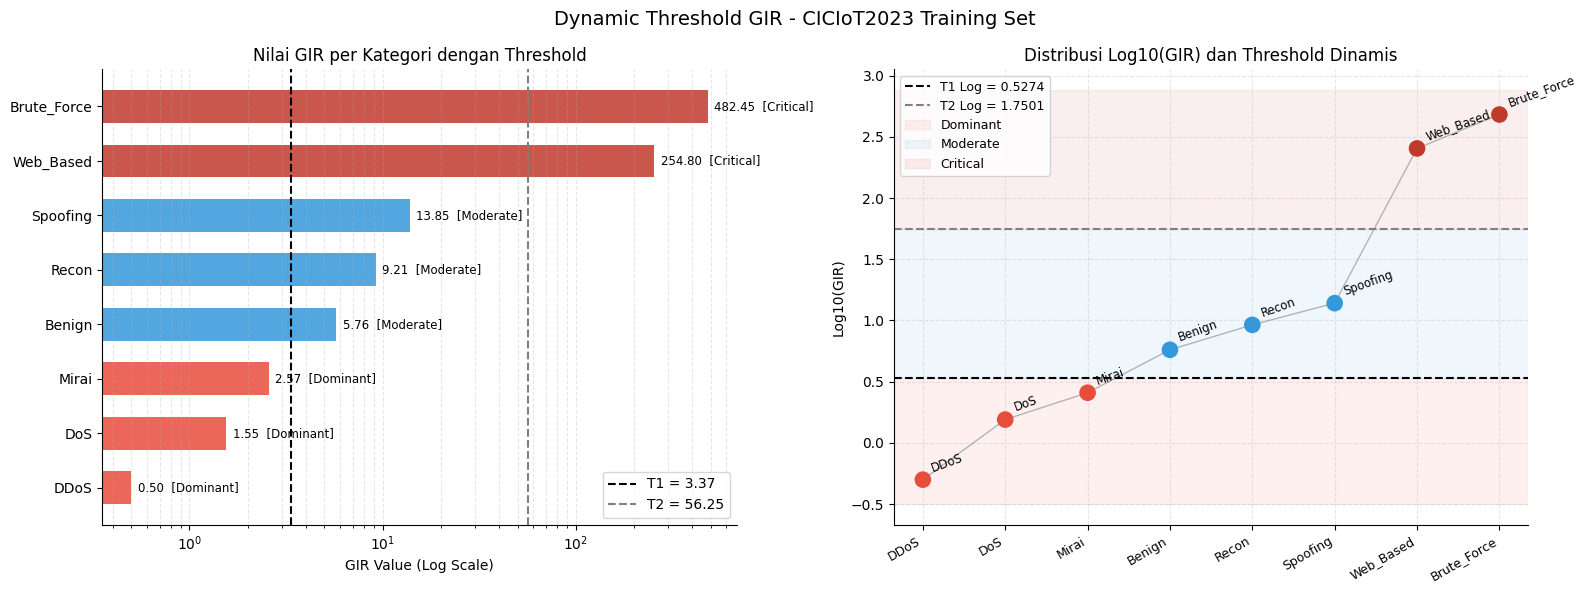

  Plot tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Results/Visualizations/langkah3_gir_threshold.png


In [ ]:
SEGMENT_COLORS = {
    'Dominant' : '#E74C3C',
    'Moderate' : '#3498DB',
    'Critical' : '#C0392B',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Dynamic Threshold GIR - CICIoT2023 Training Set',
             fontsize=14)

# Plot 1: GIR Bar + Threshold Lines (skala log)
ax1 = axes[0]

plot_cats   = gir_df['Kategori'].tolist()
plot_girs   = gir_df['GIR'].tolist()
plot_segs   = gir_df['Segment_Final'].tolist()
bar_colors  = [SEGMENT_COLORS[s] for s in plot_segs]

bars = ax1.barh(plot_cats, plot_girs, color=bar_colors, height=0.6, alpha=0.85)

# Threshold lines
ax1.axvline(x=T1_FINAL_GIR, color='black', linestyle='--', linewidth=1.5,
            label=f'T1 = {T1_FINAL_GIR:.2f}')
ax1.axvline(x=T2_FINAL_GIR, color='gray', linestyle='--', linewidth=1.5,
            label=f'T2 = {T2_FINAL_GIR:.2f}')

ax1.set_xscale('log')
ax1.set_xlabel('GIR Value (Log Scale)')
ax1.set_title('Nilai GIR per Kategori dengan Threshold')
ax1.grid(axis='x', alpha=0.3, linestyle='--', which='both')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(fontsize=10)

for bar, val, seg in zip(bars, plot_girs, plot_segs):
    ax1.text(
        bar.get_width() * 1.08,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}  [{seg}]',
        va='center', ha='left', fontsize=8.5
    )

# Plot 2: Gap Analysis (Log Space)
ax2 = axes[1]

x_pos  = np.arange(len(log_gir_values))
colors_scatter = [SEGMENT_COLORS[s] for s in gir_df['Segment_Final'].tolist()]

ax2.scatter(x_pos, log_gir_values, c=colors_scatter, s=120, zorder=5)
ax2.plot(x_pos, log_gir_values, color='#7F8C8D', linewidth=1.0,
         linestyle='-', alpha=0.6)

# Anotasi nama kelas
for i, (cat, log_g) in enumerate(zip(plot_cats, log_gir_values)):
    ax2.annotate(
        cat,
        xy=(i, log_g),
        xytext=(5, 6),
        textcoords='offset points',
        fontsize=8.5,
        rotation=20
    )

# Threshold lines di log space
ax2.axhline(y=T1_FINAL_LOG, color='black', linestyle='--', linewidth=1.5,
            label=f'T1 Log = {T1_FINAL_LOG:.4f}')
ax2.axhline(y=T2_FINAL_LOG, color='gray', linestyle='--', linewidth=1.5,
            label=f'T2 Log = {T2_FINAL_LOG:.4f}')

# Shaded regions
ax2.axhspan(log_gir_values[0] - 0.2, T1_FINAL_LOG,
            alpha=0.08, color='#E74C3C', label='Dominant')
ax2.axhspan(T1_FINAL_LOG, T2_FINAL_LOG,
            alpha=0.08, color='#3498DB', label='Moderate')
ax2.axhspan(T2_FINAL_LOG, log_gir_values[-1] + 0.2,
            alpha=0.08, color='#C0392B', label='Critical')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(plot_cats, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Log10(GIR)')
ax2.set_title('Distribusi Log10(GIR) dan Threshold Dinamis')
ax2.grid(alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(fontsize=9, loc='upper left')

plt.tight_layout()
save_path = os.path.join(VISUALIZATION_DIR, 'langkah3_gir_threshold.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Plot tersimpan: {save_path}")

####**3.7 Visualisasi Silhouette dan Gap Analysis**

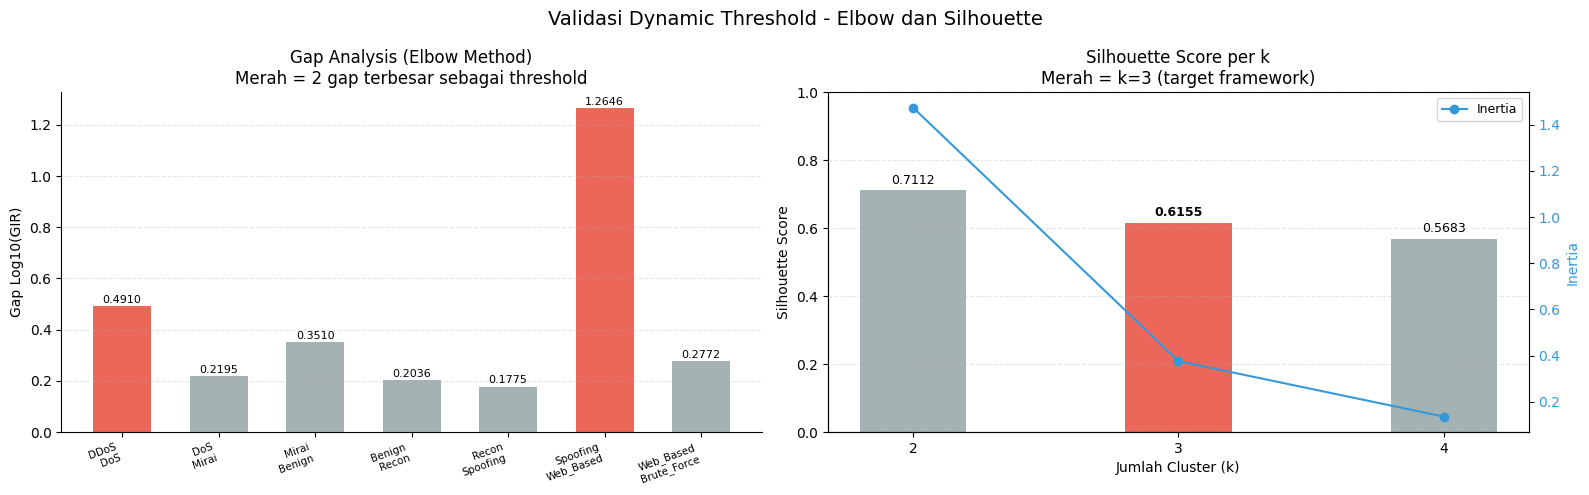

  Plot tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Results/Visualizations/langkah3_silhouette_gap.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Validasi Dynamic Threshold - Elbow dan Silhouette',
             fontsize=14)

# Plot 1: Gap (Elbow) di log space
ax1 = axes[0]

gap_indices = list(range(len(gaps)))
gap_values  = [g['gap_log'] for g in gaps]
gap_labels  = [f"{g['left_cat']}\n{g['right_cat']}" for g in gaps]

# Warnai dua gap terbesar
gap_bar_colors = []
sorted_gap_vals = sorted(gap_values, reverse=True)
top2_threshold  = sorted_gap_vals[1]
for gv in gap_values:
    if gv >= top2_threshold:
        gap_bar_colors.append('#E74C3C')
    else:
        gap_bar_colors.append('#95A5A6')

bars_gap = ax1.bar(gap_indices, gap_values, color=gap_bar_colors, alpha=0.85, width=0.6)

ax1.set_xticks(gap_indices)
ax1.set_xticklabels(gap_labels, fontsize=7.5, rotation=20, ha='right')
ax1.set_ylabel('Gap Log10(GIR)')
ax1.set_title('Gap Analysis (Elbow Method)\nMerah = 2 gap terbesar sebagai threshold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

for bar, val in zip(bars_gap, gap_values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.4f}',
        ha='center', va='bottom', fontsize=8
    )

# Plot 2: Silhouette Score vs k
ax2 = axes[1]

k_values   = sorted(kmeans_results.keys())
sil_scores = [kmeans_results[k]['silhouette'] for k in k_values]
inertias   = [kmeans_results[k]['inertia']    for k in k_values]

color_bars = ['#E74C3C' if k == 3 else '#95A5A6' for k in k_values]
bars_sil   = ax2.bar(k_values, sil_scores, color=color_bars, alpha=0.85, width=0.4)

ax2.set_xlabel('Jumlah Cluster (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score per k\nMerah = k=3 (target framework)')
ax2.set_xticks(k_values)
ax2.set_ylim(0, 1.0)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for bar, k, sil in zip(bars_sil, k_values, sil_scores):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{sil:.4f}',
        ha='center', va='bottom', fontsize=9,
        fontweight='bold' if k == 3 else 'normal'
    )

# Tambahkan inertia sebagai line chart pada sumbu kedua
ax2b = ax2.twinx()
ax2b.plot(k_values, inertias, color='#3498DB', marker='o',
          linewidth=1.5, markersize=6, label='Inertia')
ax2b.set_ylabel('Inertia', color='#3498DB')
ax2b.tick_params(axis='y', labelcolor='#3498DB')
ax2b.legend(fontsize=9, loc='upper right')

plt.tight_layout()
save_path2 = os.path.join(VISUALIZATION_DIR, 'langkah3_silhouette_gap.png')
plt.savefig(save_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Plot tersimpan: {save_path2}")

####**3.8 Save Checkpoint Langkah 3**

In [ ]:
# Susun hasil GIR ke format yang bersih untuk checkpoint
gir_results = {}
for _, row in gir_df.iterrows():
    gir_results[row['Kategori']] = {
        'train_count'   : int(row['Train_Count']),
        'train_pct'     : float(row['Train_Pct']),
        'gir'           : float(row['GIR']),
        'log_gir'       : float(row['Log_GIR']),
        'segment_elbow' : row['Segment_Elbow'],
        'segment_kmeans': row['Segment_KMeans'],
        'segment_final' : row['Segment_Final'],
    }

checkpoint_l3 = {
    'langkah'   : 3,
    'timestamp' : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'status'    : 'SELESAI',
    'gir_params': {
        'w_maj'        : W_MAJ,
        'w_min'        : W_MIN,
        'n_majoritass' : n_maj,
    },
    'gir_results': gir_results,
    'threshold_elbow': {
        'T1_GIR' : T1_ELBOW_GIR,
        'T2_GIR' : T2_ELBOW_GIR,
        'T1_LOG' : T1_ELBOW_LOG,
        'T2_LOG' : T2_ELBOW_LOG,
    },
    'threshold_kmeans': {
        'T1_GIR'         : T1_KMEANS_GIR,
        'T2_GIR'         : T2_KMEANS_GIR,
        'T1_LOG'         : T1_KMEANS_LOG,
        'T2_LOG'         : T2_KMEANS_LOG,
        'silhouette_k3'  : float(sil3),
        'best_k'         : int(best_k),
        'centroids_log'  : sorted_centroids.tolist(),
    },
    'threshold_final': {
        'T1_GIR'         : T1_FINAL_GIR,
        'T2_GIR'         : T2_FINAL_GIR,
        'T1_LOG'         : T1_FINAL_LOG,
        'T2_LOG'         : T2_FINAL_LOG,
        'method_used'    : method_used,
        'both_agree'     : bool(agree_all),
    },
    'segmentasi_final': {
        'Dominant' : {
            'kategori'     : dominant_cats,
            'total_samples': total_dominant,
            'pct'          : round(total_dominant / total_all_ * 100, 4),
            'aksi'         : 'Tidak perlu augmentasi',
        },
        'Moderate' : {
            'kategori'     : moderate_cats,
            'total_samples': total_moderate,
            'pct'          : round(total_moderate / total_all_ * 100, 4),
            'aksi'         : 'Augmentasi CVAE (Langkah 6)',
        },
        'Critical' : {
            'kategori'     : critical_cats,
            'total_samples': total_critical,
            'pct'          : round(total_critical / total_all_ * 100, 4),
            'aksi'         : 'Augmentasi Borderline-SMOTE (Langkah 7)',
        },
    },
}

ckpt_path = os.path.join(GIR_DIR, 'langkah3_checkpoint.json')
with open(ckpt_path, 'w') as f:
    json.dump(checkpoint_l3, f, indent=4)

print(f"\n  Checkpoint tersimpan: {ckpt_path}")

# Simpan juga gir_df sebagai CSV untuk referensi
csv_path = os.path.join(GIR_DIR, 'langkah3_gir_values.csv')
gir_df.to_csv(csv_path, index=False)
print(f"  GIR table tersimpan : {csv_path}")


  Checkpoint tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/01_GIR/langkah3_checkpoint.json
  GIR table tersimpan : /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/01_GIR/langkah3_gir_values.csv


####**3.9 Ringkasan**

In [ ]:
print("LANGKAH 3 SELESAI")

print("\nHasil Dynamic Threshold GIR:")
print(f"  Metode    : Elbow/Gap + KMeans (k=3) + Silhouette validation")
print(f"  T1 final  : {T1_FINAL_GIR:.4f}  (Dominant vs Moderate)")
print(f"  T2 final  : {T2_FINAL_GIR:.4f}  (Moderate vs Critical)")
print(f"  Sil Score : {sil3:.4f}  (k=3)")

print("\nSegmentasi final:")
print(f"  Dominant  : {dominant_cats}  ({len(dominant_cats)} kelas)")
print(f"  Moderate  : {moderate_cats}  ({len(moderate_cats)} kelas)")
print(f"  Critical  : {critical_cats}  ({len(critical_cats)} kelas)")

print("\nVariabel penting untuk langkah berikutnya:")
print("  gir_df           -> DataFrame GIR + segmentasi per kelas")
print("  dominant_cats    -> list kelas Dominant")
print("  moderate_cats    -> list kelas Moderate")
print("  critical_cats    -> list kelas Critical")
print("  T1_FINAL_GIR     -> threshold Dominant vs Moderate")
print("  T2_FINAL_GIR     -> threshold Moderate vs Critical")

print("\nLangkah berikutnya:")
print("  LANGKAH 4 -> Category Segmentation")
print("               Split X_train per segmen dan simpan ke disk")

LANGKAH 3 SELESAI

Hasil Dynamic Threshold GIR:
  Metode    : Elbow/Gap + KMeans (k=3) + Silhouette validation
  T1 final  : 3.3686  (Dominant vs Moderate)
  T2 final  : 56.2471  (Moderate vs Critical)
  Sil Score : 0.6155  (k=3)

Segmentasi final:
  Dominant  : ['DDoS', 'DoS', 'Mirai']  (3 kelas)
  Moderate  : ['Benign', 'Recon', 'Spoofing']  (3 kelas)
  Critical  : ['Web_Based', 'Brute_Force']  (2 kelas)

Variabel penting untuk langkah berikutnya:
  gir_df           -> DataFrame GIR + segmentasi per kelas
  dominant_cats    -> list kelas Dominant
  moderate_cats    -> list kelas Moderate
  critical_cats    -> list kelas Critical
  T1_FINAL_GIR     -> threshold Dominant vs Moderate
  T2_FINAL_GIR     -> threshold Moderate vs Critical

Langkah berikutnya:
  LANGKAH 4 -> Category Segmentation
               Split X_train per segmen dan simpan ke disk


## **Langkah 4: Category Segmentation**

####**4.1 Verifikasi Variabel dari Langkah 3**

In [ ]:
print("Verifikasi variabel dari Langkah 3")

# Verifikasi segmentasi
print("Segmentasi kategori:")
print(f"  Dominant : {dominant_cats}")
print(f"  Moderate : {moderate_cats}")
print(f"  Critical : {critical_cats}")

# Verifikasi threshold
print(f"\nThreshold GIR Final:")
print(f"  T1 (Dominant/Moderate) : {T1_FINAL_GIR:.4f}")
print(f"  T2 (Moderate/Critical) : {T2_FINAL_GIR:.4f}")

# Verifikasi data utama
print(f"\nUkuran data utama:")
print(f"  X_train shape : {X_train.shape}")
print(f"  y_train shape : {y_train.shape}")
print(f"  X_test shape  : {X_test.shape}")
print(f"  y_test shape  : {y_test.shape}")

# Verifikasi label mapping
print(f"\nLabel mapping:")
for enc, name in LABEL_NAMES.items():
    count = np.sum(y_train == enc)
    print(f"  {enc}: {name} -> {count:,} samples")

# Verifikasi path
print(f"\nPath segmentasi: {SEGMENTATION_DIR}")
os.makedirs(SEGMENTATION_DIR, exist_ok=True)
print("  Folder siap.")

mem = psutil.virtual_memory()
print(f"\nRAM tersisa sebelum segmentasi: {mem.available / 1024**3:.2f} GB")

Verifikasi variabel dari Langkah 3
Segmentasi kategori:
  Dominant : ['DDoS', 'DoS', 'Mirai']
  Moderate : ['Benign', 'Recon', 'Spoofing']
  Critical : ['Web_Based', 'Brute_Force']

Threshold GIR Final:
  T1 (Dominant/Moderate) : 3.3686
  T2 (Moderate/Critical) : 56.2471

Ukuran data utama:
  X_train shape : (17118883, 39)
  y_train shape : (17118883,)
  X_test shape  : (4279721, 39)
  y_test shape  : (4279721,)

Label mapping:
  0: Benign -> 875,041 samples
  1: Brute_Force -> 10,450 samples
  2: DDoS -> 10,083,136 samples
  3: DoS -> 3,255,270 samples
  4: Mirai -> 1,963,699 samples
  5: Recon -> 547,578 samples
  6: Spoofing -> 363,923 samples
  7: Web_Based -> 19,786 samples

Path segmentasi: /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/02_Segmentation/
  Folder siap.

RAM tersisa sebelum segmentasi: 40.75 GB


####**4.2 Membuat Mapping Label ke Segmen**

In [ ]:
print("Membuat mapping label ke segmen")

# Buat reverse mapping: nama kategori -> encoded label
NAME_TO_ENC = {v: k for k, v in LABEL_NAMES.items()}
print("Reverse mapping (nama -> encoded):")
for name, enc in NAME_TO_ENC.items():
    print(f"  {name} -> {enc}")

# Buat mapping encoded label -> segmen
LABEL_TO_SEGMENT = {}

for enc, name in LABEL_NAMES.items():
    if name in dominant_cats:
        LABEL_TO_SEGMENT[enc] = 'dominant'
    elif name in moderate_cats:
        LABEL_TO_SEGMENT[enc] = 'moderate'
    elif name in critical_cats:
        LABEL_TO_SEGMENT[enc] = 'critical'
    else:
        LABEL_TO_SEGMENT[enc] = 'unknown'

print("\nMapping encoded label -> segmen:")
for enc, seg in LABEL_TO_SEGMENT.items():
    name = LABEL_NAMES[enc]
    print(f"  {enc} ({name}) -> {seg.upper()}")

# Encoded labels per segmen
dominant_labels  = [k for k, v in LABEL_TO_SEGMENT.items() if v == 'dominant']
moderate_labels  = [k for k, v in LABEL_TO_SEGMENT.items() if v == 'moderate']
critical_labels  = [k for k, v in LABEL_TO_SEGMENT.items() if v == 'critical']

print(f"\nEncoded labels per segmen:")
print(f"  Dominant  : {dominant_labels} -> {[LABEL_NAMES[l] for l in dominant_labels]}")
print(f"  Moderate  : {moderate_labels} -> {[LABEL_NAMES[l] for l in moderate_labels]}")
print(f"  Critical  : {critical_labels} -> {[LABEL_NAMES[l] for l in critical_labels]}")

Membuat mapping label ke segmen
Reverse mapping (nama -> encoded):
  Benign -> 0
  Brute_Force -> 1
  DDoS -> 2
  DoS -> 3
  Mirai -> 4
  Recon -> 5
  Spoofing -> 6
  Web_Based -> 7

Mapping encoded label -> segmen:
  0 (Benign) -> MODERATE
  1 (Brute_Force) -> CRITICAL
  2 (DDoS) -> DOMINANT
  3 (DoS) -> DOMINANT
  4 (Mirai) -> DOMINANT
  5 (Recon) -> MODERATE
  6 (Spoofing) -> MODERATE
  7 (Web_Based) -> CRITICAL

Encoded labels per segmen:
  Dominant  : [2, 3, 4] -> ['DDoS', 'DoS', 'Mirai']
  Moderate  : [0, 5, 6] -> ['Benign', 'Recon', 'Spoofing']
  Critical  : [1, 7] -> ['Brute_Force', 'Web_Based']


####**4.3 Membuat Boolean Mask per Segmen**

In [ ]:
print("Membuat boolean mask per segmen")

start_time = time.time()

mask_dominant = np.isin(y_train, dominant_labels)
mask_moderate = np.isin(y_train, moderate_labels)
mask_critical = np.isin(y_train, critical_labels)

elapsed = time.time() - start_time
print(f"Mask berhasil dibuat dalam {elapsed:.2f} detik")

# Verifikasi mask
n_dominant = mask_dominant.sum()
n_moderate = mask_moderate.sum()
n_critical = mask_critical.sum()
n_total    = len(y_train)

print(f"\nJumlah samples per segmen:")
print(f"  Dominant  : {n_dominant:,} ({n_dominant/n_total*100:.2f}%)")
print(f"  Moderate  : {n_moderate:,} ({n_moderate/n_total*100:.2f}%)")
print(f"  Critical  : {n_critical:,} ({n_critical/n_total*100:.2f}%)")
print(f"  Total     : {n_dominant + n_moderate + n_critical:,}")
print(f"  Expected  : {n_total:,}")

# Pastikan tidak ada overlap atau missing
assert (n_dominant + n_moderate + n_critical) == n_total, \
    "ERROR: Total segmen tidak sama dengan total data!"
print("\nValidasi: Total segmen = Total data [OK]")

Membuat boolean mask per segmen
Mask berhasil dibuat dalam 0.63 detik

Jumlah samples per segmen:
  Dominant  : 15,302,105 (89.39%)
  Moderate  : 1,786,542 (10.44%)
  Critical  : 30,236 (0.18%)
  Total     : 17,118,883
  Expected  : 17,118,883

Validasi: Total segmen = Total data [OK]


####**4.4 Split Data per Segmen**

In [ ]:
print("Split X_train dan y_train per segmen")

# --- DOMINANT ---
print("Memproses segmen DOMINANT...")
start = time.time()
X_dominant = X_train[mask_dominant]
y_dominant = y_train[mask_dominant]
elapsed = time.time() - start
print(f"  X_dominant shape : {X_dominant.shape}")
print(f"  y_dominant shape : {y_dominant.shape}")
print(f"  Selesai dalam    : {elapsed:.2f} detik")

# Validasi distribusi dominant
print("  Distribusi kelas di DOMINANT:")
for lbl in dominant_labels:
    cnt = np.sum(y_dominant == lbl)
    print(f"    {LABEL_NAMES[lbl]}: {cnt:,}")

# --- MODERATE ---
print("\nMemproses segmen MODERATE...")
start = time.time()
X_moderate = X_train[mask_moderate]
y_moderate = y_train[mask_moderate]
elapsed = time.time() - start
print(f"  X_moderate shape : {X_moderate.shape}")
print(f"  y_moderate shape : {y_moderate.shape}")
print(f"  Selesai dalam    : {elapsed:.2f} detik")

print("  Distribusi kelas di MODERATE:")
for lbl in moderate_labels:
    cnt = np.sum(y_moderate == lbl)
    print(f"    {LABEL_NAMES[lbl]}: {cnt:,}")

# --- CRITICAL ---
print("\nMemproses segmen CRITICAL...")
start = time.time()
X_critical = X_train[mask_critical]
y_critical = y_train[mask_critical]
elapsed = time.time() - start
print(f"  X_critical shape : {X_critical.shape}")
print(f"  y_critical shape : {y_critical.shape}")
print(f"  Selesai dalam    : {elapsed:.2f} detik")

print("  Distribusi kelas di CRITICAL:")
for lbl in critical_labels:
    cnt = np.sum(y_critical == lbl)
    print(f"    {LABEL_NAMES[lbl]}: {cnt:,}")

Split X_train dan y_train per segmen
Memproses segmen DOMINANT...
  X_dominant shape : (15302105, 39)
  y_dominant shape : (15302105,)
  Selesai dalam    : 3.70 detik
  Distribusi kelas di DOMINANT:
    DDoS: 10,083,136
    DoS: 3,255,270
    Mirai: 1,963,699

Memproses segmen MODERATE...
  X_moderate shape : (1786542, 39)
  y_moderate shape : (1786542,)
  Selesai dalam    : 0.88 detik
  Distribusi kelas di MODERATE:
    Benign: 875,041
    Recon: 547,578
    Spoofing: 363,923

Memproses segmen CRITICAL...
  X_critical shape : (30236, 39)
  y_critical shape : (30236,)
  Selesai dalam    : 0.06 detik
  Distribusi kelas di CRITICAL:
    Brute_Force: 10,450
    Web_Based: 19,786


####**4.5 Menyimpan Segmen ke Disk**

In [ ]:
print("Menyimpan segmen ke disk")

def save_segment(X, y, segment_name, save_dir):
    """Simpan X dan y segmen ke file .npy"""
    path_X = os.path.join(save_dir, f'X_{segment_name}.npy')
    path_y = os.path.join(save_dir, f'y_{segment_name}.npy')

    start = time.time()
    np.save(path_X, X)
    np.save(path_y, y)
    elapsed = time.time() - start

    size_X_mb = os.path.getsize(path_X) / 1024**2
    size_y_mb = os.path.getsize(path_y) / 1024**2

    print(f"  [{segment_name.upper()}] Tersimpan dalam {elapsed:.2f} detik")
    print(f"    X -> {path_X} ({size_X_mb:.2f} MB)")
    print(f"    y -> {path_y} ({size_y_mb:.2f} MB)")
    return path_X, path_y

# Simpan setiap segmen
save_segment(X_dominant, y_dominant, 'dominant', SEGMENTATION_DIR)
save_segment(X_moderate, y_moderate, 'moderate', SEGMENTATION_DIR)
save_segment(X_critical, y_critical, 'critical', SEGMENTATION_DIR)

# Simpan juga mask (untuk referensi)
np.save(os.path.join(SEGMENTATION_DIR, 'mask_dominant.npy'), mask_dominant)
np.save(os.path.join(SEGMENTATION_DIR, 'mask_moderate.npy'), mask_moderate)
np.save(os.path.join(SEGMENTATION_DIR, 'mask_critical.npy'), mask_critical)
print("\n  Mask juga tersimpan.")

Menyimpan segmen ke disk
  [DOMINANT] Tersimpan dalam 120.45 detik
    X -> /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/02_Segmentation/X_dominant.npy (4553.09 MB)
    y -> /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/02_Segmentation/y_dominant.npy (116.75 MB)
  [MODERATE] Tersimpan dalam 51.42 detik
    X -> /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/02_Segmentation/X_moderate.npy (531.58 MB)
    y -> /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/02_Segmentation/y_moderate.npy (13.63 MB)
  [CRITICAL] Tersimpan dalam 3.90 detik
    X -> /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/02_Segmentation/X_critical.npy (9.00 MB)
    y -> /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/02_Segmentation/y_critical.npy (0.23 MB)

  Mask juga tersimpan.


####**4.6 Menyimpan Metadata Segmentasi**

In [ ]:
print("Menyimpan metadata segmentasi")

segmentation_metadata = {
    'threshold': {
        'T1_GIR': float(T1_FINAL_GIR),
        'T2_GIR': float(T2_FINAL_GIR),
    },
    'segments': {
        'dominant': {
            'categories': dominant_cats,
            'encoded_labels': dominant_labels,
            'n_samples': int(n_dominant),
            'pct_of_train': float(round(n_dominant / n_total * 100, 4)),
            'class_counts': {
                LABEL_NAMES[lbl]: int(np.sum(y_dominant == lbl))
                for lbl in dominant_labels
            }
        },
        'moderate': {
            'categories': moderate_cats,
            'encoded_labels': moderate_labels,
            'n_samples': int(n_moderate),
            'pct_of_train': float(round(n_moderate / n_total * 100, 4)),
            'class_counts': {
                LABEL_NAMES[lbl]: int(np.sum(y_moderate == lbl))
                for lbl in moderate_labels
            }
        },
        'critical': {
            'categories': critical_cats,
            'encoded_labels': critical_labels,
            'n_samples': int(n_critical),
            'pct_of_train': float(round(n_critical / n_total * 100, 4)),
            'class_counts': {
                LABEL_NAMES[lbl]: int(np.sum(y_critical == lbl))
                for lbl in critical_labels
            }
        }
    },
    'total_train_samples': int(n_total),
    'n_features': int(X_train.shape[1]),
    'label_to_segment': {str(k): v for k, v in LABEL_TO_SEGMENT.items()},
}

meta_path = os.path.join(SEGMENTATION_DIR, 'segmentation_metadata.json')
with open(meta_path, 'w') as f:
    json.dump(segmentation_metadata, f, indent=4)
print(f"  Metadata tersimpan: {meta_path}")

Menyimpan metadata segmentasi
  Metadata tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/02_Segmentation/segmentation_metadata.json


####**4.7 Validasi Setelah Simpan (Load Ulang Dan Cek)**

In [ ]:
for seg in ['dominant', 'moderate', 'critical']:
    X_check = np.load(os.path.join(SEGMENTATION_DIR, f'X_{seg}.npy'))
    y_check = np.load(os.path.join(SEGMENTATION_DIR, f'y_{seg}.npy'))

    # Tentukan referensi
    if seg == 'dominant':
        X_ref, y_ref = X_dominant, y_dominant
    elif seg == 'moderate':
        X_ref, y_ref = X_moderate, y_moderate
    else:
        X_ref, y_ref = X_critical, y_critical

    shape_ok  = (X_check.shape == X_ref.shape) and (y_check.shape == y_ref.shape)
    values_ok = np.allclose(X_check[:100], X_ref[:100])  # cek 100 baris pertama
    labels_ok = np.array_equal(y_check[:100], y_ref[:100])

    status = "OK" if (shape_ok and values_ok and labels_ok) else "FAIL"
    print(f"  [{seg.upper()}] Shape {X_check.shape} | Nilai [OK={values_ok}] | Label [OK={labels_ok}] -> {status}")
    del X_check, y_check

print("\nValidasi selesai.")

  [DOMINANT] Shape (15302105, 39) | Nilai [OK=True] | Label [OK=True] -> OK
  [MODERATE] Shape (1786542, 39) | Nilai [OK=True] | Label [OK=True] -> OK
  [CRITICAL] Shape (30236, 39) | Nilai [OK=True] | Label [OK=True] -> OK

Validasi selesai.


####**4.8 Visualisasi Segmentasi**

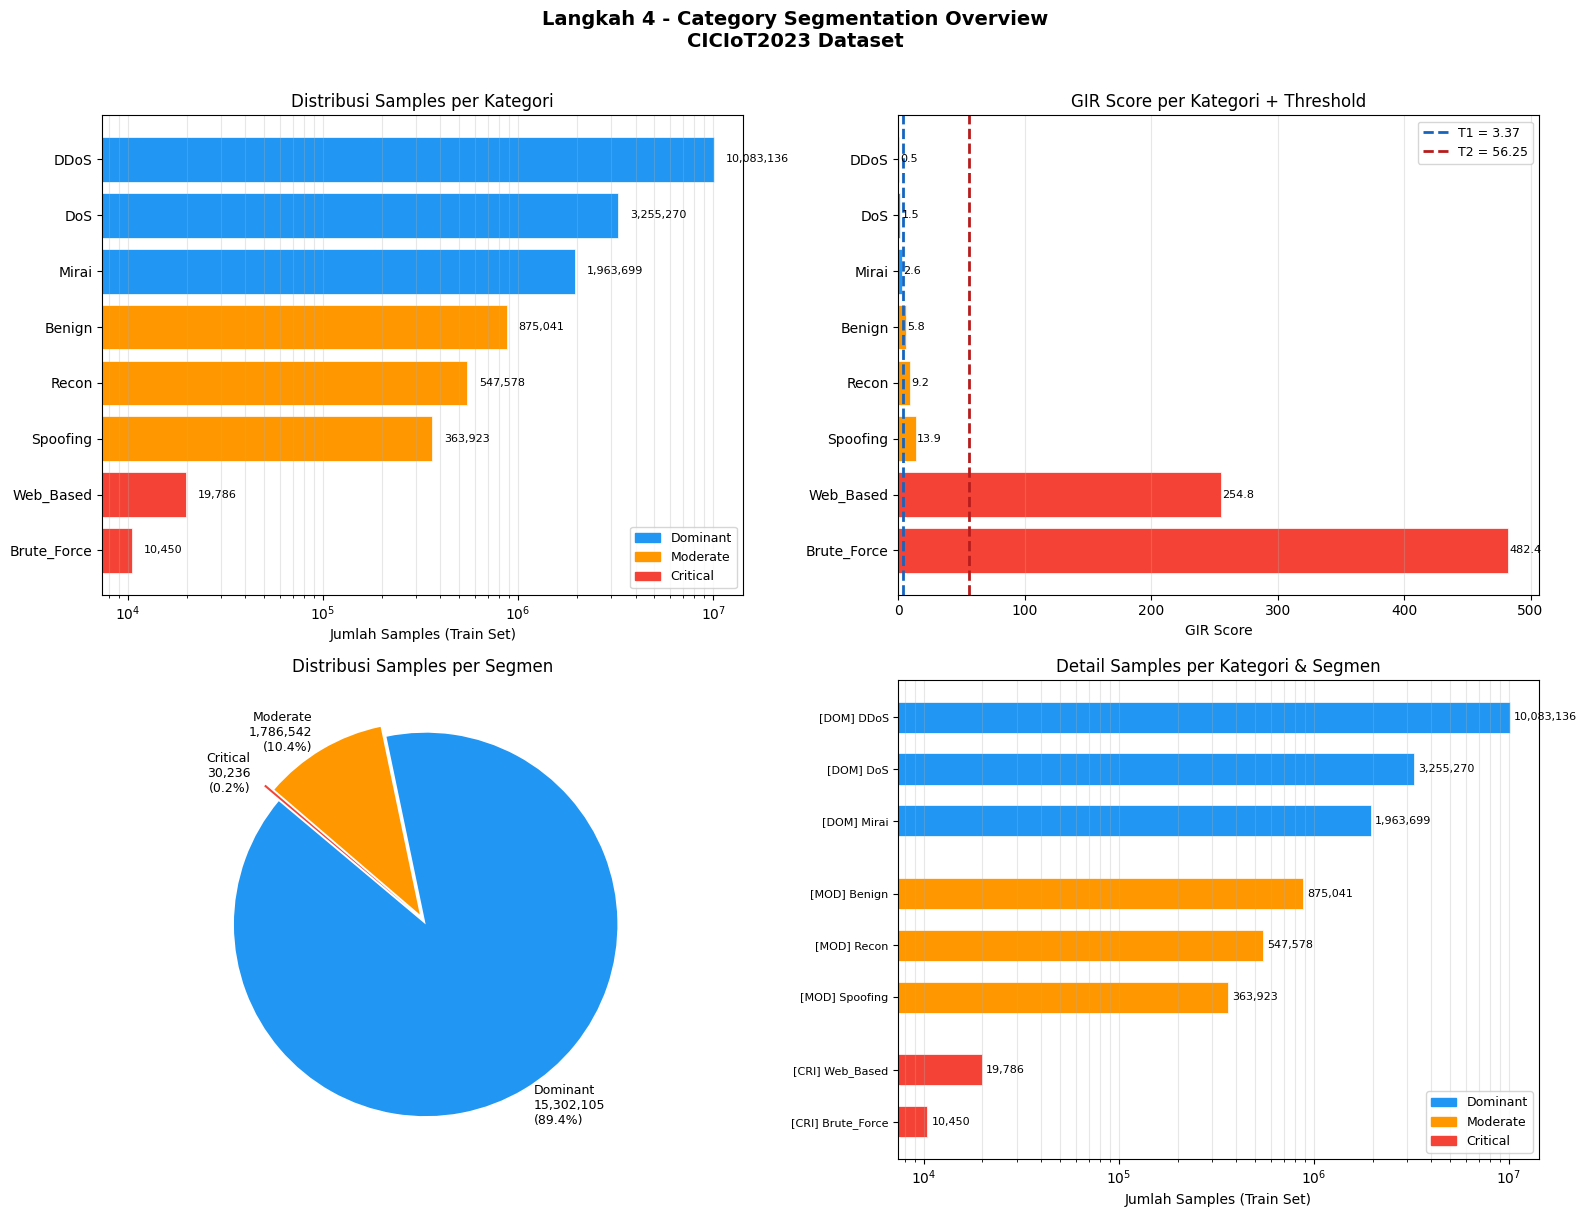

  Gambar 1 tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Results/Visualizations/Langkah4_Segmentation_Overview.png


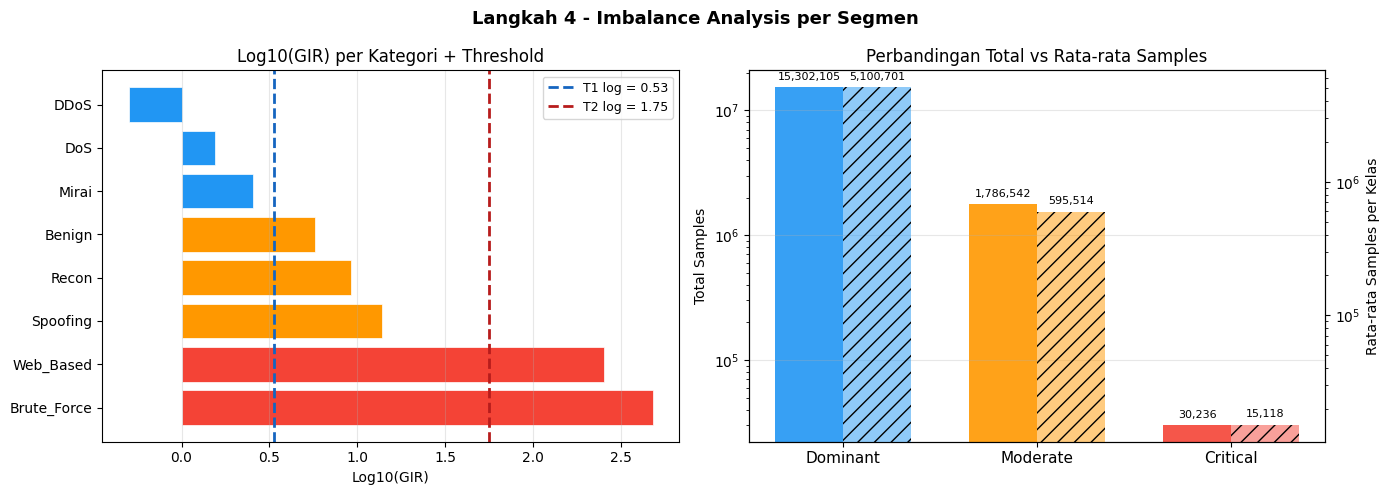

  Gambar 2 tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Results/Visualizations/Langkah4_Segmentation_Imbalance.png


In [ ]:
import matplotlib.patches as mpatches

# --- Data untuk visualisasi ---
seg_colors = {
    'dominant': '#2196F3',
    'moderate': '#FF9800',
    'critical': '#F44336',
}

# Kumpulkan data per kelas dengan segmennya
all_class_data = []
for enc, name in LABEL_NAMES.items():
    seg = LABEL_TO_SEGMENT[enc]
    count = int(np.sum(y_train == enc))
    gir = float(gir_df[gir_df['Kategori'] == name]['GIR'].values[0]) \
          if name in gir_df['Kategori'].values else 0.0
    log_gir = float(gir_df[gir_df['Kategori'] == name]['Log_GIR'].values[0]) \
              if name in gir_df['Kategori'].values else 0.0
    all_class_data.append({
        'name': name, 'enc': enc, 'segment': seg,
        'count': count, 'gir': gir, 'log_gir': log_gir
    })

all_class_df = pd.DataFrame(all_class_data).sort_values('count', ascending=False)

# ===== FIGURE 1: Overview 4-panel =====
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Langkah 4 - Category Segmentation Overview\nCICIoT2023 Dataset',
             fontsize=14, fontweight='bold', y=1.01)

# --- Panel 1: Distribusi samples per kelas (bar) ---
ax1 = axes[0, 0]
bar_colors = [seg_colors[row['segment']] for _, row in all_class_df.iterrows()]
bars = ax1.barh(all_class_df['name'], all_class_df['count'],
                color=bar_colors, edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Jumlah Samples (Train Set)')
ax1.set_title('Distribusi Samples per Kategori')
ax1.set_xscale('log')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3, which='both')

for bar, cnt in zip(bars, all_class_df['count']):
    ax1.text(bar.get_width() * 1.15, bar.get_y() + bar.get_height() / 2,
             f'{cnt:,}', va='center', fontsize=8)

legend_patches = [
    mpatches.Patch(color=seg_colors['dominant'], label='Dominant'),
    mpatches.Patch(color=seg_colors['moderate'], label='Moderate'),
    mpatches.Patch(color=seg_colors['critical'], label='Critical'),
]
ax1.legend(handles=legend_patches, loc='lower right', fontsize=9)

# --- Panel 2: GIR per kelas dengan threshold lines ---
ax2 = axes[0, 1]
gir_df_sorted = all_class_df.sort_values('gir', ascending=True)
bar_colors_gir = [seg_colors[row['segment']] for _, row in gir_df_sorted.iterrows()]
ax2.barh(gir_df_sorted['name'], gir_df_sorted['gir'],
         color=bar_colors_gir, edgecolor='white', linewidth=0.5)
ax2.axvline(x=T1_FINAL_GIR, color='#1565C0', linestyle='--', linewidth=2,
            label=f'T1 = {T1_FINAL_GIR:.2f}')
ax2.axvline(x=T2_FINAL_GIR, color='#B71C1C', linestyle='--', linewidth=2,
            label=f'T2 = {T2_FINAL_GIR:.2f}')
ax2.set_xlabel('GIR Score')
ax2.set_title('GIR Score per Kategori + Threshold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
ax2.legend(fontsize=9)

for i, (_, row) in enumerate(gir_df_sorted.iterrows()):
    ax2.text(row['gir'] + T2_FINAL_GIR * 0.02, i,
             f'{row["gir"]:.1f}', va='center', fontsize=8)

# --- Panel 3: Pie chart distribusi samples per segmen ---
ax3 = axes[1, 0]
seg_totals = {'Dominant': n_dominant, 'Moderate': n_moderate, 'Critical': n_critical}
seg_labels_pie = [f"{k}\n{v:,}\n({v/n_total*100:.1f}%)" for k, v in seg_totals.items()]
seg_sizes = list(seg_totals.values())
seg_pie_colors = [seg_colors['dominant'], seg_colors['moderate'], seg_colors['critical']]
explode = (0.03, 0.03, 0.08)

wedges, texts = ax3.pie(seg_sizes, labels=seg_labels_pie, colors=seg_pie_colors,
                         explode=explode, autopct=None,
                         textprops={'fontsize': 9}, startangle=140)
ax3.set_title('Distribusi Samples per Segmen')

# --- Panel 4: Jumlah kelas per segmen + samples per kelas ---
ax4 = axes[1, 1]
seg_order = ['Dominant', 'Moderate', 'Critical']
seg_cat_names = {
    'Dominant': dominant_cats,
    'Moderate': moderate_cats,
    'Critical': critical_cats,
}

y_pos = 0
yticks_pos = []
yticks_lab = []
bar_height = 0.6

for seg_name in seg_order:
    cats = seg_cat_names[seg_name]
    color = seg_colors[seg_name.lower()]
    for cat in cats:
        enc = NAME_TO_ENC[cat]
        cnt = int(np.sum(y_train == enc))
        ax4.barh(y_pos, cnt, height=bar_height, color=color,
                 edgecolor='white', linewidth=0.5)
        ax4.text(cnt * 1.05, y_pos, f'{cnt:,}', va='center', fontsize=8)
        yticks_pos.append(y_pos)
        yticks_lab.append(f'[{seg_name[:3].upper()}] {cat}')
        y_pos += 1
    y_pos += 0.4  # spasi antar segmen

ax4.set_yticks(yticks_pos)
ax4.set_yticklabels(yticks_lab, fontsize=8)
ax4.set_xlabel('Jumlah Samples (Train Set)')
ax4.set_title('Detail Samples per Kategori & Segmen')
ax4.set_xscale('log')
ax4.invert_yaxis()
ax4.grid(axis='x', alpha=0.3, which='both')
ax4.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
fig_path1 = os.path.join(VISUALIZATION_DIR, 'Langkah4_Segmentation_Overview.png')
plt.savefig(fig_path1, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Gambar 1 tersimpan: {fig_path1}")

# ===== FIGURE 2: Imbalance ratio summary =====
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Langkah 4 - Imbalance Analysis per Segmen', fontsize=13, fontweight='bold')

# --- Panel kiri: Log_GIR per kelas ---
ax_l = axes2[0]
gir_sorted2 = all_class_df.sort_values('log_gir', ascending=True)
bc2 = [seg_colors[row['segment']] for _, row in gir_sorted2.iterrows()]
ax_l.barh(gir_sorted2['name'], gir_sorted2['log_gir'],
          color=bc2, edgecolor='white', linewidth=0.5)
log_T1 = np.log10(T1_FINAL_GIR) if T1_FINAL_GIR > 0 else 0
log_T2 = np.log10(T2_FINAL_GIR) if T2_FINAL_GIR > 0 else 0
ax_l.axvline(x=log_T1, color='#1565C0', linestyle='--', linewidth=2,
             label=f'T1 log = {log_T1:.2f}')
ax_l.axvline(x=log_T2, color='#B71C1C', linestyle='--', linewidth=2,
             label=f'T2 log = {log_T2:.2f}')
ax_l.set_xlabel('Log10(GIR)')
ax_l.set_title('Log10(GIR) per Kategori + Threshold')
ax_l.invert_yaxis()
ax_l.grid(axis='x', alpha=0.3)
ax_l.legend(fontsize=9)
for _, row in gir_sorted2.iterrows():
    pass  # label sudah dari bar

# --- Panel kanan: Samples ratio vs threshold ---
ax_r = axes2[1]
seg_summary = pd.DataFrame([
    {'Segmen': 'Dominant', 'Jumlah Kelas': len(dominant_cats),
     'Total Samples': n_dominant, 'Rata2 per Kelas': n_dominant // len(dominant_cats)},
    {'Segmen': 'Moderate', 'Jumlah Kelas': len(moderate_cats),
     'Total Samples': n_moderate, 'Rata2 per Kelas': n_moderate // len(moderate_cats)},
    {'Segmen': 'Critical', 'Jumlah Kelas': len(critical_cats),
     'Total Samples': n_critical, 'Rata2 per Kelas': n_critical // len(critical_cats)},
])

x = np.arange(len(seg_summary))
w = 0.35
bars_total = ax_r.bar(x - w/2, seg_summary['Total Samples'],
                      width=w, color=[seg_colors['dominant'],
                                       seg_colors['moderate'],
                                       seg_colors['critical']],
                      label='Total Samples', alpha=0.9)
ax_r2 = ax_r.twinx()
bars_avg = ax_r2.bar(x + w/2, seg_summary['Rata2 per Kelas'],
                     width=w, color=[seg_colors['dominant'],
                                      seg_colors['moderate'],
                                      seg_colors['critical']],
                     label='Rata-rata per Kelas', alpha=0.5, hatch='//')

ax_r.set_xticks(x)
ax_r.set_xticklabels(seg_summary['Segmen'], fontsize=11)
ax_r.set_ylabel('Total Samples', fontsize=10)
ax_r2.set_ylabel('Rata-rata Samples per Kelas', fontsize=10)
ax_r.set_title('Perbandingan Total vs Rata-rata Samples')
ax_r.set_yscale('log')
ax_r2.set_yscale('log')
ax_r.grid(axis='y', alpha=0.3)

# Anotasi di atas bar
for bar in bars_total:
    ax_r.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
              f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
for bar in bars_avg:
    ax_r2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
               f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
fig_path2 = os.path.join(VISUALIZATION_DIR, 'Langkah4_Segmentation_Imbalance.png')
plt.savefig(fig_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Gambar 2 tersimpan: {fig_path2}")

####**4.9 Ringkasan**

In [ ]:
print(f"Hasil segmentasi X_train ({n_total:,} samples):")
print(f"  {'Segmen':<12} {'Kelas':<30} {'Samples':>12} {'Persen':>8}")
print(f"  {'-'*65}")

for seg_name, labels, n_seg in [
    ('DOMINANT', dominant_labels, n_dominant),
    ('MODERATE', moderate_labels, n_moderate),
    ('CRITICAL', critical_labels, n_critical),
]:
    for i, lbl in enumerate(labels):
        cnt = int(np.sum(y_train == lbl))
        cat_name = LABEL_NAMES[lbl]
        prefix = seg_name if i == 0 else ''
        print(f"  {prefix:<12} {cat_name:<30} {cnt:>12,} {cnt/n_total*100:>7.2f}%")
    if seg_name != 'CRITICAL':
        print(f"  {'':<12} {'Subtotal':.<30} {n_seg:>12,} {n_seg/n_total*100:>7.2f}%")
        print(f"  {'-'*65}")

print(f"\n  {'':12} {'TOTAL':.<30} {n_total:>12,} {'100.00%':>8}")

print(f"\nFile tersimpan di: {SEGMENTATION_DIR}")
print(f"  X_dominant.npy, y_dominant.npy")
print(f"  X_moderate.npy, y_moderate.npy")
print(f"  X_critical.npy, y_critical.npy")
print(f"  mask_dominant.npy, mask_moderate.npy, mask_critical.npy")
print(f"  segmentation_metadata.json")

print(f"\nVisualisasi tersimpan di: {VISUALIZATION_DIR}")
print(f"  Langkah4_Segmentation_Overview.png")
print(f"  Langkah4_Segmentation_Imbalance.png")

# Cek RAM setelah selesai
mem = psutil.virtual_memory()
print(f"\nRAM tersisa setelah Langkah 4: {mem.available / 1024**3:.2f} GB")

# Hapus mask sementara untuk hemat RAM (data segmen tetap disimpan)
del mask_dominant, mask_moderate, mask_critical
gc.collect()
print("Mask sementara dihapus dari RAM. gc.collect() selesai.")

print("\nLangkah 4 selesai. Siap lanjut ke Langkah 5 (CAFW).")
print("=" * 60)

Hasil segmentasi X_train (17,118,883 samples):
  Segmen       Kelas                               Samples   Persen
  -----------------------------------------------------------------
  DOMINANT     DDoS                             10,083,136   58.90%
               DoS                               3,255,270   19.02%
               Mirai                             1,963,699   11.47%
               Subtotal......................   15,302,105   89.39%
  -----------------------------------------------------------------
  MODERATE     Benign                              875,041    5.11%
               Recon                               547,578    3.20%
               Spoofing                            363,923    2.13%
               Subtotal......................    1,786,542   10.44%
  -----------------------------------------------------------------
  CRITICAL     Brute_Force                          10,450    0.06%
               Web_Based                            19,786    0.12%



## **Langkah 5: Category-Aware Feature Weighting (CAFW)**

####**5.1 Setup dan Verifikasi**

In [ ]:
# Load feature names
with open(os.path.join(BASELINE_PROCESSED_DIR, 'feature_names.json'), 'r') as f:
    feature_names = json.load(f)

n_features = len(feature_names)
print(f"Jumlah features : {n_features}")
print(f"Contoh features : {feature_names[:5]}")

# Konfigurasi CAFW
EPSILON          = 1e-5    # Optimal epsilon dari FIGS paper (Sec 6.4)
TOP_K            = 30      # Top-K features per kategori
N_DISC_TRAIN     = 40000   # Max samples per kelas untuk discriminator training
N_SENSITIVITY    = 5000    # Samples untuk sensitivity analysis
N_RF_TRAIN       = 20000   # Max total samples untuk RF training
N_SHAP_BG        = 500     # Background samples untuk SHAP
N_SHAP_EXPLAIN   = 1500    # Samples untuk SHAP explanation
DISC_EPOCHS      = 50      # Max epochs discriminator
DISC_BATCH       = 512     # Batch size discriminator
RF_N_EST         = 100     # N estimators RandomForest
RANDOM_STATE     = 42

# EFI weights
W_DISC = 0.4
W_SHAP = 0.3
W_RF   = 0.3

print(f"\nKonfigurasi CAFW:")
print(f"  epsilon               : {EPSILON}")
print(f"  Top-K features        : {TOP_K}")
print(f"  Max disc train/class  : {N_DISC_TRAIN:,}")
print(f"  Sensitivity samples   : {N_SENSITIVITY:,}")
print(f"  RF total samples      : {N_RF_TRAIN:,}")
print(f"  SHAP background       : {N_SHAP_BG:,}")
print(f"  SHAP explain          : {N_SHAP_EXPLAIN:,}")
print(f"  EFI weights           : Disc={W_DISC}, SHAP={W_SHAP}, RF={W_RF}")

# Kategori target: hanya yang akan diaugmentasi
TARGET_CATS = moderate_cats + critical_cats
print(f"\nKategori target : {TARGET_CATS}")
print(f"  Moderate : {moderate_cats}")
print(f"  Critical : {critical_cats}")

# Verifikasi data di memory
print(f"\nVerifikasi data:")
print(f"  X_train    : {X_train.shape}")
print(f"  y_train    : {y_train.shape}")
print(f"  X_moderate : {X_moderate.shape}")
print(f"  y_moderate : {y_moderate.shape}")
print(f"  X_critical : {X_critical.shape}")
print(f"  y_critical : {y_critical.shape}")

os.makedirs(CAFW_DIR, exist_ok=True)
mem = psutil.virtual_memory()
print(f"\nRAM tersisa sebelum CAFW: {mem.available / 1024**3:.2f} GB")

Jumlah features : 39
Contoh features : ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number']

Konfigurasi CAFW:
  epsilon               : 1e-05
  Top-K features        : 30
  Max disc train/class  : 40,000
  Sensitivity samples   : 5,000
  RF total samples      : 20,000
  SHAP background       : 500
  SHAP explain          : 1,500
  EFI weights           : Disc=0.4, SHAP=0.3, RF=0.3

Kategori target : ['Benign', 'Recon', 'Spoofing', 'Web_Based', 'Brute_Force']
  Moderate : ['Benign', 'Recon', 'Spoofing']
  Critical : ['Web_Based', 'Brute_Force']

Verifikasi data:
  X_train    : (17118883, 39)
  y_train    : (17118883,)
  X_moderate : (1786542, 39)
  y_moderate : (1786542,)
  X_critical : (30236, 39)
  y_critical : (30236,)

RAM tersisa sebelum CAFW: 35.69 GB


####**5.2 Definisi Fungsi-Fungsi Bantu**

In [ ]:
print("Mendefinisikan fungsi bantu")

def build_discriminator(input_dim):
    """
    Bangun discriminator sesuai arsitektur FIGS.
    Arsitektur: input -> Dense(256) -> LeakyReLU -> Dense(128) -> LeakyReLU -> Dense(1)
    """
    inp = tf.keras.Input(shape=(input_dim,))
    x   = layers.Dense(256)(inp)
    x   = layers.Lambda(lambda t: tf.nn.leaky_relu(t, alpha=0.2))(x)
    x   = layers.Dense(128)(x)
    x   = layers.Lambda(lambda t: tf.nn.leaky_relu(t, alpha=0.2))(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


def prepare_binary_data(X_pos, X_all, y_all, cat_encoded,
                         n_per_class, seed=42):
    """
    Siapkan binary dataset untuk satu kategori.
    Positif  = samples dari kategori target (label 1).
    Negatif  = samples acak dari kategori lain (label 0).
    Return   : X_bin, y_bin, X_pos_sampled
    """
    rng = np.random.default_rng(seed)

    # --- Positive ---
    n_pos = min(len(X_pos), n_per_class)
    idx_p = rng.choice(len(X_pos), size=n_pos, replace=False)
    X_p   = X_pos[idx_p].astype(np.float32)
    y_p   = np.ones(n_pos, dtype=np.float32)

    # --- Negative ---
    X_neg_pool = X_all[y_all != cat_encoded]
    n_neg = min(len(X_neg_pool), n_per_class)
    idx_n = rng.choice(len(X_neg_pool), size=n_neg, replace=False)
    X_n   = X_neg_pool[idx_n].astype(np.float32)
    y_n   = np.zeros(n_neg, dtype=np.float32)
    del X_neg_pool
    gc.collect()

    # --- Gabung dan shuffle ---
    X_bin = np.vstack([X_p, X_n])
    y_bin = np.concatenate([y_p, y_n])
    shuf  = rng.permutation(len(X_bin))

    return X_bin[shuf], y_bin[shuf], X_p


def train_discriminator_model(X_bin, y_bin, n_features,
                               epochs=50, batch_size=512):
    """Train discriminator dan return (model, history)."""
    disc = build_discriminator(n_features)
    es   = EarlyStopping(monitor='val_loss', patience=10,
                          restore_best_weights=True, verbose=0)
    history = disc.fit(
        X_bin, y_bin,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.15,
        callbacks=[es],
        verbose=0
    )
    return disc, history


def compute_sensitivity_importance(disc_model, X_sample,
                                    epsilon=1e-5, batch_size=1024):
    """
    Sensitivity analysis: I_i = mean(|D(x) - D(x + epsilon * e_i)|)
    Dijalankan untuk setiap fitur i.
    """
    n_feat = X_sample.shape[1]
    importance = np.zeros(n_feat, dtype=np.float64)

    # Baseline predictions
    orig = disc_model.predict(X_sample, batch_size=batch_size, verbose=0).flatten()

    for i in range(n_feat):
        X_pert = X_sample.copy()
        X_pert[:, i] += epsilon
        pert = disc_model.predict(X_pert, batch_size=batch_size, verbose=0).flatten()
        importance[i] = np.mean(np.abs(orig - pert))
        del X_pert

    return importance


def compute_rf_importance(X_bin, y_bin, n_estimators=100,
                           n_samples=20000, seed=42):
    """Train RF pada binary dataset dan return (feature_importances, model)."""
    rng = np.random.default_rng(seed)

    if len(X_bin) > n_samples:
        idx = rng.choice(len(X_bin), size=n_samples, replace=False)
        X_s, y_s = X_bin[idx], y_bin[idx]
    else:
        X_s, y_s = X_bin.copy(), y_bin.copy()

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        n_jobs=-1,
        random_state=seed,
        class_weight='balanced'
    )
    rf.fit(X_s, y_s)
    return rf.feature_importances_, rf


def compute_shap_importance(rf_model, X_bin,
                             n_bg=500, n_explain=1500, seed=42):
    """
    Hitung SHAP importance via TreeExplainer.
    Return mean absolute SHAP values per fitur (kelas positif).
    """
    rng  = np.random.default_rng(seed)
    n    = len(X_bin)

    idx_bg  = rng.choice(n, size=min(n_bg, n), replace=False)
    X_bg    = X_bin[idx_bg]
    explainer = shap.TreeExplainer(rf_model, data=X_bg,
                                    feature_perturbation='interventional')

    idx_exp = rng.choice(n, size=min(n_explain, n), replace=False)
    X_exp   = X_bin[idx_exp]
    shap_vals = explainer.shap_values(X_exp, check_additivity=False)

    # Ambil SHAP untuk kelas positif
    if isinstance(shap_vals, list):
        shap_pos = shap_vals[1]
    else:
        shap_pos = shap_vals

    return np.mean(np.abs(shap_pos), axis=0)


def minmax_normalize(arr):
    """Normalisasi array ke rentang [0, 1]."""
    mn, mx = arr.min(), arr.max()
    if (mx - mn) < 1e-10:
        return np.ones_like(arr, dtype=np.float64) / len(arr)
    return (arr - mn) / (mx - mn)


def compute_efi(disc_imp, shap_imp, rf_imp,
                w_disc=0.4, w_shap=0.3, w_rf=0.3):
    """
    Ensemble Feature Importance (EFI).
    Setiap metode dinormalisasi dulu sebelum digabung.
    EFI = normalize(w_disc*disc + w_shap*shap + w_rf*rf)
    """
    disc_n = minmax_normalize(disc_imp)
    shap_n = minmax_normalize(shap_imp)
    rf_n   = minmax_normalize(rf_imp)

    efi_raw  = w_disc * disc_n + w_shap * shap_n + w_rf * rf_n
    efi_norm = minmax_normalize(efi_raw)

    return efi_norm, disc_n, shap_n, rf_n


print("  Fungsi berhasil didefinisikan:")
funcs = ['build_discriminator', 'prepare_binary_data',
         'train_discriminator_model', 'compute_sensitivity_importance',
         'compute_rf_importance', 'compute_shap_importance',
         'minmax_normalize', 'compute_efi']
for fn in funcs:
    print(f"    - {fn}")

Mendefinisikan fungsi bantu
  Fungsi berhasil didefinisikan:
    - build_discriminator
    - prepare_binary_data
    - train_discriminator_model
    - compute_sensitivity_importance
    - compute_rf_importance
    - compute_shap_importance
    - minmax_normalize
    - compute_efi


####**5.3 Komputasi EFI per Kategori Target**

In [ ]:
print("Komputasi EFI untuk setiap kategori target")
print(f"Jumlah kategori : {len(TARGET_CATS)}")
print(f"Urutan proses   : {TARGET_CATS}")

cafw_results = {}
t_total_start = time.time()

for idx_cat, cat_name in enumerate(TARGET_CATS):
    print(f"\n{'='*55}")
    print(f"[{idx_cat+1}/{len(TARGET_CATS)}] Kategori: {cat_name}")
    print(f"{'='*55}")

    t_cat_start = time.time()
    cat_enc = NAME_TO_ENC[cat_name]
    segment = 'moderate' if cat_name in moderate_cats else 'critical'

    # Tentukan X_pos dari segmen yang tepat
    if segment == 'moderate':
        mask_pos = (y_moderate == cat_enc)
        X_pos    = X_moderate[mask_pos]
    else:
        mask_pos = (y_critical == cat_enc)
        X_pos    = X_critical[mask_pos]

    n_pos = len(X_pos)
    print(f"  Segment         : {segment}")
    print(f"  Positive samples: {n_pos:,}")


    # Langkah a - Persiapan binary dataset
    print(f"\n  [a] Mempersiapkan binary dataset...")
    t = time.time()

    X_bin, y_bin, X_pos_samp = prepare_binary_data(
        X_pos=X_pos,
        X_all=X_train,
        y_all=y_train,
        cat_encoded=cat_enc,
        n_per_class=N_DISC_TRAIN,
        seed=RANDOM_STATE
    )

    # Sample untuk sensitivity analysis (hanya positive class)
    rng    = np.random.default_rng(RANDOM_STATE)
    n_sens = min(N_SENSITIVITY, len(X_pos_samp))
    idx_s  = rng.choice(len(X_pos_samp), size=n_sens, replace=False)
    X_sens = X_pos_samp[idx_s].astype(np.float32)

    print(f"     Binary dataset : {X_bin.shape} | "
          f"positif={int(y_bin.sum()):,} negatif={int((y_bin==0).sum()):,}")
    print(f"     Sensitivity    : {X_sens.shape[0]:,} samples")
    print(f"     Selesai dalam  : {time.time()-t:.2f} detik")


    # Langkah b - Discriminator training + sensitivity analysis
    print(f"\n  [b] Discriminator training + sensitivity analysis...")
    t = time.time()

    disc_model, disc_hist = train_discriminator_model(
        X_bin, y_bin,
        n_features=n_features,
        epochs=DISC_EPOCHS,
        batch_size=DISC_BATCH
    )

    n_epochs    = len(disc_hist.history['loss'])
    val_acc     = disc_hist.history.get('val_accuracy', [0])[-1]
    val_loss    = disc_hist.history.get('val_loss', [0])[-1]
    print(f"     Epochs dijalankan : {n_epochs}/{DISC_EPOCHS} (early stopping)")
    print(f"     Val accuracy      : {val_acc:.4f}")
    print(f"     Val loss          : {val_loss:.4f}")
    print(f"     Training selesai  : {time.time()-t:.2f} detik")

    print(f"     Menghitung sensitivity ({n_features} fitur x {n_sens} samples)...")
    t = time.time()
    disc_importance = compute_sensitivity_importance(
        disc_model, X_sens, epsilon=EPSILON, batch_size=1024
    )
    print(f"     Sensitivity selesai : {time.time()-t:.2f} detik")

    top5_disc = np.argsort(disc_importance)[-5:][::-1]
    print(f"     Top-5 disc indices  : {top5_disc.tolist()}")
    print(f"     Top-5 disc names    : {[feature_names[i] for i in top5_disc]}")

    # Hapus discriminator dari memory
    del disc_model
    tf.keras.backend.clear_session()
    gc.collect()


    # Langkah c - Random Forest feature importance
    print(f"\n  [c] Komputasi Random Forest feature importance...")
    t = time.time()

    rf_importance, rf_model = compute_rf_importance(
        X_bin, y_bin,
        n_estimators=RF_N_EST,
        n_samples=N_RF_TRAIN,
        seed=RANDOM_STATE
    )

    print(f"     Selesai dalam  : {time.time()-t:.2f} detik")
    top5_rf = np.argsort(rf_importance)[-5:][::-1]
    print(f"     Top-5 RF indices : {top5_rf.tolist()}")
    print(f"     Top-5 RF names   : {[feature_names[i] for i in top5_rf]}")


    # Langkah d - SHAP feature importance
    print(f"\n  [d] Komputasi SHAP feature importance...")
    t = time.time()

    shap_importance = compute_shap_importance(
        rf_model, X_bin,
        n_bg=N_SHAP_BG,
        n_explain=N_SHAP_EXPLAIN,
        seed=RANDOM_STATE
    )

    # Perbaikan untuk format array multi-dimensi (SHAP terbaru)
    if len(shap_importance.shape) > 1:
        shap_importance = shap_importance[:, 1]  # Ambil pentingnya fitur untuk kelas positif (1)

    print(f"     Selesai dalam    : {time.time()-t:.2f} detik")
    top5_shap = np.argsort(shap_importance)[-5:][::-1]
    print(f"     Top-5 SHAP indices : {top5_shap.tolist()}")
    print(f"     Top-5 SHAP names   : {[feature_names[i] for i in top5_shap]}")

    del rf_model
    gc.collect()


    # Langkah e - Ensemble Feature Importance (EFI)
    print(f"\n  [e] Menghitung EFI (Ensemble Feature Importance)...")

    efi_scores, disc_n, shap_n, rf_n = compute_efi(
        disc_importance, shap_importance, rf_importance,
        w_disc=W_DISC, w_shap=W_SHAP, w_rf=W_RF
    )

    top30_idx    = np.argsort(efi_scores)[-TOP_K:][::-1]
    top30_names  = [feature_names[i] for i in top30_idx]
    top30_scores = efi_scores[top30_idx]

    print(f"     Top-5 EFI indices : {top30_idx[:5].tolist()}")
    print(f"     Top-5 EFI names   : {top30_names[:5]}")
    print(f"     Top-5 EFI scores  : {[round(s,4) for s in top30_scores[:5]]}")

    # Simpan hasil kategori ini
    cafw_results[cat_name] = {
        'cat_encoded'     : int(cat_enc),
        'n_samples'       : int(n_pos),
        'segment'         : segment,
        'disc_importance' : disc_importance.tolist(),
        'rf_importance'   : rf_importance.tolist(),
        'shap_importance' : shap_importance.tolist(),
        'disc_norm'       : disc_n.tolist(),
        'rf_norm'         : rf_n.tolist(),
        'shap_norm'       : shap_n.tolist(),
        'efi_scores'      : efi_scores.tolist(),
        'top_30_indices'  : top30_idx.tolist(),
        'top_30_names'    : top30_names,
        'top_30_scores'   : top30_scores.tolist(),
    }

    # Checkpoint per kategori
    ckpt_path = os.path.join(CAFW_DIR, f'cafw_{cat_name}.json')
    with open(ckpt_path, 'w') as f:
        json.dump(cafw_results[cat_name], f, indent=4)

    t_elapsed = time.time() - t_cat_start
    print(f"\n  Checkpoint tersimpan : {ckpt_path}")
    print(f"  Total waktu [{cat_name}] : {t_elapsed:.1f} detik")

    # Bersihkan memory
    del X_bin, y_bin, X_pos_samp, X_sens, X_pos
    del disc_importance, rf_importance, shap_importance
    del efi_scores, disc_n, shap_n, rf_n
    gc.collect()

    mem = psutil.virtual_memory()
    print(f"  RAM tersisa : {mem.available / 1024**3:.2f} GB")

t_total = time.time() - t_total_start
print(f"\nSemua {len(TARGET_CATS)} kategori selesai diproses.")
print(f"Total waktu komputasi EFI: {t_total/60:.1f} menit")


Komputasi EFI untuk setiap kategori target
Jumlah kategori : 5
Urutan proses   : ['Benign', 'Recon', 'Spoofing', 'Web_Based', 'Brute_Force']

[1/5] Kategori: Benign
  Segment         : moderate
  Positive samples: 875,041

  [a] Mempersiapkan binary dataset...
     Binary dataset : (80000, 39) | positif=40,000 negatif=40,000
     Sensitivity    : 5,000 samples
     Selesai dalam  : 4.20 detik

  [b] Discriminator training + sensitivity analysis...
     Epochs dijalankan : 50/50 (early stopping)
     Val accuracy      : 0.9768
     Val loss          : 0.0720
     Training selesai  : 24.94 detik
     Menghitung sensitivity (39 fitur x 5000 samples)...
     Sensitivity selesai : 3.90 detik
     Top-5 disc indices  : [36, 5, 11, 4, 7]
     Top-5 disc names    : ['IAT', 'syn_flag_number', 'ack_count', 'fin_flag_number', 'psh_flag_number']

  [c] Komputasi Random Forest feature importance...
     Selesai dalam  : 0.91 detik
     Top-5 RF indices : [37, 16, 8, 0, 11]
     Top-5 RF names   : [

100%|===================| 2993/3000 [01:23<00:00]       

     Selesai dalam    : 83.02 detik
     Top-5 SHAP indices : [37, 8, 36, 16, 35]
     Top-5 SHAP names   : ['Number', 'ack_flag_number', 'IAT', 'HTTPS', 'Tot size']

  [e] Menghitung EFI (Ensemble Feature Importance)...
     Top-5 EFI indices : [37, 36, 8, 16, 11]
     Top-5 EFI names   : ['Number', 'IAT', 'ack_flag_number', 'HTTPS', 'ack_count']
     Top-5 EFI scores  : [np.float64(1.0), np.float64(0.929), np.float64(0.5042), np.float64(0.5024), np.float64(0.4456)]

  Checkpoint tersimpan : /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/03_CAFW/cafw_Benign.json
  Total waktu [Benign] : 119.3 detik
  RAM tersisa : 35.62 GB

[2/5] Kategori: Recon
  Segment         : moderate
  Positive samples: 547,578

  [a] Mempersiapkan binary dataset...
     Binary dataset : (80000, 39) | positif=40,000 negatif=40,000
     Sensitivity    : 5,000 samples
     Selesai dalam  : 4.36 detik

  [b] Discriminator training + sensitivity analysis...
     Epochs dijalankan : 50/50 (early stopping)


 99%|===================| 2980/3000 [01:15<00:00]       

     Selesai dalam    : 74.85 detik
     Top-5 SHAP indices : [37, 30, 8, 36, 3]
     Top-5 SHAP names   : ['Number', 'Tot sum', 'ack_flag_number', 'IAT', 'Rate']

  [e] Menghitung EFI (Ensemble Feature Importance)...
     Top-5 EFI indices : [37, 30, 5, 36, 8]
     Top-5 EFI names   : ['Number', 'Tot sum', 'syn_flag_number', 'IAT', 'ack_flag_number']
     Top-5 EFI scores  : [np.float64(1.0), np.float64(0.6297), np.float64(0.5263), np.float64(0.3384), np.float64(0.3204)]

  Checkpoint tersimpan : /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/03_CAFW/cafw_Recon.json
  Total waktu [Recon] : 108.5 detik
  RAM tersisa : 35.56 GB

[3/5] Kategori: Spoofing
  Segment         : moderate
  Positive samples: 363,923

  [a] Mempersiapkan binary dataset...
     Binary dataset : (80000, 39) | positif=40,000 negatif=40,000
     Sensitivity    : 5,000 samples
     Selesai dalam  : 4.24 detik

  [b] Discriminator training + sensitivity analysis...
     Epochs dijalankan : 50/50 (early stop

...

     Selesai dalam    : 62.56 detik
     Top-5 SHAP indices : [37, 31, 35, 30, 33]
     Top-5 SHAP names   : ['Number', 'Min', 'Tot size', 'Tot sum', 'AVG']

  [e] Menghitung EFI (Ensemble Feature Importance)...
     Top-5 EFI indices : [37, 31, 36, 35, 30]
     Top-5 EFI names   : ['Number', 'Min', 'IAT', 'Tot size', 'Tot sum']
     Top-5 EFI scores  : [np.float64(1.0), np.float64(0.7627), np.float64(0.5699), np.float64(0.3908), np.float64(0.2839)]

  Checkpoint tersimpan : /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/03_CAFW/cafw_Spoofing.json
  Total waktu [Spoofing] : 96.5 detik
  RAM tersisa : 35.53 GB

[4/5] Kategori: Web_Based
  Segment         : critical
  Positive samples: 19,786

  [a] Mempersiapkan binary dataset...
     Binary dataset : (59786, 39) | positif=19,786 negatif=40,000
     Sensitivity    : 5,000 samples
     Selesai dalam  : 4.27 detik

  [b] Discriminator training + sensitivity analysis...
     Epochs dijalankan : 50/50 (early stopping)
     Val acc

100%|===================| 2994/3000 [01:30<00:00]       

     Selesai dalam    : 89.55 detik
     Top-5 SHAP indices : [37, 36, 30, 3, 35]
     Top-5 SHAP names   : ['Number', 'IAT', 'Tot sum', 'Rate', 'Tot size']

  [e] Menghitung EFI (Ensemble Feature Importance)...
     Top-5 EFI indices : [36, 37, 30, 3, 8]
     Top-5 EFI names   : ['IAT', 'Number', 'Tot sum', 'Rate', 'ack_flag_number']
     Top-5 EFI scores  : [np.float64(1.0), np.float64(0.9468), np.float64(0.4372), np.float64(0.3763), np.float64(0.3568)]

  Checkpoint tersimpan : /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/03_CAFW/cafw_Web_Based.json
  Total waktu [Web_Based] : 119.5 detik
  RAM tersisa : 35.50 GB

[5/5] Kategori: Brute_Force
  Segment         : critical
  Positive samples: 10,450

  [a] Mempersiapkan binary dataset...
     Binary dataset : (50450, 39) | positif=10,450 negatif=40,000
     Sensitivity    : 5,000 samples
     Selesai dalam  : 4.32 detik

  [b] Discriminator training + sensitivity analysis...
     Epochs dijalankan : 50/50 (early stopping)
 

100%|===================| 2986/3000 [01:11<00:00]       

     Selesai dalam    : 70.47 detik
     Top-5 SHAP indices : [37, 30, 3, 36, 8]
     Top-5 SHAP names   : ['Number', 'Tot sum', 'Rate', 'IAT', 'ack_flag_number']

  [e] Menghitung EFI (Ensemble Feature Importance)...
     Top-5 EFI indices : [37, 36, 3, 30, 6]
     Top-5 EFI names   : ['Number', 'IAT', 'Rate', 'Tot sum', 'rst_flag_number']
     Top-5 EFI scores  : [np.float64(1.0), np.float64(0.624), np.float64(0.6037), np.float64(0.5264), np.float64(0.4834)]

  Checkpoint tersimpan : /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/03_CAFW/cafw_Brute_Force.json
  Total waktu [Brute_Force] : 98.7 detik
  RAM tersisa : 35.45 GB

Semua 5 kategori selesai diproses.
Total waktu komputasi EFI: 9.1 menit


####**5.4 Pilih dan Ringkas Top-30 Features per Kategori**

In [ ]:
print("Ringkasan top-30 features per kategori")

top_features_all = {}

for cat_name in TARGET_CATS:
    top_features_all[cat_name] = {
        'indices' : cafw_results[cat_name]['top_30_indices'],
        'names'   : cafw_results[cat_name]['top_30_names'],
        'scores'  : cafw_results[cat_name]['top_30_scores'],
        'segment' : cafw_results[cat_name]['segment'],
    }

# Print top-10 per kategori
for cat_name in TARGET_CATS:
    seg  = cafw_results[cat_name]['segment']
    n_s  = cafw_results[cat_name]['n_samples']
    print(f"\n  [{cat_name}] - {seg.upper()} - {n_s:,} samples")
    print(f"  {'Rank':<6} {'Index':<6} {'Feature Name':<30} {'EFI Score':<10}")
    print(f"  {'-'*55}")
    for rank in range(10):
        idx   = cafw_results[cat_name]['top_30_indices'][rank]
        name  = cafw_results[cat_name]['top_30_names'][rank]
        score = cafw_results[cat_name]['top_30_scores'][rank]
        print(f"  {rank+1:<6} {idx:<6} {name:<30} {score:<10.4f}")
    print(f"  ... (total 30 features)")

# Analisis overlap antar kategori
print(f"\n  Analisis overlap top-30 features antar kategori:")
feat_sets = {cat: set(cafw_results[cat]['top_30_indices']) for cat in TARGET_CATS}

for i, cat_a in enumerate(TARGET_CATS):
    for j, cat_b in enumerate(TARGET_CATS):
        if j <= i:
            continue
        overlap = feat_sets[cat_a] & feat_sets[cat_b]
        print(f"  {cat_a} vs {cat_b}: "
              f"{len(overlap)} fitur sama ({len(overlap)/TOP_K*100:.0f}%)")

Ringkasan top-30 features per kategori

  [Benign] - MODERATE - 875,041 samples
  Rank   Index  Feature Name                   EFI Score 
  -------------------------------------------------------
  1      37     Number                         1.0000    
  2      36     IAT                            0.9290    
  3      8      ack_flag_number                0.5042    
  4      16     HTTPS                          0.5024    
  5      11     ack_count                      0.4456    
  6      0      Header_Length                  0.3850    
  7      3      Rate                           0.3100    
  8      35     Tot size                       0.2531    
  9      5      syn_flag_number                0.2224    
  10     32     Max                            0.1978    
  ... (total 30 features)

  [Recon] - MODERATE - 547,578 samples
  Rank   Index  Feature Name                   EFI Score 
  -------------------------------------------------------
  1      37     Number                    

####**5.5 Simpan Semua Hasil CAFW**

In [ ]:
print("Menyimpan semua hasil CAFW")
print("-" * 40)

# Simpan full results
path_full = os.path.join(CAFW_DIR, 'cafw_full_results.json')
with open(path_full, 'w') as f:
    json.dump(cafw_results, f, indent=4)
print(f"  Full results    : {path_full}")

# Simpan top features summary (dipakai Langkah 6 dan 7)
path_top = os.path.join(CAFW_DIR, 'cafw_top_features.json')
with open(path_top, 'w') as f:
    json.dump(top_features_all, f, indent=4)
print(f"  Top features    : {path_top}")

# Simpan EFI matrix (shape: n_target_cats x n_features)
efi_matrix = np.array([cafw_results[cat]['efi_scores'] for cat in TARGET_CATS])
path_matrix = os.path.join(CAFW_DIR, 'cafw_efi_matrix.npy')
np.save(path_matrix, efi_matrix)
print(f"  EFI matrix      : {path_matrix} | shape={efi_matrix.shape}")

# Simpan metadata
cafw_metadata = {
    'epsilon'          : EPSILON,
    'top_k'            : TOP_K,
    'efi_weights'      : {'discriminator': W_DISC, 'shap': W_SHAP, 'rf': W_RF},
    'target_cats'      : TARGET_CATS,
    'moderate_cats'    : moderate_cats,
    'critical_cats'    : critical_cats,
    'n_features_total' : n_features,
    'feature_names'    : feature_names,
    'sampling_config'  : {
        'disc_train_per_class' : N_DISC_TRAIN,
        'sensitivity_samples'  : N_SENSITIVITY,
        'rf_train_total'       : N_RF_TRAIN,
        'shap_background'      : N_SHAP_BG,
        'shap_explain'         : N_SHAP_EXPLAIN,
    }
}
path_meta = os.path.join(CAFW_DIR, 'cafw_metadata.json')
with open(path_meta, 'w') as f:
    json.dump(cafw_metadata, f, indent=4)
print(f"  Metadata        : {path_meta}")

# Validasi: load kembali cafw_top_features.json
with open(path_top, 'r') as f:
    top_loaded = json.load(f)
for cat in TARGET_CATS:
    n_top = len(top_loaded[cat]['indices'])
    assert n_top == TOP_K, f"ERROR: {cat} hanya punya {n_top} features, expected {TOP_K}"
    print(f"  Validasi [{cat}]: {n_top} features [OK]")

print("\n Semua file CAFW berhasil disimpan dan divalidasi.")

Menyimpan semua hasil CAFW
----------------------------------------
  Full results    : /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/03_CAFW/cafw_full_results.json
  Top features    : /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/03_CAFW/cafw_top_features.json
  EFI matrix      : /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/03_CAFW/cafw_efi_matrix.npy | shape=(5, 39)
  Metadata        : /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/03_CAFW/cafw_metadata.json
  Validasi [Benign]: 30 features [OK]
  Validasi [Recon]: 30 features [OK]
  Validasi [Spoofing]: 30 features [OK]
  Validasi [Web_Based]: 30 features [OK]
  Validasi [Brute_Force]: 30 features [OK]

 Semua file CAFW berhasil disimpan dan divalidasi.


####**5.6 Visualisasi Hasil CAFW**

Membuat visualisasi
----------------------------------------


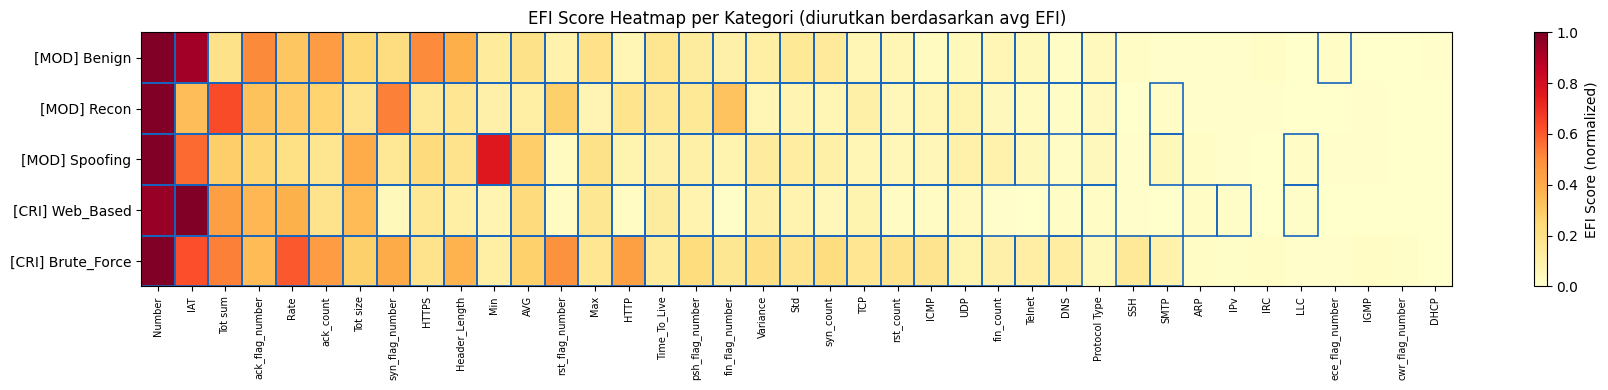

  Figure 1 tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Results/Visualizations/Langkah5_CAFW_EFI_Heatmap.png


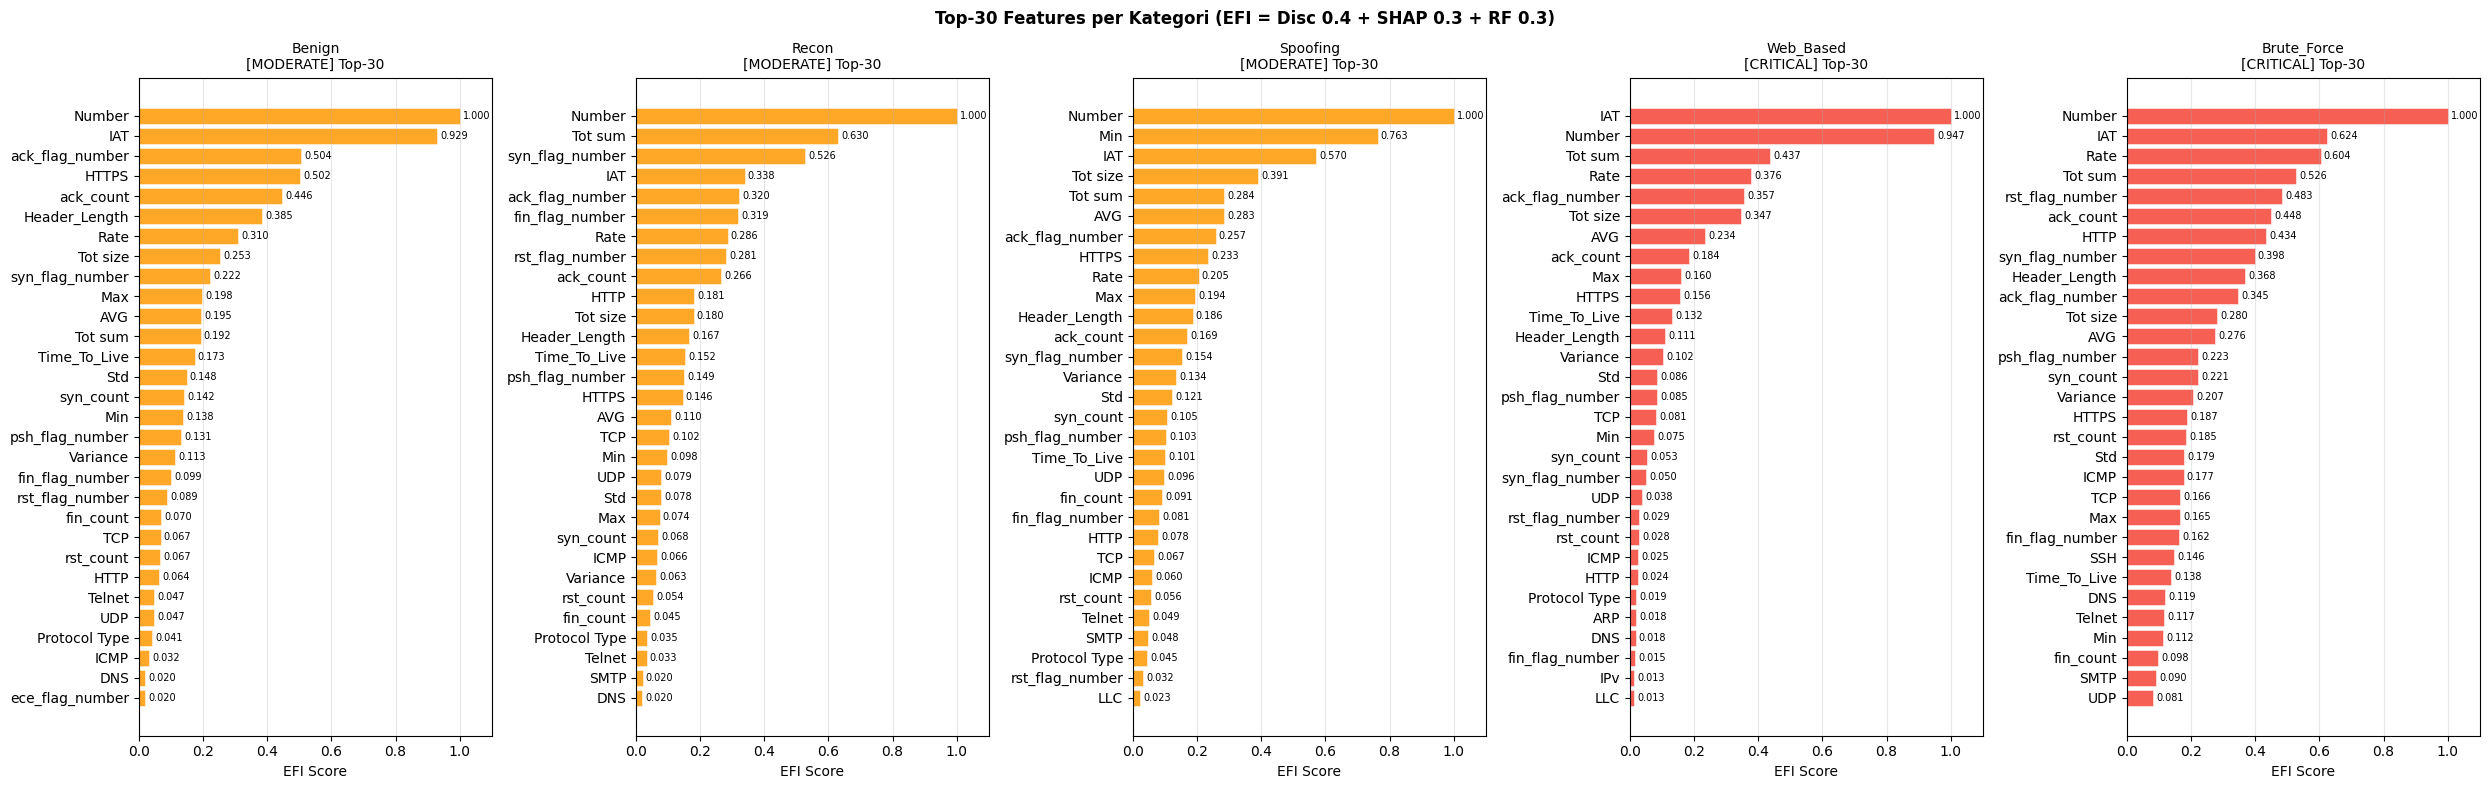

  Figure 2 tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Results/Visualizations/Langkah5_CAFW_Top30_per_Kategori.png


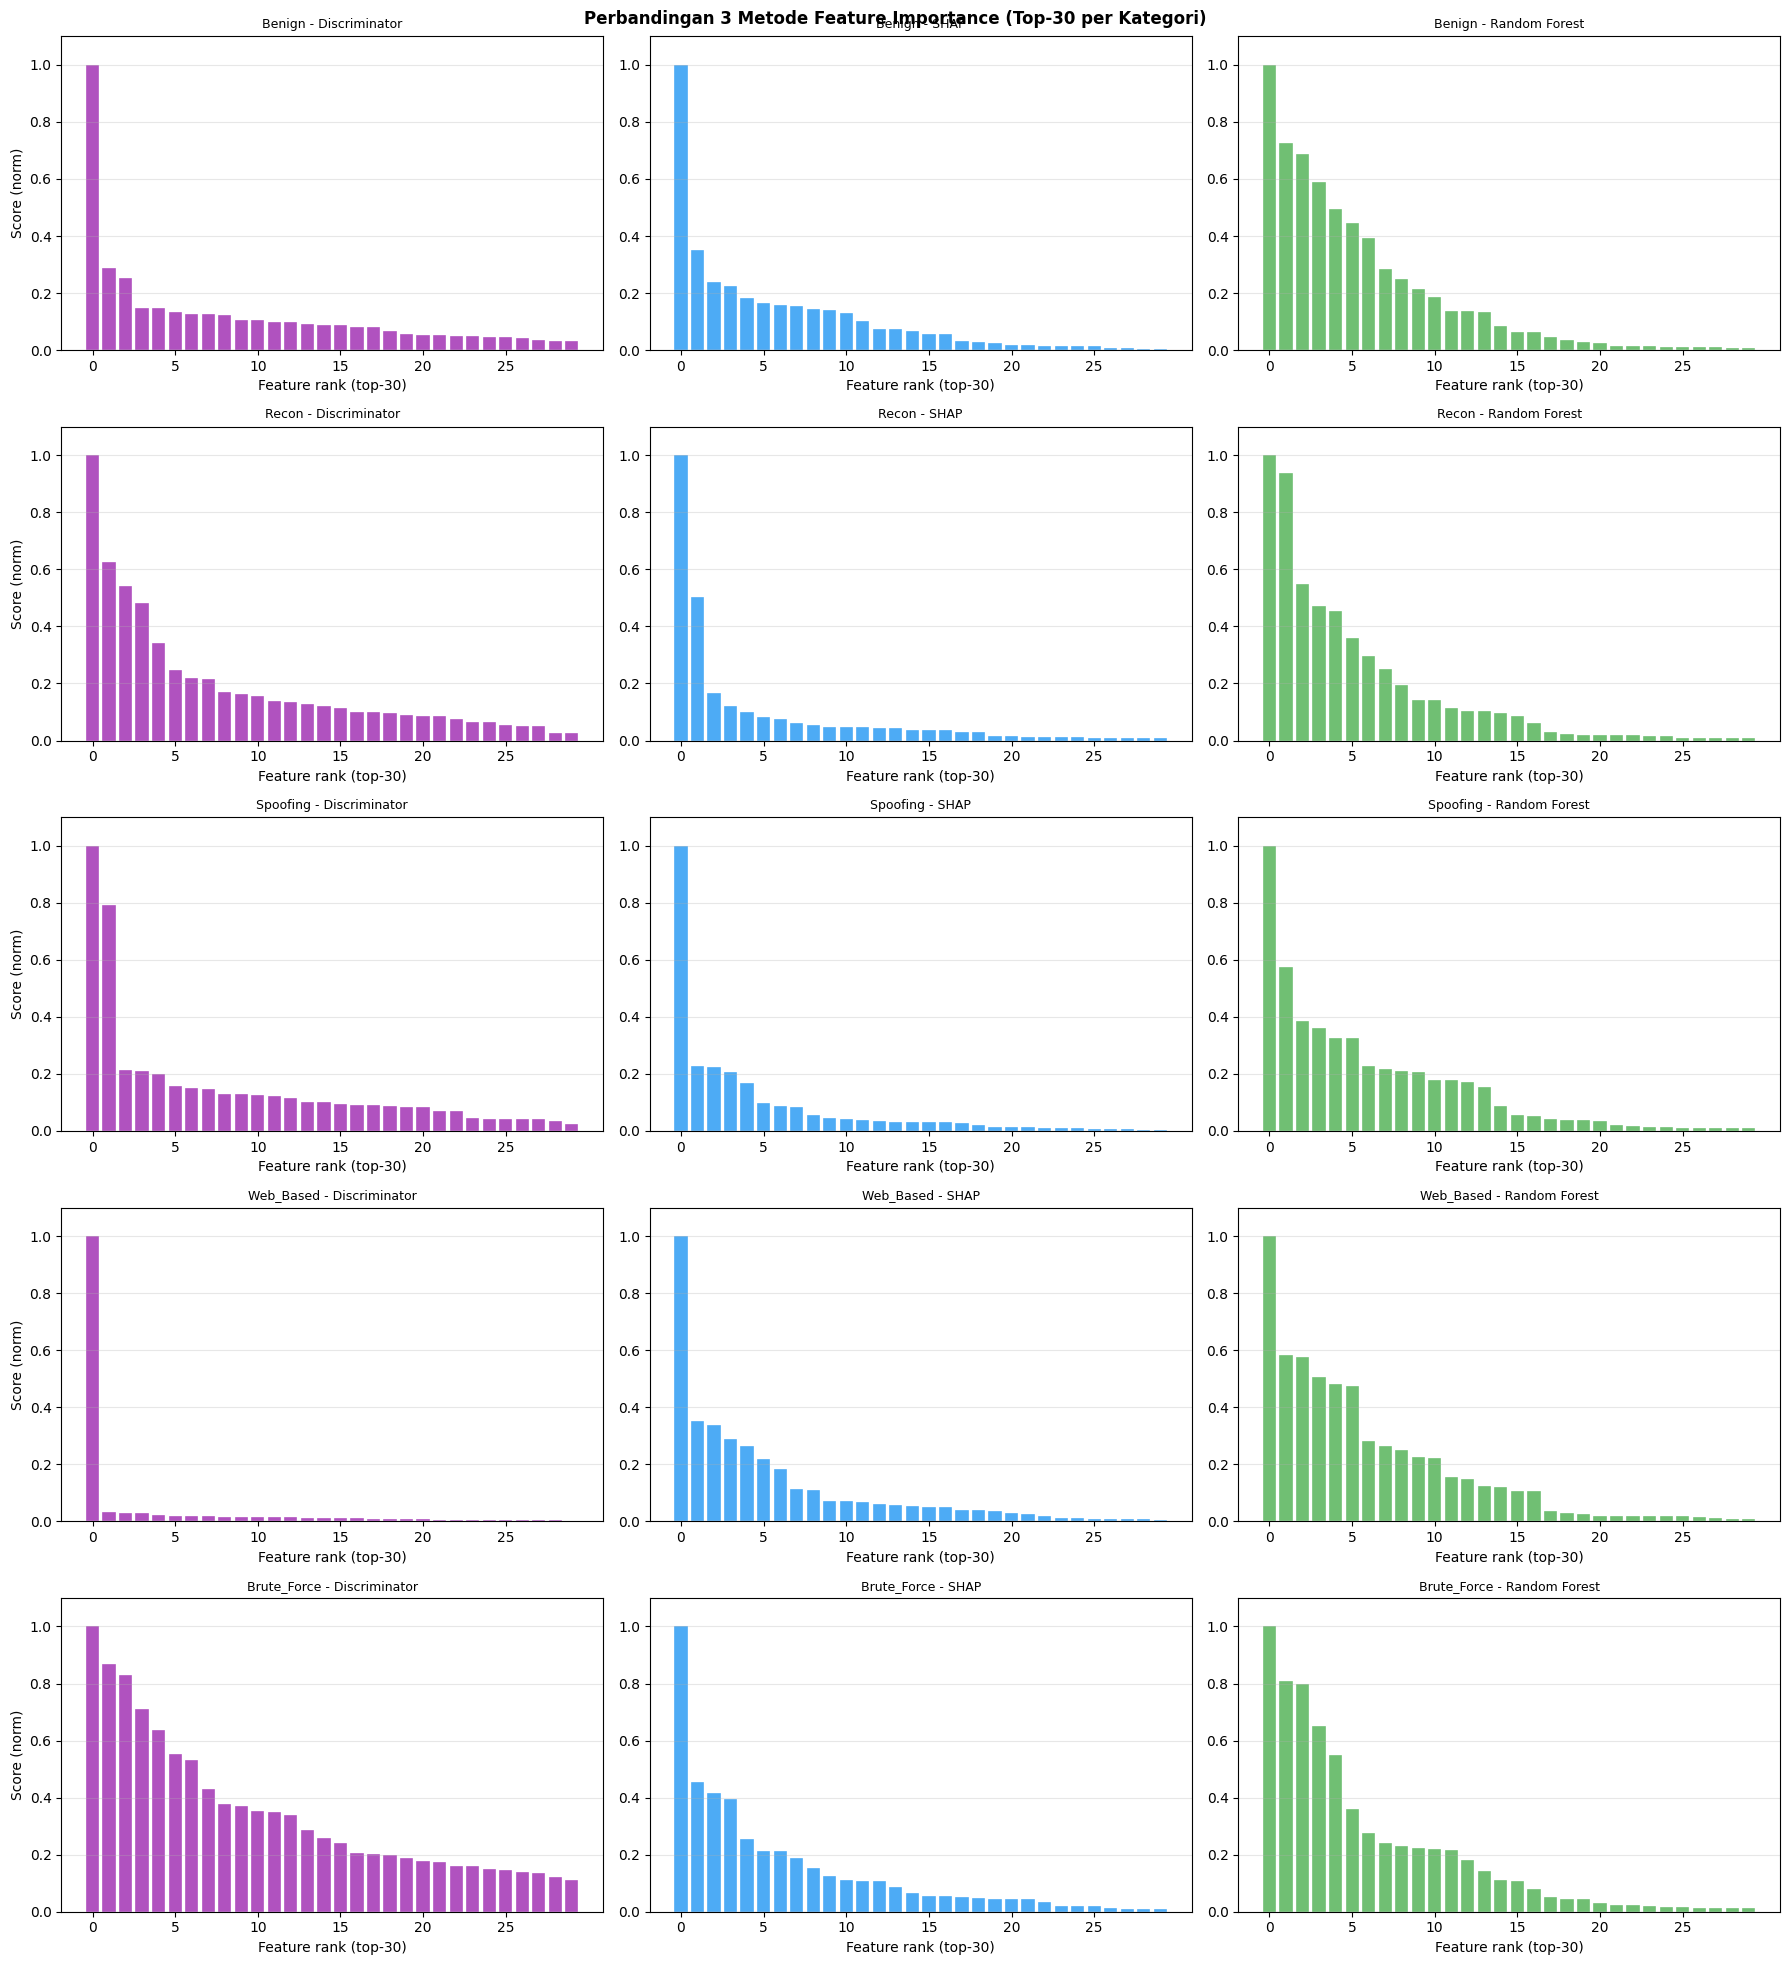

  Figure 3 tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Results/Visualizations/Langkah5_CAFW_Perbandingan_3_Metode.png


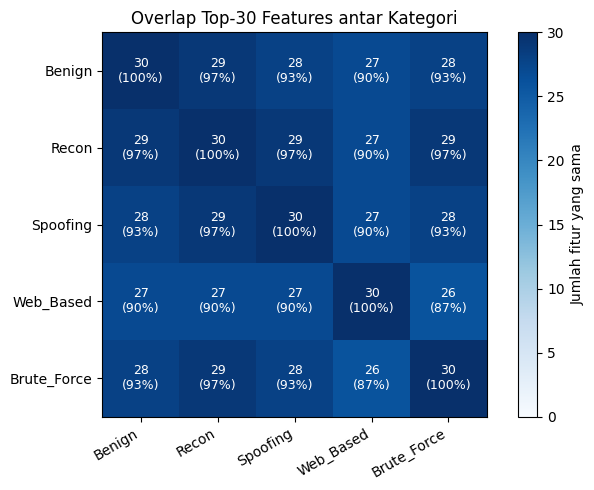

  Figure 4 tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Results/Visualizations/Langkah5_CAFW_Overlap_Antar_Kategori.png


In [ ]:
print("Membuat visualisasi")
print("-" * 40)

seg_colors = {'moderate': '#FF9800', 'critical': '#F44336'}

# ===== Figure 1: EFI Heatmap (kategori x fitur) =====
fig1, ax1 = plt.subplots(figsize=(18, 4))

# Sort fitur berdasarkan rata-rata EFI semua kategori
avg_efi  = efi_matrix.mean(axis=0)
sort_idx = np.argsort(avg_efi)[::-1]
efi_sort = efi_matrix[:, sort_idx]
feat_sort_names = [feature_names[i] for i in sort_idx]

im = ax1.imshow(efi_sort, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax1.set_yticks(range(len(TARGET_CATS)))
ax1.set_yticklabels(
    [f"[{cafw_results[c]['segment'][:3].upper()}] {c}" for c in TARGET_CATS],
    fontsize=10
)
ax1.set_xticks(range(n_features))
ax1.set_xticklabels(feat_sort_names, rotation=90, fontsize=7)
ax1.set_title('EFI Score Heatmap per Kategori (diurutkan berdasarkan avg EFI)',
              fontsize=12)
plt.colorbar(im, ax=ax1, label='EFI Score (normalized)')

# Tandai top-30 dengan border biru
for row_i, cat_name in enumerate(TARGET_CATS):
    top_set = set(cafw_results[cat_name]['top_30_indices'])
    for col_j, feat_idx in enumerate(sort_idx):
        if feat_idx in top_set:
            rect = plt.Rectangle((col_j - 0.5, row_i - 0.5), 1, 1,
                                   fill=False, edgecolor='#1565C0', linewidth=1.2)
            ax1.add_patch(rect)

plt.tight_layout()
path_fig1 = os.path.join(VISUALIZATION_DIR, 'Langkah5_CAFW_EFI_Heatmap.png')
plt.savefig(path_fig1, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure 1 tersimpan: {path_fig1}")

# ===== Figure 2: Top-30 per kategori (horizontal bar) =====
n_cats  = len(TARGET_CATS)
fig2, axes2 = plt.subplots(1, n_cats, figsize=(5 * n_cats, 8))
if n_cats == 1:
    axes2 = [axes2]

for ax, cat_name in zip(axes2, TARGET_CATS):
    seg    = cafw_results[cat_name]['segment']
    color  = seg_colors[seg]
    names  = cafw_results[cat_name]['top_30_names']
    scores = cafw_results[cat_name]['top_30_scores']

    # Urutan ascending untuk barh (skor tertinggi di atas)
    order  = np.argsort(scores)
    y_names  = [names[i] for i in order]
    y_scores = [scores[i] for i in order]

    bars = ax.barh(y_names, y_scores, color=color,
                   edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.set_xlabel('EFI Score')
    ax.set_title(f'{cat_name}\n[{seg.upper()}] Top-{TOP_K}', fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, 1.1)

    for bar, sc in zip(bars, y_scores):
        ax.text(sc + 0.01, bar.get_y() + bar.get_height()/2,
                f'{sc:.3f}', va='center', fontsize=7)

fig2.suptitle(
    f'Top-{TOP_K} Features per Kategori '
    f'(EFI = Disc {W_DISC} + SHAP {W_SHAP} + RF {W_RF})',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path_fig2 = os.path.join(VISUALIZATION_DIR, 'Langkah5_CAFW_Top30_per_Kategori.png')
plt.savefig(path_fig2, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure 2 tersimpan: {path_fig2}")

# ===== Figure 3: Perbandingan 3 metode per kategori =====
method_info = [
    ('disc_norm', 'Discriminator', '#9C27B0'),
    ('shap_norm', 'SHAP',          '#2196F3'),
    ('rf_norm',   'Random Forest', '#4CAF50'),
]

fig3, axes3 = plt.subplots(len(TARGET_CATS), 3,
                             figsize=(18, 4 * len(TARGET_CATS)),
                             sharey=False)
if len(TARGET_CATS) == 1:
    axes3 = [axes3]

for row_i, cat_name in enumerate(TARGET_CATS):
    for col_j, (mkey, mname, mcolor) in enumerate(method_info):
        ax = axes3[row_i][col_j]
        scores_m = np.array(cafw_results[cat_name][mkey])
        top_idx  = np.argsort(scores_m)[-TOP_K:][::-1]

        ax.bar(range(TOP_K), scores_m[top_idx],
               color=mcolor, alpha=0.8, edgecolor='white', linewidth=0.3)
        ax.set_title(f'{cat_name} - {mname}', fontsize=9)
        ax.set_xlabel('Feature rank (top-30)')
        ax.set_ylabel('Score (norm)' if col_j == 0 else '')
        ax.set_ylim(0, 1.1)
        ax.grid(axis='y', alpha=0.3)
        ax.set_xticks(range(0, TOP_K, 5))

fig3.suptitle('Perbandingan 3 Metode Feature Importance (Top-30 per Kategori)',
              fontsize=12, fontweight='bold')
plt.tight_layout()
path_fig3 = os.path.join(VISUALIZATION_DIR, 'Langkah5_CAFW_Perbandingan_3_Metode.png')
plt.savefig(path_fig3, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure 3 tersimpan: {path_fig3}")

# ===== Figure 4: Overlap heatmap antar kategori =====
n_c    = len(TARGET_CATS)
overlap_mat = np.zeros((n_c, n_c), dtype=int)

for i, cat_a in enumerate(TARGET_CATS):
    for j, cat_b in enumerate(TARGET_CATS):
        overlap_mat[i, j] = len(feat_sets[cat_a] & feat_sets[cat_b])

fig4, ax4 = plt.subplots(figsize=(7, 5))
im4 = ax4.imshow(overlap_mat, cmap='Blues', vmin=0, vmax=TOP_K)
ax4.set_xticks(range(n_c))
ax4.set_yticks(range(n_c))
ax4.set_xticklabels(TARGET_CATS, rotation=30, ha='right', fontsize=10)
ax4.set_yticklabels(TARGET_CATS, fontsize=10)
ax4.set_title(f'Overlap Top-{TOP_K} Features antar Kategori', fontsize=12)
plt.colorbar(im4, ax=ax4, label='Jumlah fitur yang sama')

for i in range(n_c):
    for j in range(n_c):
        pct = overlap_mat[i, j] / TOP_K * 100
        ax4.text(j, i, f'{overlap_mat[i,j]}\n({pct:.0f}%)',
                 ha='center', va='center', fontsize=9,
                 color='white' if overlap_mat[i, j] > TOP_K * 0.6 else 'black')

plt.tight_layout()
path_fig4 = os.path.join(VISUALIZATION_DIR, 'Langkah5_CAFW_Overlap_Antar_Kategori.png')
plt.savefig(path_fig4, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure 4 tersimpan: {path_fig4}")

####**5.7 Ringkasan**

In [ ]:
print("Ringkasan Langkah 5 - Category-Aware Feature Weighting")
print("=" * 60)

print(f"\nMetode EFI    : Discriminator ({W_DISC}) + SHAP ({W_SHAP}) + RF ({W_RF})")
print(f"Top-K         : {TOP_K} features per kategori")
print(f"Epsilon       : {EPSILON}")

print(f"\nHasil per kategori:")
print(f"  {'Kategori':<15} {'Segmen':<10} {'Samples':>8}   {'Top-3 Features'}")
print(f"  {'-'*70}")
for cat_name in TARGET_CATS:
    seg   = cafw_results[cat_name]['segment']
    n_s   = cafw_results[cat_name]['n_samples']
    top3  = cafw_results[cat_name]['top_30_names'][:3]
    print(f"  {cat_name:<15} {seg:<10} {n_s:>8,}   {', '.join(top3)}")

print(f"\nFile tersimpan di: {CAFW_DIR}")
for fname in ['cafw_full_results.json', 'cafw_top_features.json',
              'cafw_efi_matrix.npy', 'cafw_metadata.json']:
    print(f"  {fname}")
print(f"  cafw_[kategori].json (5 checkpoint per kategori)")

print(f"\nVisualisasi tersimpan di: {VISUALIZATION_DIR}")
for fname in ['Langkah5_CAFW_EFI_Heatmap.png',
              'Langkah5_CAFW_Top30_per_Kategori.png',
              'Langkah5_CAFW_Perbandingan_3_Metode.png',
              'Langkah5_CAFW_Overlap_Antar_Kategori.png']:
    print(f"  {fname}")

mem = psutil.virtual_memory()
print(f"\nRAM tersisa: {mem.available / 1024**3:.2f} GB")
gc.collect()
print("gc.collect() selesai.")
print("\nLangkah 5 selesai. Siap lanjut ke Langkah 6 (CVAE).")
print("=" * 60)

Ringkasan Langkah 5 - Category-Aware Feature Weighting

Metode EFI    : Discriminator (0.4) + SHAP (0.3) + RF (0.3)
Top-K         : 30 features per kategori
Epsilon       : 1e-05

Hasil per kategori:
  Kategori        Segmen      Samples   Top-3 Features
  ----------------------------------------------------------------------
  Benign          moderate    875,041   Number, IAT, ack_flag_number
  Recon           moderate    547,578   Number, Tot sum, syn_flag_number
  Spoofing        moderate    363,923   Number, Min, IAT
  Web_Based       critical     19,786   IAT, Number, Tot sum
  Brute_Force     critical     10,450   Number, IAT, Rate

File tersimpan di: /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/03_CAFW/
  cafw_full_results.json
  cafw_top_features.json
  cafw_efi_matrix.npy
  cafw_metadata.json
  cafw_[kategori].json (5 checkpoint per kategori)

Visualisasi tersimpan di: /content/drive/My Drive/Framework/CICIoT2023/Results/Visualizations/
  Langkah5_CAFW_EFI_Heatmap.

##**Langkah 6: CVAE Training (untuk Moderate Classes)**

####**6.1 Setup dan Verifikasi**

In [ ]:
print("Setup dan verifikasi")
print("-" * 40)

# Konfigurasi CVAE sesuai spesifikasi
INPUT_DIM  = 39
LATENT_DIM = 128
BETA       = 0.75     # 75% reconstruction, 25% KL
BATCH_SIZE = 512
EPOCHS     = 50
PATIENCE   = 10
LR         = 0.001
TOP_K      = 30

# Target augmentasi: bawa semua moderate ke 1,000,000 samples
TARGET_PER_CLASS = 1_000_000

# Konfigurasi validasi
N_TSNE_PER_CLASS = 500    # samples per kelas untuk t-SNE
N_KS_SAMPLES     = 5_000  # samples untuk KS-test
RANDOM_STATE     = 42

print(f"Arsitektur CVAE:")
print(f"  Input dim  : {INPUT_DIM}")
print(f"  Encoder    : {INPUT_DIM} -> 128 -> 64 -> Latent({LATENT_DIM})")
print(f"  Decoder    : Latent({LATENT_DIM}) -> 64 -> 128 -> {INPUT_DIM}")
print(f"  Beta       : {BETA} (recon={BETA}, KL={round(1-BETA, 2)})")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Epochs     : {EPOCHS} (early stopping patience={PATIENCE})")
print(f"  Optimizer  : Adam (lr={LR})")
print(f"  Target/kelas : {TARGET_PER_CLASS:,}")

# Verifikasi data moderate di memory
print(f"\nVerifikasi data moderate:")
print(f"  X_moderate : {X_moderate.shape}")
print(f"  y_moderate : {y_moderate.shape}")

print(f"\nRincian augmentasi per kelas:")
for cat in moderate_cats:
    enc  = NAME_TO_ENC[cat]
    cnt  = int(np.sum(y_moderate == enc))
    need = max(0, TARGET_PER_CLASS - cnt)
    print(f"  {cat:<12} : {cnt:>9,} real -> perlu {need:>9,} synthetic")

# Verifikasi CAFW results
print(f"\nVerifikasi CAFW results:")
for cat in moderate_cats:
    n_top = len(cafw_results[cat]['top_30_indices'])
    print(f"  {cat}: {n_top} top features [OK]")

os.makedirs(CVAE_DIR, exist_ok=True)
mem = psutil.virtual_memory()
print(f"\nRAM tersisa: {mem.available / 1024**3:.2f} GB")

Setup dan verifikasi
----------------------------------------
Arsitektur CVAE:
  Input dim  : 39
  Encoder    : 39 -> 128 -> 64 -> Latent(128)
  Decoder    : Latent(128) -> 64 -> 128 -> 39
  Beta       : 0.75 (recon=0.75, KL=0.25)
  Batch size : 512
  Epochs     : 50 (early stopping patience=10)
  Optimizer  : Adam (lr=0.001)
  Target/kelas : 1,000,000

Verifikasi data moderate:
  X_moderate : (1786542, 39)
  y_moderate : (1786542,)

Rincian augmentasi per kelas:
  Benign       :   875,041 real -> perlu   124,959 synthetic
  Recon        :   547,578 real -> perlu   452,422 synthetic
  Spoofing     :   363,923 real -> perlu   636,077 synthetic

Verifikasi CAFW results:
  Benign: 30 top features [OK]
  Recon: 30 top features [OK]
  Spoofing: 30 top features [OK]

RAM tersisa: 35.43 GB


####**6.2 Persiapan data untuk CVAE**

In [ ]:
print("Persiapan data untuk CVAE")

moderate_data = {}

for cat in moderate_cats:
    enc  = NAME_TO_ENC[cat]
    mask = (y_moderate == enc)

    X_cat = X_moderate[mask].astype(np.float32)
    y_cat = y_moderate[mask]

    # Hitung feature weights dari EFI scores
    efi_raw = np.array(cafw_results[cat]['efi_scores'], dtype=np.float32)

    # Floor 0.01 agar semua fitur tetap berkontribusi
    # Normalisasi agar mean weight = 1.0 (skala loss stabil)
    efi_floored   = np.clip(efi_raw, 0.01, 1.0)
    feature_weights = efi_floored / efi_floored.mean()

    n_need = max(0, TARGET_PER_CLASS - len(X_cat))

    moderate_data[cat] = {
        'X'               : X_cat,
        'y'               : y_cat,
        'enc'             : int(enc),
        'n_real'          : int(len(X_cat)),
        'n_synthetic'     : int(n_need),
        'top_k_indices'   : cafw_results[cat]['top_30_indices'],
        'efi_scores'      : efi_raw,
        'feature_weights' : feature_weights,
    }

    print(f"\n  [{cat}]")
    print(f"    X shape         : {X_cat.shape}")
    print(f"    Encoded label   : {enc}")
    print(f"    Synthetic needed: {n_need:,}")
    print(f"    Weight min/max  : {feature_weights.min():.4f} / {feature_weights.max():.4f}")
    print(f"    Weight mean     : {feature_weights.mean():.4f}")

    # Validasi NaN/Inf
    n_nan = np.isnan(X_cat).sum()
    n_inf = np.isinf(X_cat).sum()
    if n_nan == 0 and n_inf == 0:
        print(f"    NaN/Inf check   : OK")
    else:
        print(f"    NaN/Inf check   : {n_nan} NaN, {n_inf} Inf -> diperbaiki")
        moderate_data[cat]['X'] = np.nan_to_num(X_cat, nan=0.0, posinf=1.0, neginf=-1.0)

print("\nPersiapan data selesai.")

Persiapan data untuk CVAE

  [Benign]
    X shape         : (875041, 39)
    Encoded label   : 0
    Synthetic needed: 124,959
    Weight min/max  : 0.0578 / 5.7758
    Weight mean     : 1.0000
    NaN/Inf check   : OK

  [Recon]
    X shape         : (547578, 39)
    Encoded label   : 5
    Synthetic needed: 452,422
    Weight min/max  : 0.0653 / 6.5263
    Weight mean     : 1.0000
    NaN/Inf check   : OK

  [Spoofing]
    X shape         : (363923, 39)
    Encoded label   : 6
    Synthetic needed: 636,077
    Weight min/max  : 0.0641 / 6.4102
    Weight mean     : 1.0000
    NaN/Inf check   : OK

Persiapan data selesai.


####**6.3 Definisi Arsitektur CVAE**

In [ ]:
print("Definisi arsitektur CVAE")

class CVAEEncoder(tf.keras.layers.Layer):
    """
    Encoder: input_dim -> Dense(128,ReLU) -> Dense(64,ReLU) -> [mu, log_var](latent_dim)
    """
    def __init__(self, latent_dim, **kwargs):
        super().__init__(**kwargs)
        self.dense1   = layers.Dense(128, activation='relu', name='enc_d1')
        self.dense2   = layers.Dense(64,  activation='relu', name='enc_d2')
        self.mu_layer = layers.Dense(latent_dim,             name='enc_mu')
        self.lv_layer = layers.Dense(latent_dim,             name='enc_logvar')

    def call(self, x, training=False):
        h = self.dense1(x)
        h = self.dense2(h)
        return self.mu_layer(h), self.lv_layer(h)


class CVAEDecoder(tf.keras.layers.Layer):
    """
    Decoder: latent_dim -> Dense(64,ReLU) -> Dense(128,ReLU) -> output_dim (linear)
    """
    def __init__(self, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.dense1 = layers.Dense(64,  activation='relu', name='dec_d1')
        self.dense2 = layers.Dense(128, activation='relu', name='dec_d2')
        self.out    = layers.Dense(output_dim,             name='dec_out')

    def call(self, z, training=False):
        h = self.dense1(z)
        h = self.dense2(h)
        return self.out(h)


class CVAE(tf.keras.Model):
    """
    Variational Autoencoder dengan feature-importance weighted reconstruction loss.
    Total loss = beta * weighted_recon_loss + (1-beta) * KL_loss
               = 0.75 * recon + 0.25 * KL
    """
    def __init__(self, input_dim, latent_dim, feature_weights,
                 beta=0.75, **kwargs):
        super().__init__(**kwargs)
        self.input_dim       = input_dim
        self.latent_dim      = latent_dim
        self.beta            = beta
        self.fw              = tf.constant(feature_weights, dtype=tf.float32)

        self.encoder = CVAEEncoder(latent_dim)
        self.decoder = CVAEDecoder(input_dim)

        self.total_loss_tracker = tf.keras.metrics.Mean(name='loss')
        self.recon_loss_tracker = tf.keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker    = tf.keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def reparameterize(self, mu, log_var):
        """Reparameterization trick: z = mu + eps * exp(0.5 * log_var)"""
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + eps * tf.exp(0.5 * log_var)

    def call(self, x, training=False):
        mu, log_var = self.encoder(x, training=training)
        z           = self.reparameterize(mu, log_var)
        x_recon     = self.decoder(z, training=training)
        return x_recon, mu, log_var

    def compute_loss(self, x):
        x_recon, mu, log_var = self(x, training=True)

        # Weighted MSE reconstruction loss
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(self.fw * tf.square(x - x_recon), axis=1)
        )

        # KL divergence: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1.0 + log_var - tf.square(mu) - tf.exp(log_var), axis=1)
        )

        total_loss = self.beta * recon_loss + (1.0 - self.beta) * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self.compute_loss(x)

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        total_loss, recon_loss, kl_loss = self.compute_loss(x)

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def generate(self, n_samples, seed=42):
        """Sample dari prior N(0,I) dan decode ke feature space."""
        tf.random.set_seed(seed)
        z = tf.random.normal(shape=(n_samples, self.latent_dim))
        return self.decoder(z, training=False).numpy()


print("Kelas CVAE berhasil didefinisikan:")
print("  CVAEEncoder : input -> Dense(128,ReLU) -> Dense(64,ReLU) -> [mu, log_var](128)")
print("  CVAEDecoder : z(128) -> Dense(64,ReLU) -> Dense(128,ReLU) -> output(39)")
print("  CVAE loss   : 0.75*weighted_recon + 0.25*KL")

Definisi arsitektur CVAE
Kelas CVAE berhasil didefinisikan:
  CVAEEncoder : input -> Dense(128,ReLU) -> Dense(64,ReLU) -> [mu, log_var](128)
  CVAEDecoder : z(128) -> Dense(64,ReLU) -> Dense(128,ReLU) -> output(39)
  CVAE loss   : 0.75*weighted_recon + 0.25*KL


####**6.4 Training CVAE dan Generate Synthetic Samples per Kategori**

In [ ]:
print("Training CVAE dan generate synthetic samples")
print("-" * 40)

# Storage untuk hasil per kategori
cvae_models      = {}    # simpan model per cat (di memory)
synthetic_data   = {}    # synthetic X dan y per cat
training_history = {}    # history per cat

t_total = time.time()

for idx_cat, cat in enumerate(moderate_cats):
    print(f"\n{'='*55}")
    print(f"[{idx_cat+1}/{len(moderate_cats)}] Kategori: {cat}")
    print(f"{'='*55}")

    t_cat = time.time()
    cdata = moderate_data[cat]
    X_cat = cdata['X']
    n_real   = cdata['n_real']
    n_synth  = cdata['n_synthetic']
    enc_lbl  = cdata['enc']

    # Lewati jika tidak perlu generate
    if n_synth == 0:
        print(f"  Sudah >= {TARGET_PER_CLASS:,} samples, tidak perlu augmentasi.")
        synthetic_data[cat] = {
            'X_synthetic' : np.empty((0, INPUT_DIM), dtype=np.float32),
            'y_synthetic' : np.empty((0,), dtype=np.int64),
            'n_synthetic' : 0,
        }
        continue

    # ---------------------------------------------------------
    # a. Bangun CVAE untuk kategori ini
    # ---------------------------------------------------------
    print(f"\n  [a] Membangun CVAE...")
    tf.keras.backend.clear_session()

    cvae = CVAE(
        input_dim=INPUT_DIM,
        latent_dim=LATENT_DIM,
        feature_weights=cdata['feature_weights'],
        beta=BETA,
        name=f'cvae_{cat}'
    )
    cvae.compile(optimizer=optimizers.Adam(learning_rate=LR))

    # Build model dengan dummy call
    _ = cvae(tf.zeros((1, INPUT_DIM)))
    n_params = cvae.count_params()
    print(f"  Total parameter  : {n_params:,}")

    # ---------------------------------------------------------
    # b. Training CVAE
    # ---------------------------------------------------------
    print(f"\n  [b] Training CVAE pada {n_real:,} samples...")
    print(f"      Epochs max: {EPOCHS} | Patience: {PATIENCE} | Batch: {BATCH_SIZE}")

    callbacks = [
        EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True, verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5,
            min_lr=1e-5, verbose=0
        )
    ]

    t_train = time.time()
    history = cvae.fit(
        X_cat, X_cat,           # autoencoder: input = target
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=0,
        shuffle=True
    )

    elapsed_train = time.time() - t_train
    n_epochs_run  = len(history.history['loss'])
    final_loss    = history.history['loss'][-1]
    final_recon   = history.history['recon_loss'][-1]
    final_kl      = history.history['kl_loss'][-1]
    val_loss_fin  = history.history['val_loss'][-1]

    print(f"      Epochs dijalankan : {n_epochs_run}/{EPOCHS}")
    print(f"      Train loss final  : {final_loss:.4f}")
    print(f"      Train recon loss  : {final_recon:.4f}")
    print(f"      Train KL loss     : {final_kl:.4f}")
    print(f"      Val loss final    : {val_loss_fin:.4f}")
    print(f"      Waktu training    : {elapsed_train:.1f} detik")

    training_history[cat] = {
        'loss'       : [float(v) for v in history.history['loss']],
        'recon_loss' : [float(v) for v in history.history['recon_loss']],
        'kl_loss'    : [float(v) for v in history.history['kl_loss']],
        'val_loss'   : [float(v) for v in history.history['val_loss']],
        'n_epochs'   : n_epochs_run,
    }

    # ---------------------------------------------------------
    # c. Generate synthetic samples
    # ---------------------------------------------------------
    print(f"\n  [c] Generate {n_synth:,} synthetic samples...")

    t_gen = time.time()

    # Generate dalam batch untuk efisiensi memory
    GEN_BATCH     = 50_000
    n_batches     = (n_synth + GEN_BATCH - 1) // GEN_BATCH
    X_synth_parts = []

    for b in range(n_batches):
        n_this = min(GEN_BATCH, n_synth - b * GEN_BATCH)
        X_part = cvae.generate(n_this, seed=RANDOM_STATE + b)
        X_synth_parts.append(X_part)
        if (b + 1) % 5 == 0 or (b + 1) == n_batches:
            print(f"      Batch {b+1}/{n_batches} selesai | {(b+1)*GEN_BATCH:,} samples")

    X_synthetic = np.vstack(X_synth_parts).astype(np.float32)
    del X_synth_parts
    gc.collect()

    print(f"      Shape sebelum masking : {X_synthetic.shape}")

    # Masking: set non-top-30 features ke 0 (rata-rata scaled)
    top30_idx   = cdata['top_k_indices']
    mask_feat   = np.zeros(INPUT_DIM, dtype=bool)
    mask_feat[top30_idx] = True

    X_synthetic[:, ~mask_feat] = 0.0
    print(f"      Non-top-30 features   : {(~mask_feat).sum()} fitur di-zero")

    # Clip ke rentang yang wajar berdasarkan data real
    X_real_min = X_cat.min(axis=0)
    X_real_max = X_cat.max(axis=0)
    margin     = 0.1 * (X_real_max - X_real_min)
    X_synthetic = np.clip(X_synthetic,
                          X_real_min - margin,
                          X_real_max + margin)

    # Buat label untuk synthetic
    y_synthetic = np.full(n_synth, enc_lbl, dtype=np.int64)

    elapsed_gen = time.time() - t_gen
    print(f"      Shape setelah masking : {X_synthetic.shape}")
    print(f"      Waktu generate        : {elapsed_gen:.1f} detik")

    # Validasi quick: cek NaN/Inf di synthetic
    n_nan_s = np.isnan(X_synthetic).sum()
    n_inf_s = np.isinf(X_synthetic).sum()
    print(f"      NaN={n_nan_s}, Inf={n_inf_s}", end="")
    if n_nan_s == 0 and n_inf_s == 0:
        print(" [OK]")
    else:
        X_synthetic = np.nan_to_num(X_synthetic, nan=0.0, posinf=1.0, neginf=-1.0)
        print(f" -> diperbaiki")

    # Simpan ke storage
    synthetic_data[cat] = {
        'X_synthetic' : X_synthetic,
        'y_synthetic' : y_synthetic,
        'n_synthetic' : n_synth,
    }

    # Simpan model weights
    weights_path = os.path.join(CVAE_DIR, f'cvae_weights_{cat}.weights.h5')
    cvae.save_weights(weights_path)
    print(f"\n  Model weights tersimpan : {weights_path}")

    # Simpan synthetic data per kategori sebagai checkpoint
    np.save(os.path.join(CVAE_DIR, f'X_synthetic_{cat}.npy'), X_synthetic)
    np.save(os.path.join(CVAE_DIR, f'y_synthetic_{cat}.npy'), y_synthetic)
    print(f"  Synthetic data tersimpan: CVAE_DIR/X_synthetic_{cat}.npy")

    # Simpan training history per kategori
    hist_path = os.path.join(CVAE_DIR, f'cvae_history_{cat}.json')
    with open(hist_path, 'w') as f:
        json.dump(training_history[cat], f, indent=4)
    print(f"  History tersimpan       : {hist_path}")

    # Simpan model untuk validasi (akan dipakai 6.4)
    cvae_models[cat] = cvae

    elapsed_cat = time.time() - t_cat
    print(f"\n  Total waktu [{cat}]: {elapsed_cat:.1f} detik")

    mem = psutil.virtual_memory()
    print(f"  RAM tersisa: {mem.available / 1024**3:.2f} GB")
    gc.collect()

elapsed_total_train = time.time() - t_total
print(f"\nSemua CVAE selesai ditraining dalam {elapsed_total_train/60:.1f} menit")

Training CVAE dan generate synthetic samples
----------------------------------------

[1/3] Kategori: Benign

  [a] Membangun CVAE...
  Total parameter  : 51,623

  [b] Training CVAE pada 875,041 samples...
      Epochs max: 50 | Patience: 10 | Batch: 512
      Epochs dijalankan : 50/50
      Train loss final  : 2.6240
      Train recon loss  : 1.0907
      Train KL loss     : 7.2241
      Val loss final    : 2.6108
      Waktu training    : 230.9 detik

  [c] Generate 124,959 synthetic samples...
      Batch 3/3 selesai | 150,000 samples
      Shape sebelum masking : (124959, 39)
      Non-top-30 features   : 9 fitur di-zero
      Shape setelah masking : (124959, 39)
      Waktu generate        : 0.6 detik
      NaN=0, Inf=0 [OK]

  Model weights tersimpan : /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/04_CVAE/cvae_weights_Benign.weights.h5
  Synthetic data tersimpan: CVAE_DIR/X_synthetic_Benign.npy
  History tersimpan       : /content/drive/My Drive/Framework/CICIoT2023/

####**6.5 Validasi Synthetic Samples (t-SNE dan KS-test)**

In [ ]:
print("Validasi synthetic samples")
print("-" * 40)

ks_results_all = {}
rng_val = np.random.default_rng(RANDOM_STATE)

for cat in moderate_cats:
    print(f"\n  Validasi [{cat}]")

    X_real   = moderate_data[cat]['X']
    n_synth  = synthetic_data[cat]['n_synthetic']

    if n_synth == 0:
        print(f"    Tidak ada synthetic, skip validasi.")
        ks_results_all[cat] = {'skipped': True}
        continue

    X_synth  = synthetic_data[cat]['X_synthetic']
    top30_idx = moderate_data[cat]['top_k_indices']

    # --- KS-test: bandingkan distribusi tiap top-30 fitur ---
    n_ks_real  = min(N_KS_SAMPLES, len(X_real))
    n_ks_synth = min(N_KS_SAMPLES, len(X_synth))

    idx_r = rng_val.choice(len(X_real),  size=n_ks_real,  replace=False)
    idx_s = rng_val.choice(len(X_synth), size=n_ks_synth, replace=False)

    X_r_ks = X_real[idx_r]
    X_s_ks = X_synth[idx_s]

    ks_pass  = 0
    ks_total = len(top30_idx)
    ks_stats = {}

    for feat_idx in top30_idx:
        stat, pval = ks_2samp(X_r_ks[:, feat_idx], X_s_ks[:, feat_idx])
        passed = pval > 0.05
        if passed:
            ks_pass += 1
        ks_stats[feature_names[feat_idx]] = {
            'statistic' : round(float(stat), 6),
            'p_value'   : round(float(pval), 6),
            'passed'    : bool(passed)
        }

    ks_pass_rate = ks_pass / ks_total * 100
    ks_results_all[cat] = {
        'pass_count' : ks_pass,
        'total'      : ks_total,
        'pass_rate'  : round(ks_pass_rate, 2),
        'details'    : ks_stats,
    }

    print(f"    KS-test top-{TOP_K} features:")
    print(f"      Pass  : {ks_pass}/{ks_total} fitur ({ks_pass_rate:.1f}%)")
    print(f"      Threshold p-value : 0.05")

    # Print 5 fitur dengan stat terbesar (paling berbeda)
    sorted_ks = sorted(ks_stats.items(), key=lambda x: x[1]['statistic'], reverse=True)
    print(f"      Top-5 fitur paling berbeda:")
    for fname, fstat in sorted_ks[:5]:
        status = "PASS" if fstat['passed'] else "FAIL"
        print(f"        {fname:<30} stat={fstat['statistic']:.4f} "
              f"pval={fstat['p_value']:.4f} [{status}]")

    del X_r_ks, X_s_ks

# Simpan KS-test results
ks_path = os.path.join(CVAE_DIR, 'cvae_ks_test_results.json')
with open(ks_path, 'w') as f:
    json.dump(ks_results_all, f, indent=4)
print(f"\n  KS-test results tersimpan: {ks_path}")

Validasi synthetic samples
----------------------------------------

  Validasi [Benign]
    KS-test top-30 features:
      Pass  : 1/30 fitur (3.3%)
      Threshold p-value : 0.05
      Top-5 fitur paling berbeda:
        ece_flag_number                stat=0.9834 pval=0.0000 [FAIL]
        rst_flag_number                stat=0.9788 pval=0.0000 [FAIL]
        ICMP                           stat=0.8948 pval=0.0000 [FAIL]
        fin_count                      stat=0.8840 pval=0.0000 [FAIL]
        fin_flag_number                stat=0.8648 pval=0.0000 [FAIL]

  Validasi [Recon]
    KS-test top-30 features:
      Pass  : 0/30 fitur (0.0%)
      Threshold p-value : 0.05
      Top-5 fitur paling berbeda:
        Number                         stat=1.0000 pval=0.0000 [FAIL]
        ack_count                      stat=1.0000 pval=0.0000 [FAIL]
        syn_count                      stat=1.0000 pval=0.0000 [FAIL]
        fin_count                      stat=1.0000 pval=0.0000 [FAIL]
        S

Membuat visualisasi training loss curves...


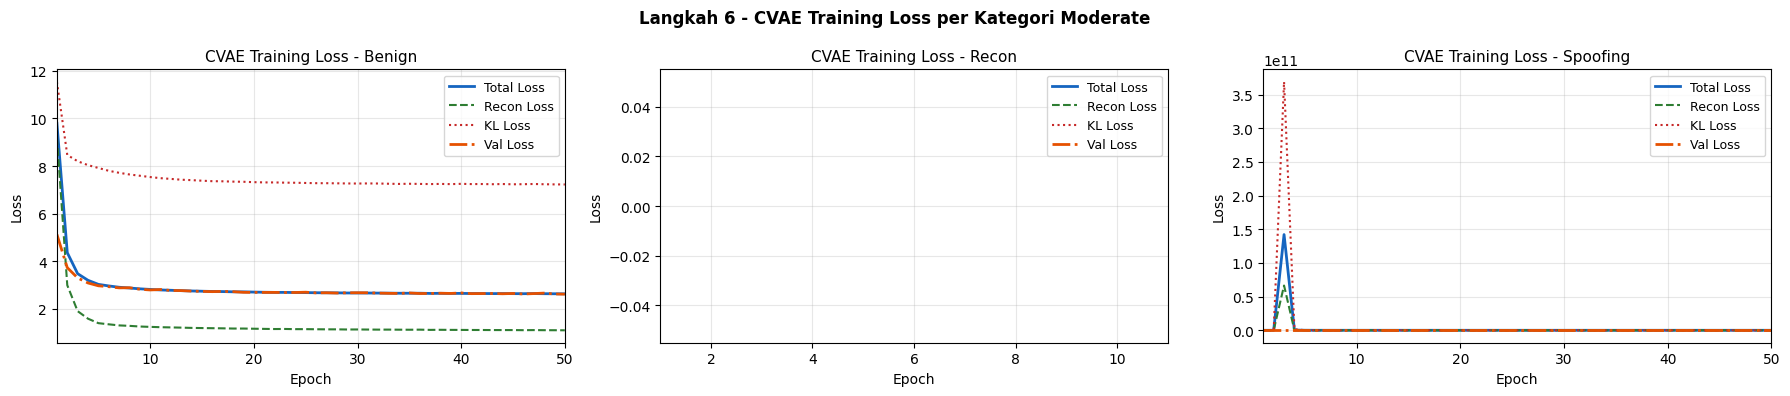

  Figure loss tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Results/Visualizations/Langkah6_CVAE_Training_Loss.png


In [ ]:
# Visualisasi 6.4a: Training loss curves
print("Membuat visualisasi training loss curves...")

n_cats_plot = len(moderate_cats)
fig_loss, axes_loss = plt.subplots(1, n_cats_plot, figsize=(6 * n_cats_plot, 4))
if n_cats_plot == 1:
    axes_loss = [axes_loss]

for ax, cat in zip(axes_loss, moderate_cats):
    if cat not in training_history:
        continue
    hist = training_history[cat]
    ep   = range(1, len(hist['loss']) + 1)

    ax.plot(ep, hist['loss'],       label='Total Loss',  color='#1565C0', linewidth=2)
    ax.plot(ep, hist['recon_loss'], label='Recon Loss',  color='#2E7D32', linewidth=1.5, linestyle='--')
    ax.plot(ep, hist['kl_loss'],    label='KL Loss',     color='#C62828', linewidth=1.5, linestyle=':')
    ax.plot(ep, hist['val_loss'],   label='Val Loss',    color='#E65100', linewidth=2, linestyle='-.')

    ax.set_title(f'CVAE Training Loss - {cat}', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(1, len(hist['loss']))

fig_loss.suptitle('Langkah 6 - CVAE Training Loss per Kategori Moderate',
                   fontsize=12, fontweight='bold')
plt.tight_layout()
path_loss = os.path.join(VISUALIZATION_DIR, 'Langkah6_CVAE_Training_Loss.png')
plt.savefig(path_loss, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure loss tersimpan: {path_loss}")

Membuat visualisasi t-SNE (subsample)...
    t-SNE [Benign]: 500 real + 500 synthetic = 1000 total
    t-SNE selesai dalam 2.9 detik
    t-SNE [Recon]: 500 real + 500 synthetic = 1000 total
    t-SNE selesai dalam 2.7 detik
    t-SNE [Spoofing]: 500 real + 500 synthetic = 1000 total
    t-SNE selesai dalam 2.8 detik


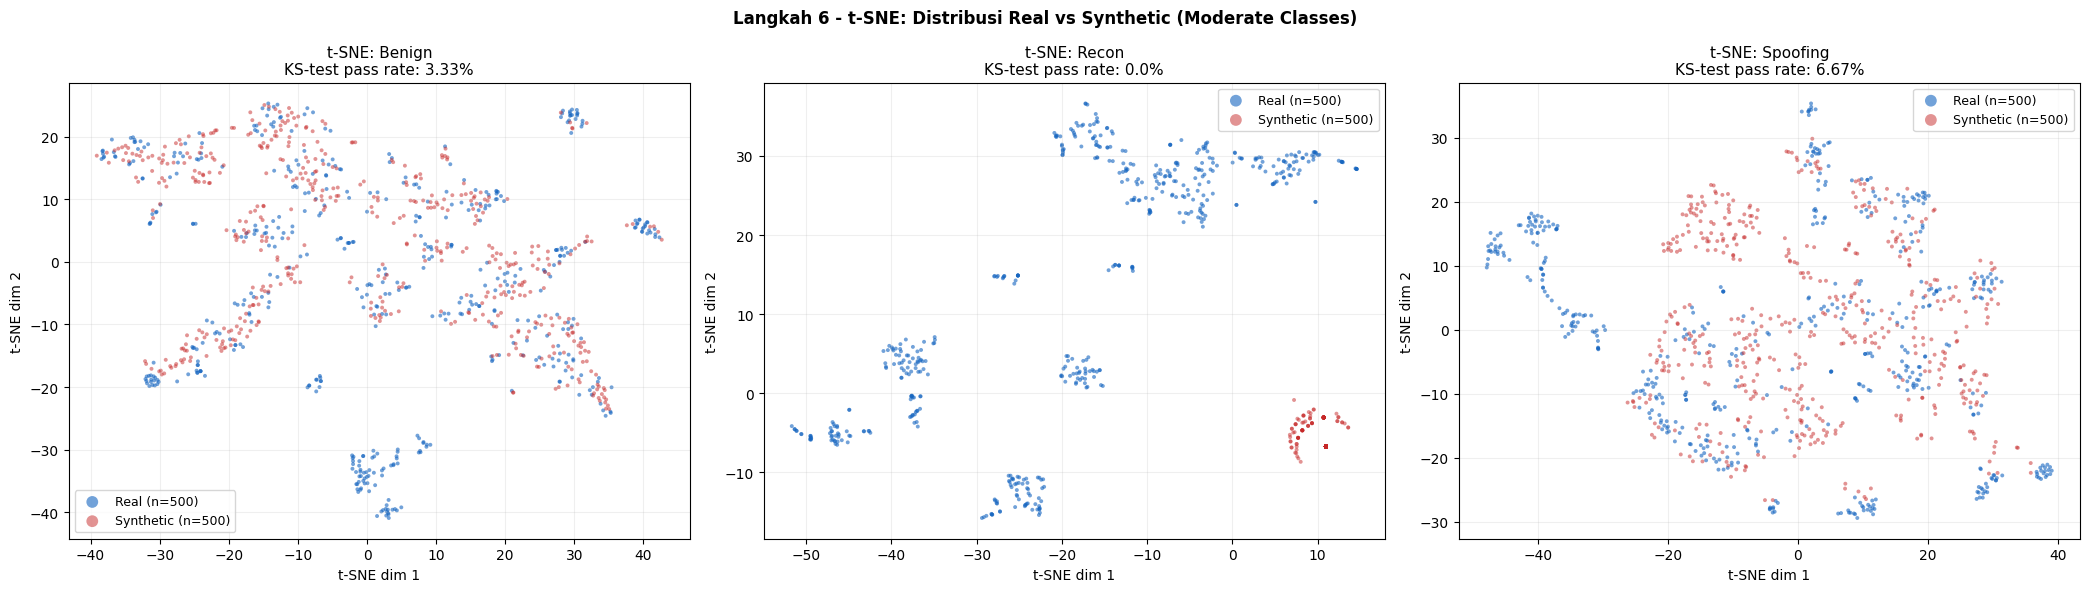

  Figure t-SNE tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Results/Visualizations/Langkah6_CVAE_tSNE_Real_vs_Synthetic.png


In [ ]:
# Visualisasi 6.4b: t-SNE real vs synthetic
print("Membuat visualisasi t-SNE (subsample)...")

cats_with_synth = [c for c in moderate_cats if synthetic_data[c]['n_synthetic'] > 0]
n_tsne_cats     = len(cats_with_synth)

fig_tsne, axes_tsne = plt.subplots(1, n_tsne_cats, figsize=(7 * n_tsne_cats, 6))
if n_tsne_cats == 1:
    axes_tsne = [axes_tsne]

for ax, cat in zip(axes_tsne, cats_with_synth):
    X_real  = moderate_data[cat]['X']
    X_synth = synthetic_data[cat]['X_synthetic']

    # Subsample
    n_r  = min(N_TSNE_PER_CLASS, len(X_real))
    n_s  = min(N_TSNE_PER_CLASS, len(X_synth))
    idx_r = rng_val.choice(len(X_real),  size=n_r, replace=False)
    idx_s = rng_val.choice(len(X_synth), size=n_s, replace=False)

    X_combined = np.vstack([X_real[idx_r], X_synth[idx_s]])
    labels_tsne = np.array(['Real'] * n_r + ['Synthetic'] * n_s)

    print(f"    t-SNE [{cat}]: {n_r} real + {n_s} synthetic = {n_r+n_s} total")

    tsne = TSNE(n_components=2, random_state=RANDOM_STATE,
                perplexity=30, n_iter=1000, verbose=0)
    t_tsne = time.time()
    X_2d   = tsne.fit_transform(X_combined)
    print(f"    t-SNE selesai dalam {time.time()-t_tsne:.1f} detik")

    # Plot
    colors_map = {'Real': '#1565C0', 'Synthetic': '#C62828'}
    alpha_map  = {'Real': 0.6, 'Synthetic': 0.5}
    for lbl in ['Real', 'Synthetic']:
        mask_lbl = (labels_tsne == lbl)
        ax.scatter(
            X_2d[mask_lbl, 0], X_2d[mask_lbl, 1],
            c=colors_map[lbl], label=f'{lbl} (n={mask_lbl.sum():,})',
            alpha=alpha_map[lbl], s=8, edgecolors='none'
        )

    ks_rate = ks_results_all[cat].get('pass_rate', 'N/A')
    ax.set_title(f't-SNE: {cat}\nKS-test pass rate: {ks_rate}%', fontsize=11)
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    ax.legend(fontsize=9, markerscale=3)
    ax.grid(alpha=0.2)

    del X_combined, X_2d, labels_tsne
    gc.collect()

fig_tsne.suptitle('Langkah 6 - t-SNE: Distribusi Real vs Synthetic (Moderate Classes)',
                   fontsize=12, fontweight='bold')
plt.tight_layout()
path_tsne = os.path.join(VISUALIZATION_DIR, 'Langkah6_CVAE_tSNE_Real_vs_Synthetic.png')
plt.savefig(path_tsne, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Figure t-SNE tersimpan: {path_tsne}")

Membuat visualisasi distribusi fitur per kategori...


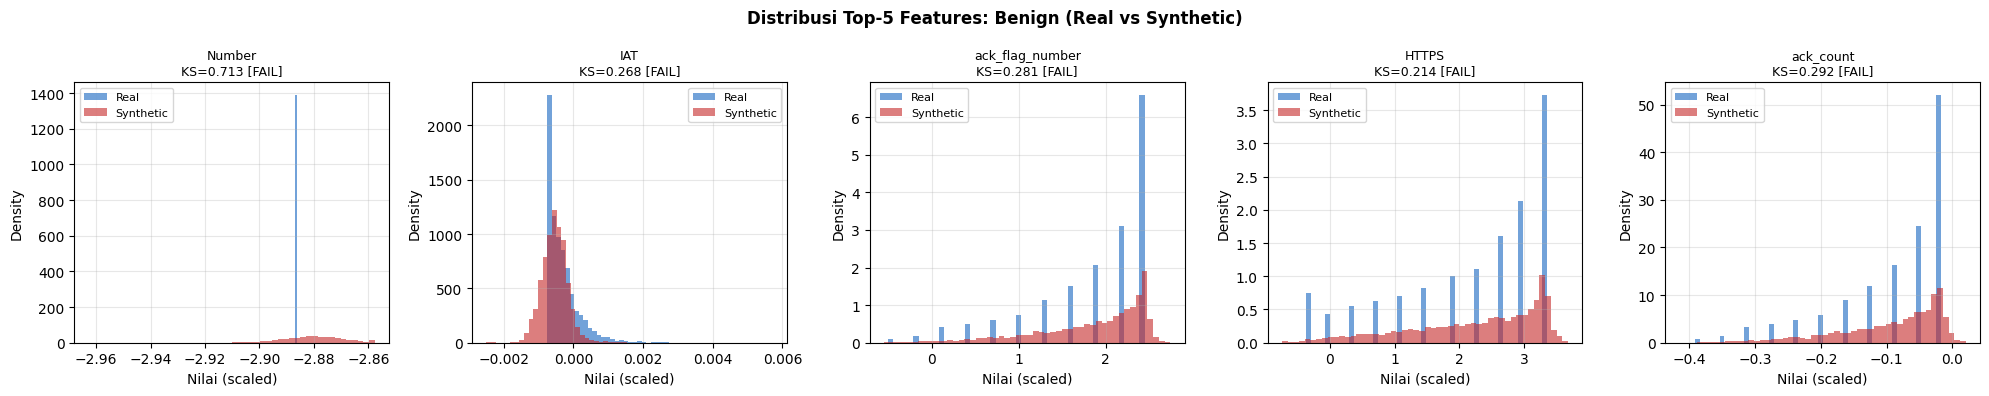

  Figure distribusi fitur [Benign] tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Results/Visualizations/Langkah6_CVAE_DistribusiFitur_Benign.png


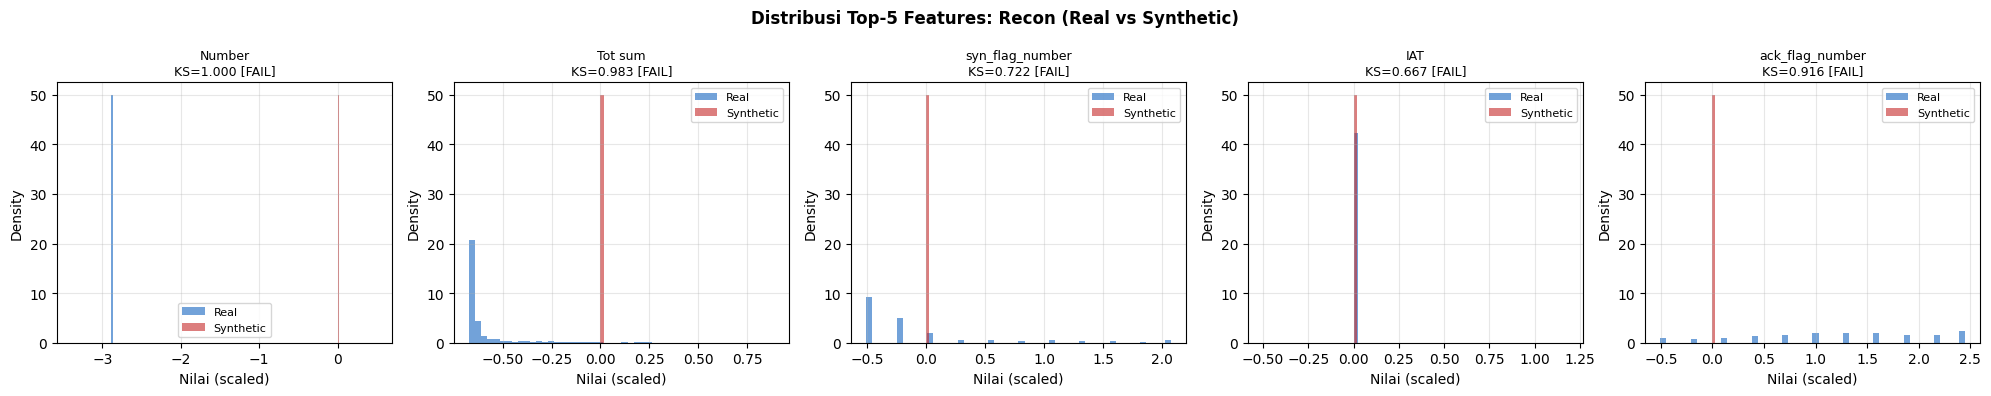

  Figure distribusi fitur [Recon] tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Results/Visualizations/Langkah6_CVAE_DistribusiFitur_Recon.png


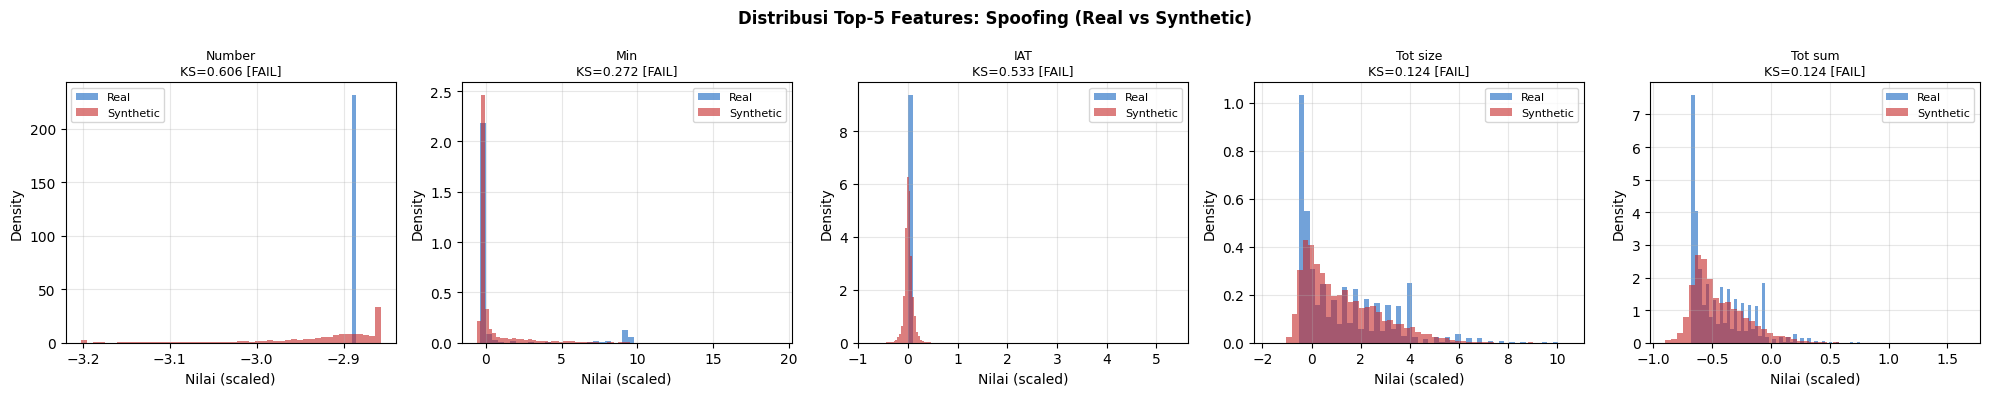

  Figure distribusi fitur [Spoofing] tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Results/Visualizations/Langkah6_CVAE_DistribusiFitur_Spoofing.png


In [ ]:
# Visualisasi 6.4c: Distribusi fitur top-5 real vs synthetic

print("Membuat visualisasi distribusi fitur per kategori...")

for cat in cats_with_synth:
    top5_idx  = moderate_data[cat]['top_k_indices'][:5]
    top5_names = [feature_names[i] for i in top5_idx]

    X_real  = moderate_data[cat]['X']
    X_synth = synthetic_data[cat]['X_synthetic']

    # Subsample untuk plot
    n_plot = min(5000, len(X_real), len(X_synth))
    idx_r  = rng_val.choice(len(X_real),  size=n_plot, replace=False)
    idx_s  = rng_val.choice(len(X_synth), size=n_plot, replace=False)

    fig_feat, axes_feat = plt.subplots(1, 5, figsize=(20, 4))
    fig_feat.suptitle(f'Distribusi Top-5 Features: {cat} (Real vs Synthetic)',
                       fontsize=12, fontweight='bold')

    for ax_f, feat_i, fname in zip(axes_feat, top5_idx, top5_names):
        ax_f.hist(X_real[idx_r, feat_i],  bins=50, alpha=0.6,
                  color='#1565C0', label='Real',      density=True)
        ax_f.hist(X_synth[idx_s, feat_i], bins=50, alpha=0.6,
                  color='#C62828', label='Synthetic', density=True)

        ks_info = ks_results_all[cat]['details'].get(fname, {})
        stat    = ks_info.get('statistic', 0)
        passed  = ks_info.get('passed', False)
        status  = "PASS" if passed else "FAIL"

        ax_f.set_title(f'{fname}\nKS={stat:.3f} [{status}]', fontsize=9)
        ax_f.set_xlabel('Nilai (scaled)')
        ax_f.set_ylabel('Density')
        ax_f.legend(fontsize=8)
        ax_f.grid(alpha=0.3)

    plt.tight_layout()
    path_feat = os.path.join(VISUALIZATION_DIR,
                             f'Langkah6_CVAE_DistribusiFitur_{cat}.png')
    plt.savefig(path_feat, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Figure distribusi fitur [{cat}] tersimpan: {path_feat}")

    del X_real, X_synth
    gc.collect()

####**6.6 Simpan Model dan Augmented Data**

In [ ]:
print("6.6 Menyimpan model dan augmented data moderate")

# --- Gabungkan real + synthetic per kategori -> augmented moderate ---
X_moderate_aug_parts = []
y_moderate_aug_parts = []

print("Menggabungkan real + synthetic per kategori:")
for cat in moderate_cats:
    enc   = moderate_data[cat]['enc']
    X_r   = moderate_data[cat]['X']
    y_r   = moderate_data[cat]['y']
    X_s   = synthetic_data[cat]['X_synthetic']
    y_s   = synthetic_data[cat]['y_synthetic']

    n_r = len(X_r)
    n_s = len(X_s)
    n_t = n_r + n_s

    X_moderate_aug_parts.append(X_r)
    y_moderate_aug_parts.append(y_r)

    if n_s > 0:
        X_moderate_aug_parts.append(X_s)
        y_moderate_aug_parts.append(y_s)

    print(f"  [{cat}]: {n_r:,} real + {n_s:,} synthetic = {n_t:,} total")

# Stack semua
X_moderate_augmented = np.vstack(X_moderate_aug_parts).astype(np.float32)
y_moderate_augmented = np.concatenate(y_moderate_aug_parts).astype(np.int64)

# Shuffle
shuffle_idx = np.random.default_rng(RANDOM_STATE).permutation(len(X_moderate_augmented))
X_moderate_augmented = X_moderate_augmented[shuffle_idx]
y_moderate_augmented = y_moderate_augmented[shuffle_idx]

del X_moderate_aug_parts, y_moderate_aug_parts, shuffle_idx
gc.collect()

print(f"\nHasil augmented moderate:")
print(f"  X_moderate_augmented : {X_moderate_augmented.shape}")
print(f"  y_moderate_augmented : {y_moderate_augmented.shape}")
print(f"  Distribusi akhir:")
for cat in moderate_cats:
    enc = moderate_data[cat]['enc']
    cnt = int(np.sum(y_moderate_augmented == enc))
    print(f"    {cat}: {cnt:,}")

# Simpan augmented moderate dataset
path_X_aug = os.path.join(CVAE_DIR, 'X_moderate_augmented.npy')
path_y_aug = os.path.join(CVAE_DIR, 'y_moderate_augmented.npy')
np.save(path_X_aug, X_moderate_augmented)
np.save(path_y_aug, y_moderate_augmented)

size_X = os.path.getsize(path_X_aug) / 1024**2
size_y = os.path.getsize(path_y_aug) / 1024**2
print(f"\n  Tersimpan:")
print(f"    {path_X_aug} ({size_X:.1f} MB)")
print(f"    {path_y_aug} ({size_y:.1f} MB)")

# Validasi load ulang
X_check = np.load(path_X_aug)
y_check = np.load(path_y_aug)
assert X_check.shape == X_moderate_augmented.shape, "ERROR: shape X tidak cocok!"
assert y_check.shape == y_moderate_augmented.shape, "ERROR: shape y tidak cocok!"
print(f"  Validasi load ulang: OK - shape {X_check.shape}")
del X_check, y_check
gc.collect()

# Simpan metadata CVAE
cvae_metadata = {
    'architecture': {
        'input_dim'  : INPUT_DIM,
        'latent_dim' : LATENT_DIM,
        'encoder'    : f'{INPUT_DIM}->128->64->Latent({LATENT_DIM})',
        'decoder'    : f'Latent({LATENT_DIM})->64->128->{INPUT_DIM}',
        'beta'       : BETA,
    },
    'training': {
        'batch_size' : BATCH_SIZE,
        'epochs_max' : EPOCHS,
        'patience'   : PATIENCE,
        'lr'         : LR,
        'optimizer'  : 'Adam',
    },
    'augmentation': {
        'target_per_class'   : TARGET_PER_CLASS,
        'moderate_cats'      : moderate_cats,
        'feature_masking'    : True,
        'top_k'              : TOP_K,
    },
    'results': {
        cat: {
            'n_real'            : int(moderate_data[cat]['n_real']),
            'n_synthetic'       : int(synthetic_data[cat]['n_synthetic']),
            'n_total'           : int(moderate_data[cat]['n_real'] +
                                      synthetic_data[cat]['n_synthetic']),
            'n_epochs_trained'  : training_history.get(cat, {}).get('n_epochs', 0),
            'ks_pass_rate'      : ks_results_all.get(cat, {}).get('pass_rate', 'N/A'),
        }
        for cat in moderate_cats
    },
    'output': {
        'X_moderate_augmented' : path_X_aug,
        'y_moderate_augmented' : path_y_aug,
        'total_moderate_aug'   : int(len(X_moderate_augmented)),
    }
}

meta_path = os.path.join(CVAE_DIR, 'cvae_metadata.json')
with open(meta_path, 'w') as f:
    json.dump(cvae_metadata, f, indent=4)
print(f"\n  Metadata tersimpan: {meta_path}")

6.6 Menyimpan model dan augmented data moderate
Menggabungkan real + synthetic per kategori:
  [Benign]: 875,041 real + 124,959 synthetic = 1,000,000 total
  [Recon]: 547,578 real + 452,422 synthetic = 1,000,000 total
  [Spoofing]: 363,923 real + 636,077 synthetic = 1,000,000 total

Hasil augmented moderate:
  X_moderate_augmented : (3000000, 39)
  y_moderate_augmented : (3000000,)
  Distribusi akhir:
    Benign: 1,000,000
    Recon: 1,000,000
    Spoofing: 1,000,000

  Tersimpan:
    /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/04_CVAE/X_moderate_augmented.npy (446.3 MB)
    /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/04_CVAE/y_moderate_augmented.npy (22.9 MB)
  Validasi load ulang: OK - shape (3000000, 39)

  Metadata tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/04_CVAE/cvae_metadata.json


####**6.7 Ringkasan Langkah 6**

In [ ]:
print("Ringkasan Langkah 6 - CVAE Training (Moderate Classes)")
print("=" * 60)

print(f"\nArsitektur : {INPUT_DIM}->128->64->z({LATENT_DIM})->64->128->{INPUT_DIM}")
print(f"Loss       : {BETA}*weighted_recon + {round(1-BETA,2)}*KL")

print(f"\nHasil augmentasi per kategori:")
print(f"  {'Kategori':<12} {'Real':>9} {'Synthetic':>10} {'Total':>9} {'KS Pass':>9} {'Epochs':>7}")
print(f"  {'-'*60}")
for cat in moderate_cats:
    n_r    = moderate_data[cat]['n_real']
    n_s    = synthetic_data[cat]['n_synthetic']
    n_t    = n_r + n_s
    ks_r   = ks_results_all.get(cat, {}).get('pass_rate', 'N/A')
    ep     = training_history.get(cat, {}).get('n_epochs', '-')
    print(f"  {cat:<12} {n_r:>9,} {n_s:>10,} {n_t:>9,} {str(ks_r)+' %':>9} {ep:>7}")

print(f"\n  Total moderate augmented : {len(X_moderate_augmented):,}")

print(f"\nFile tersimpan di: {CVAE_DIR}")
for fname in ['X_moderate_augmented.npy', 'y_moderate_augmented.npy',
              'cvae_metadata.json', 'cvae_ks_test_results.json']:
    print(f"  {fname}")
for cat in moderate_cats:
    print(f"  cvae_weights_{cat}.weights.h5")
    print(f"  cvae_history_{cat}.json")
    print(f"  X_synthetic_{cat}.npy, y_synthetic_{cat}.npy")

print(f"\nVisualisasi tersimpan di: {VISUALIZATION_DIR}")
for vname in ['Langkah6_CVAE_Training_Loss.png',
              'Langkah6_CVAE_tSNE_Real_vs_Synthetic.png']:
    print(f"  {vname}")
for cat in cats_with_synth:
    print(f"  Langkah6_CVAE_DistribusiFitur_{cat}.png")

mem = psutil.virtual_memory()
print(f"\nRAM tersisa: {mem.available / 1024**3:.2f} GB")

# Bersihkan model dari memory (tidak dibutuhkan lagi)
del cvae_models
tf.keras.backend.clear_session()
gc.collect()

print("Model CVAE dihapus dari RAM. gc.collect() selesai.")
print("\nLangkah 6 selesai. Siap lanjut ke Langkah 7 (Borderline-SMOTE).")
print("=" * 60)

Ringkasan Langkah 6 - CVAE Training (Moderate Classes)

Arsitektur : 39->128->64->z(128)->64->128->39
Loss       : 0.75*weighted_recon + 0.25*KL

Hasil augmentasi per kategori:
  Kategori          Real  Synthetic     Total   KS Pass  Epochs
  ------------------------------------------------------------
  Benign         875,041    124,959 1,000,000    3.33 %      50
  Recon          547,578    452,422 1,000,000     0.0 %      11
  Spoofing       363,923    636,077 1,000,000    6.67 %      50

  Total moderate augmented : 3,000,000

File tersimpan di: /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/04_CVAE/
  X_moderate_augmented.npy
  y_moderate_augmented.npy
  cvae_metadata.json
  cvae_ks_test_results.json
  cvae_weights_Benign.weights.h5
  cvae_history_Benign.json
  X_synthetic_Benign.npy, y_synthetic_Benign.npy
  cvae_weights_Recon.weights.h5
  cvae_history_Recon.json
  X_synthetic_Recon.npy, y_synthetic_Recon.npy
  cvae_weights_Spoofing.weights.h5
  cvae_history_Spoofing.js

## **Langkah 7: Borderline-SMOTE (untuk Critical classes)**

####**7.1 Setup Konfigurasi dan Validasi Variabel**

In [ ]:
print("Setup konfigurasi")
print("-" * 40)

# Target augmentasi per kelas (proporsional dengan moderate = 1,000,000)
TARGET_PER_CLASS = 1_000_000

# Jumlah reference samples dari moderate sebagai "majority" context
# agar Borderline-SMOTE bisa mendeteksi batas keputusan
N_REF_MAJORITY = 30_000

# Konfigurasi Borderline-SMOTE
SMOTE_K_NEIGHBORS = 5
SMOTE_KIND       = 'borderline-1'
SMOTE_RANDOM_STATE = 42

print(f"Target per kelas       : {TARGET_PER_CLASS:,}")
print(f"Reference majority     : {N_REF_MAJORITY:,} samples")
print(f"k_neighbors            : {SMOTE_K_NEIGHBORS}")
print(f"kind                   : {SMOTE_KIND}")
print(f"random_state           : {SMOTE_RANDOM_STATE}")

# Validasi variabel penting sudah ada di memory
print("\nValidasi variabel di memory...")

assert 'X_critical' in dir() or 'X_critical' in globals(), \
    "X_critical tidak ditemukan di memory. Load dari disk terlebih dahulu."
assert 'y_critical' in dir() or 'y_critical' in globals(), \
    "y_critical tidak ditemukan di memory."
assert 'cafw_results' in dir() or 'cafw_results' in globals(), \
    "cafw_results tidak ditemukan di memory. Jalankan Langkah 5 terlebih dahulu."
assert 'X_moderate_augmented' in dir() or 'X_moderate_augmented' in globals(), \
    "X_moderate_augmented tidak ditemukan. Jalankan Langkah 6 terlebih dahulu."

print(f"X_critical shape       : {X_critical.shape}")
print(f"y_critical shape       : {y_critical.shape}")
print(f"X_moderate_augmented   : {X_moderate_augmented.shape}")
print(f"cafw_results keys      : {list(cafw_results.keys())}")

# Validasi distribusi critical classes
print("\nDistribusi critical classes saat ini:")
for cat_name in critical_cats:
    enc = NAME_TO_ENC[cat_name]
    n = int((y_critical == enc).sum())
    print(f"  {cat_name} (enc={enc}): {n:,} samples")
    n_synthetic_needed = TARGET_PER_CLASS - n
    ratio = TARGET_PER_CLASS / n
    print(f"    -> synthetic dibutuhkan : {n_synthetic_needed:,}")
    print(f"    -> augmentation ratio   : {ratio:.1f}x")

print("\nSetup selesai.")

Setup konfigurasi
----------------------------------------
Target per kelas       : 1,000,000
Reference majority     : 30,000 samples
k_neighbors            : 5
kind                   : borderline-1
random_state           : 42

Validasi variabel di memory...
X_critical shape       : (30236, 39)
y_critical shape       : (30236,)
X_moderate_augmented   : (3000000, 39)
cafw_results keys      : ['Benign', 'Recon', 'Spoofing', 'Web_Based', 'Brute_Force']

Distribusi critical classes saat ini:
  Web_Based (enc=7): 19,786 samples
    -> synthetic dibutuhkan : 980,214
    -> augmentation ratio   : 50.5x
  Brute_Force (enc=1): 10,450 samples
    -> synthetic dibutuhkan : 989,550
    -> augmentation ratio   : 95.7x

Setup selesai.


####**7.2 Load CAFW Results untuk Critical Classes**

In [ ]:
print("Load CAFW results untuk critical classes")
print("-" * 40)

# Validasi CAFW results untuk setiap critical class
cafw_critical = {}
for cat_name in critical_cats:
    assert cat_name in cafw_results, \
        f"CAFW results untuk '{cat_name}' tidak ditemukan."

    result = cafw_results[cat_name]
    top_idx   = result['top_30_indices']
    top_names = result['top_30_names']
    top_scores = result['top_30_scores']

    assert len(top_idx) == 30, \
        f"Jumlah top features untuk '{cat_name}' bukan 30: {len(top_idx)}"

    cafw_critical[cat_name] = {
        'top_30_indices': top_idx,
        'top_30_names'  : top_names,
        'top_30_scores' : top_scores,
        'enc'           : NAME_TO_ENC[cat_name]
    }

    print(f"\n{cat_name} (enc={NAME_TO_ENC[cat_name]}):")
    print(f"  Top-5 features  : {top_names[:5]}")
    print(f"  Top-5 EFI scores: {[round(s, 4) for s in top_scores[:5]]}")
    print(f"  Total features  : {len(top_idx)}")

print("\nCAFW results untuk critical classes berhasil diload.")

Load CAFW results untuk critical classes
----------------------------------------

Web_Based (enc=7):
  Top-5 features  : ['IAT', 'Number', 'Tot sum', 'Rate', 'ack_flag_number']
  Top-5 EFI scores: [1.0, 0.9468, 0.4372, 0.3763, 0.3568]
  Total features  : 30

Brute_Force (enc=1):
  Top-5 features  : ['Number', 'IAT', 'Rate', 'Tot sum', 'rst_flag_number']
  Top-5 EFI scores: [1.0, 0.624, 0.6037, 0.5264, 0.4834]
  Total features  : 30

CAFW results untuk critical classes berhasil diload.


####**7.3 Menyiapkan Reference Majority Samples**


In [ ]:
print("Menyiapkan reference majority samples")
print("-" * 40)

# Ambil N_REF_MAJORITY samples dari X_moderate_augmented sebagai context
# "majority" untuk Borderline-SMOTE agar batas keputusan bisa terdeteksi
# Pilih secara acak untuk representasi yang beragam
np.random.seed(SMOTE_RANDOM_STATE)
ref_idx = np.random.choice(
    len(X_moderate_augmented),
    size=N_REF_MAJORITY,
    replace=False
)
X_ref_majority = X_moderate_augmented[ref_idx].copy()
print(f"Reference majority shape : {X_ref_majority.shape}")
print(f"  Diambil dari          : X_moderate_augmented")
print(f"  Jumlah                : {N_REF_MAJORITY:,} samples")

# Label untuk reference majority (label=0 dalam binary setup)
y_ref_majority = np.zeros(N_REF_MAJORITY, dtype=np.int32)

print("Reference majority samples siap.")

Menyiapkan reference majority samples
----------------------------------------
Reference majority shape : (30000, 39)
  Diambil dari          : X_moderate_augmented
  Jumlah                : 30,000 samples
Reference majority samples siap.


####**7.4 Apply Borderline-SMOTE per Critical Class**

In [ ]:
print("Apply Borderline-SMOTE per critical class")
print("=" * 60)

# Dictionary untuk menyimpan hasil augmentasi per kelas
smote_results = {}

for cat_name in critical_cats:
    enc = cafw_critical[cat_name]['enc']
    top_idx = cafw_critical[cat_name]['top_30_indices']

    print(f"\n--- Proses: {cat_name} (enc={enc}) ---")
    t_start = time.time()

    # 1. Ekstrak samples untuk kelas ini dari X_critical
    mask_cat = (y_critical == enc)
    X_cat_full = X_critical[mask_cat].copy()   # shape: (n_original, 39)
    n_original = len(X_cat_full)
    n_synthetic_needed = TARGET_PER_CLASS - n_original

    print(f"  Original samples         : {n_original:,}")
    print(f"  Target total             : {TARGET_PER_CLASS:,}")
    print(f"  Synthetic dibutuhkan     : {n_synthetic_needed:,}")

    # 2. Ekstrak top-30 features (CAFW-aware)
    X_cat_30  = X_cat_full[:, top_idx]          # (n_original, 30)
    X_ref_30  = X_ref_majority[:, top_idx]       # (N_REF, 30)

    print(f"  Top-30 feature shape     : {X_cat_30.shape}")
    print(f"  Reference majority shape : {X_ref_30.shape}")

    # 3. Bangun binary dataset untuk Borderline-SMOTE

    #   label 1 = minority (critical class yang akan diaugmentasi)
    #   label 0 = majority (reference moderate samples)
    X_binary = np.vstack([X_cat_30, X_ref_30])   # (n_original + N_REF, 30)
    y_binary = np.concatenate([
        np.ones(n_original, dtype=np.int32),      # critical class = 1
        np.zeros(N_REF_MAJORITY, dtype=np.int32)  # reference = 0
    ])

    print(f"  Binary dataset shape     : {X_binary.shape}")
    print(f"  Binary label counts      : {Counter(y_binary.tolist())}")

    # 4. Apply Borderline-SMOTE
    print(f"  Menjalankan Borderline-SMOTE...")

    smote = BorderlineSMOTE(
        k_neighbors=SMOTE_K_NEIGHBORS,
        sampling_strategy={1: TARGET_PER_CLASS},
        kind=SMOTE_KIND,
        random_state=SMOTE_RANDOM_STATE
    )

    X_resampled_30, y_resampled = smote.fit_resample(X_binary, y_binary)

    # Hitung jumlah synthetic samples yang dihasilkan
    n_total_minority = int((y_resampled == 1).sum())
    n_synthetic_generated = n_total_minority - n_original

    print(f"  Total minority setelah SMOTE : {n_total_minority:,}")
    print(f"  Synthetic generated          : {n_synthetic_generated:,}")

    # 5. Ekstrak hanya synthetic samples (bukan original)
    X_minority_30 = X_resampled_30[y_resampled == 1]  # semua minority
    X_synthetic_30 = X_minority_30[n_original:]        # hanya yang baru

    assert len(X_synthetic_30) == n_synthetic_needed, \
        f"Jumlah synthetic tidak sesuai: {len(X_synthetic_30)} vs {n_synthetic_needed}"

    print(f"  X_synthetic_30 shape     : {X_synthetic_30.shape}")

    # 6. Rekonstruksi ke 39 features (zero-pad non-selected)
    # Pendekatan: synthetic samples hanya diisi pada top-30 indices
    # Non-selected features diset 0 (sesuai FIGS framework)
    X_synthetic_full = np.zeros(
        (len(X_synthetic_30), X_critical.shape[1]),
        dtype=np.float32
    )
    X_synthetic_full[:, top_idx] = X_synthetic_30.astype(np.float32)

    print(f"  X_synthetic_full shape   : {X_synthetic_full.shape}")


    # 7. Gabungkan original + synthetic untuk kelas ini
    X_cat_augmented = np.vstack([
        X_cat_full.astype(np.float32),
        X_synthetic_full
    ])
    y_cat_augmented = np.full(
        len(X_cat_augmented),
        enc,
        dtype=np.int32
    )

    assert len(X_cat_augmented) == TARGET_PER_CLASS, \
        f"Total augmented tidak sesuai: {len(X_cat_augmented)} vs {TARGET_PER_CLASS}"

    t_elapsed = time.time() - t_start
    print(f"  X_cat_augmented shape    : {X_cat_augmented.shape}")
    print(f"  y_cat_augmented shape    : {y_cat_augmented.shape}")
    print(f"  Waktu proses             : {t_elapsed:.2f} detik")

    # Simpan hasil per kelas
    smote_results[cat_name] = {
        'X_augmented': X_cat_augmented,
        'y_augmented': y_cat_augmented,
        'n_original' : n_original,
        'n_synthetic': n_synthetic_generated,
        'n_total'    : len(X_cat_augmented),
        'top_indices': top_idx,
        'enc'        : enc
    }

    # Cleanup intermediate arrays
    del X_cat_30, X_ref_30, X_binary, y_binary
    del X_resampled_30, y_resampled, X_minority_30
    del X_synthetic_30, X_synthetic_full
    gc.collect()

    print(f"  Proses {cat_name} selesai.")

print("semua critical classes telah diproses.")

Apply Borderline-SMOTE per critical class

--- Proses: Web_Based (enc=7) ---
  Original samples         : 19,786
  Target total             : 1,000,000
  Synthetic dibutuhkan     : 980,214
  Top-30 feature shape     : (19786, 30)
  Reference majority shape : (30000, 30)
  Binary dataset shape     : (49786, 30)
  Binary label counts      : Counter({0: 30000, 1: 19786})
  Menjalankan Borderline-SMOTE...
  Total minority setelah SMOTE : 1,000,000
  Synthetic generated          : 980,214
  X_synthetic_30 shape     : (980214, 30)
  X_synthetic_full shape   : (980214, 39)
  X_cat_augmented shape    : (1000000, 39)
  y_cat_augmented shape    : (1000000,)
  Waktu proses             : 4.07 detik
  Proses Web_Based selesai.

--- Proses: Brute_Force (enc=1) ---
  Original samples         : 10,450
  Target total             : 1,000,000
  Synthetic dibutuhkan     : 989,550
  Top-30 feature shape     : (10450, 30)
  Reference majority shape : (30000, 30)
  Binary dataset shape     : (40450, 30)
  Bi

####**7.5 Validasi Synthetic Samples**

In [ ]:
print("Validasi synthetic samples")

all_valid = True

for cat_name in critical_cats:
    enc  = smote_results[cat_name]['enc']
    X_aug = smote_results[cat_name]['X_augmented']
    y_aug = smote_results[cat_name]['y_augmented']
    n_orig = smote_results[cat_name]['n_original']
    n_syn  = smote_results[cat_name]['n_synthetic']
    n_tot  = smote_results[cat_name]['n_total']
    top_idx = smote_results[cat_name]['top_indices']

    print(f"\n{cat_name} (enc={enc}):")
    print(f"  Original  : {n_orig:,}")
    print(f"  Synthetic : {n_syn:,}")
    print(f"  Total     : {n_tot:,} (target: {TARGET_PER_CLASS:,})")

    # Cek total sesuai target
    ok_total = (n_tot == TARGET_PER_CLASS)
    print(f"  Total sesuai target  : {'OK' if ok_total else 'GAGAL'}")
    if not ok_total:
        all_valid = False

    # Cek tidak ada NaN
    has_nan = np.isnan(X_aug).any()
    print(f"  Tidak ada NaN        : {'OK' if not has_nan else 'GAGAL'}")
    if has_nan:
        all_valid = False

    # Cek tidak ada Inf
    has_inf = np.isinf(X_aug).any()
    print(f"  Tidak ada Inf        : {'OK' if not has_inf else 'GAGAL'}")
    if has_inf:
        all_valid = False

    # Cek label konsisten
    label_ok = (y_aug == enc).all()
    print(f"  Label konsisten      : {'OK' if label_ok else 'GAGAL'}")
    if not label_ok:
        all_valid = False

    # Cek shape
    shape_ok = (X_aug.shape == (TARGET_PER_CLASS, X_critical.shape[1]))
    print(f"  Shape sesuai         : {'OK' if shape_ok else 'GAGAL'}")
    if not shape_ok:
        all_valid = False

    # Statistik synthetic samples (bagian kedua = synthetic)
    X_synthetic_part = X_aug[n_orig:]
    X_original_part  = X_aug[:n_orig]

    print(f"\n  Statistik fitur (top-30 dari synthetic):")
    X_syn_30 = X_synthetic_part[:, top_idx]
    X_ori_30 = X_original_part[:, top_idx]

    print(f"    Mean original  : {X_ori_30.mean():.6f}")
    print(f"    Mean synthetic : {X_syn_30.mean():.6f}")
    print(f"    Std  original  : {X_ori_30.std():.6f}")
    print(f"    Std  synthetic : {X_syn_30.std():.6f}")

    # Cek non-selected features di synthetic = 0
    non_selected = [i for i in range(X_aug.shape[1]) if i not in top_idx]
    if len(non_selected) > 0:
        X_non_sel_syn = X_synthetic_part[:, non_selected]
        non_sel_nonzero = (X_non_sel_syn != 0).sum()
        print(f"  Non-selected features (synthetic) = 0 : "
              f"{'OK' if non_sel_nonzero == 0 else f'GAGAL ({non_sel_nonzero} non-zero)'}")

print(f"\nStatus validasi keseluruhan : {'LULUS' if all_valid else 'ADA MASALAH'}")

Validasi synthetic samples

Web_Based (enc=7):
  Original  : 19,786
  Synthetic : 980,214
  Total     : 1,000,000 (target: 1,000,000)
  Total sesuai target  : OK
  Tidak ada NaN        : OK
  Tidak ada Inf        : OK
  Label konsisten      : OK
  Shape sesuai         : OK

  Statistik fitur (top-30 dari synthetic):
    Mean original  : 0.087572
    Mean synthetic : 0.130424
    Std  original  : 1.825476
    Std  synthetic : 1.665681
  Non-selected features (synthetic) = 0 : OK

Brute_Force (enc=1):
  Original  : 10,450
  Synthetic : 989,550
  Total     : 1,000,000 (target: 1,000,000)
  Total sesuai target  : OK
  Tidak ada NaN        : OK
  Tidak ada Inf        : OK
  Label konsisten      : OK
  Shape sesuai         : OK

  Statistik fitur (top-30 dari synthetic):
    Mean original  : 0.564556
    Mean synthetic : 0.112977
    Std  original  : 6.126956
    Std  synthetic : 2.512406
  Non-selected features (synthetic) = 0 : OK

Status validasi keseluruhan : LULUS


####**7.6 Gabungkan Hasil Augmentasi Semua Critical Classes**

In [ ]:
print("Menggabungkan augmented critical classes")

# Stack semua kelas critical yang sudah diaugmentasi
X_critical_augmented = np.vstack([
    smote_results[cat]['X_augmented'] for cat in critical_cats
])
y_critical_augmented = np.concatenate([
    smote_results[cat]['y_augmented'] for cat in critical_cats
])

print(f"X_critical_augmented shape : {X_critical_augmented.shape}")
print(f"y_critical_augmented shape : {y_critical_augmented.shape}")

print("\nDistribusi kelas setelah augmentasi:")
for cat_name in critical_cats:
    enc = NAME_TO_ENC[cat_name]
    n_aug  = int((y_critical_augmented == enc).sum())
    n_orig = smote_results[cat_name]['n_original']
    n_syn  = smote_results[cat_name]['n_synthetic']
    print(f"  {cat_name} (enc={enc}):")
    print(f"    Original  : {n_orig:,}")
    print(f"    Synthetic : {n_syn:,}")
    print(f"    Total     : {n_aug:,}")

# Ringkasan perbandingan sebelum dan sesudah
print("\nRingkasan augmentasi critical classes:")
print(f"  Sebelum : Web_Based={smote_results['Web_Based']['n_original']:,}, "
      f"Brute_Force={smote_results['Brute_Force']['n_original']:,}")
print(f"  Sesudah : Web_Based={smote_results['Web_Based']['n_total']:,}, "
      f"Brute_Force={smote_results['Brute_Force']['n_total']:,}")
print(f"  Total X_critical_augmented : {len(X_critical_augmented):,}")

Menggabungkan augmented critical classes
X_critical_augmented shape : (2000000, 39)
y_critical_augmented shape : (2000000,)

Distribusi kelas setelah augmentasi:
  Web_Based (enc=7):
    Original  : 19,786
    Synthetic : 980,214
    Total     : 1,000,000
  Brute_Force (enc=1):
    Original  : 10,450
    Synthetic : 989,550
    Total     : 1,000,000

Ringkasan augmentasi critical classes:
  Sebelum : Web_Based=19,786, Brute_Force=10,450
  Sesudah : Web_Based=1,000,000, Brute_Force=1,000,000
  Total X_critical_augmented : 2,000,000


####**7.7 Save Augmented Critical Data**

In [ ]:
print("Save augmented critical data")

os.makedirs(SMOTE_DIR, exist_ok=True)

# Simpan data gabungan
path_X = os.path.join(SMOTE_DIR, 'X_critical_augmented.npy')
path_y = os.path.join(SMOTE_DIR, 'y_critical_augmented.npy')

print(f"Menyimpan X_critical_augmented ke: {path_X}")
np.save(path_X, X_critical_augmented)
print(f"  Ukuran file: {os.path.getsize(path_X) / 1024**2:.2f} MB")

print(f"Menyimpan y_critical_augmented ke: {path_y}")
np.save(path_y, y_critical_augmented)
print(f"  Ukuran file: {os.path.getsize(path_y) / 1024**2:.2f} MB")

# Simpan per kelas (checkpoint individual)
for cat_name in critical_cats:
    enc = smote_results[cat_name]['enc']
    path_cat_X = os.path.join(SMOTE_DIR, f'X_{cat_name.lower()}_augmented.npy')
    path_cat_y = os.path.join(SMOTE_DIR, f'y_{cat_name.lower()}_augmented.npy')
    np.save(path_cat_X, smote_results[cat_name]['X_augmented'])
    np.save(path_cat_y, smote_results[cat_name]['y_augmented'])
    print(f"Checkpoint {cat_name} tersimpan: {path_cat_X}")

# Simpan metadata
smote_meta = {
    'method'             : 'Borderline-SMOTE',
    'kind'               : SMOTE_KIND,
    'k_neighbors'        : SMOTE_K_NEIGHBORS,
    'random_state'       : SMOTE_RANDOM_STATE,
    'target_per_class'   : TARGET_PER_CLASS,
    'n_ref_majority'     : N_REF_MAJORITY,
    'ref_source'         : 'X_moderate_augmented',
    'feature_strategy'   : 'CAFW top-30 per kategori, non-selected = 0',
    'classes': {
        cat: {
            'enc'        : int(smote_results[cat]['enc']),
            'n_original' : int(smote_results[cat]['n_original']),
            'n_synthetic': int(smote_results[cat]['n_synthetic']),
            'n_total'    : int(smote_results[cat]['n_total']),
            'top_30_indices': [int(i) for i in smote_results[cat]['top_indices']]
        }
        for cat in critical_cats
    },
    'output': {
        'X_shape': list(X_critical_augmented.shape),
        'y_shape': list(y_critical_augmented.shape)
    }
}

path_meta = os.path.join(SMOTE_DIR, 'smote_metadata.json')
with open(path_meta, 'w') as f:
    json.dump(smote_meta, f, indent=4)
print(f"Metadata tersimpan: {path_meta}")

Save augmented critical data
Menyimpan X_critical_augmented ke: /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/05_SMOTE/X_critical_augmented.npy
  Ukuran file: 297.55 MB
Menyimpan y_critical_augmented ke: /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/05_SMOTE/y_critical_augmented.npy
  Ukuran file: 7.63 MB
Checkpoint Web_Based tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/05_SMOTE/X_web_based_augmented.npy
Checkpoint Brute_Force tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/05_SMOTE/X_brute_force_augmented.npy
Metadata tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/05_SMOTE/smote_metadata.json


####**7.8 Ringkasan**

In [ ]:
print("LANGKAH 7 SELESAI - Ringkasan")

print(f"\nMetode               : Borderline-SMOTE ({SMOTE_KIND})")
print(f"k_neighbors          : {SMOTE_K_NEIGHBORS}")
print(f"Feature strategy     : CAFW top-30 per kategori")

print("\nHasil augmentasi:")
for cat_name in critical_cats:
    enc   = smote_results[cat_name]['enc']
    n_ori = smote_results[cat_name]['n_original']
    n_syn = smote_results[cat_name]['n_synthetic']
    n_tot = smote_results[cat_name]['n_total']
    print(f"  {cat_name} (enc={enc}): "
          f"{n_ori:,} real + {n_syn:,} synthetic = {n_tot:,} total")

print(f"\nX_critical_augmented : {X_critical_augmented.shape}")
print(f"y_critical_augmented : {y_critical_augmented.shape}")

print("\nStatus variabel untuk Langkah 8:")
print(f"  X_critical_augmented tersedia di memory : Ya")
print(f"  y_critical_augmented tersedia di memory : Ya")
print(f"  X_moderate_augmented tersedia di memory : Ya")
print(f"  y_moderate_augmented tersedia di memory : Ya")
print(f"  X_dominant tersedia di memory           : Ya")
print(f"  y_dominant tersedia di memory           : Ya")

print("\nFile tersimpan di SMOTE_DIR:")
for f in os.listdir(SMOTE_DIR):
    fpath = os.path.join(SMOTE_DIR, f)
    size_mb = os.path.getsize(fpath) / 1024**2
    print(f"  {f:45s} ({size_mb:.2f} MB)")

print("\nLangkah 8 berikutnya: Dataset Integration")
print("Combine Dominant + Moderate_augmented + Critical_augmented")

LANGKAH 7 SELESAI - Ringkasan

Metode               : Borderline-SMOTE (borderline-1)
k_neighbors          : 5
Feature strategy     : CAFW top-30 per kategori

Hasil augmentasi:
  Web_Based (enc=7): 19,786 real + 980,214 synthetic = 1,000,000 total
  Brute_Force (enc=1): 10,450 real + 989,550 synthetic = 1,000,000 total

X_critical_augmented : (2000000, 39)
y_critical_augmented : (2000000,)

Status variabel untuk Langkah 8:
  X_critical_augmented tersedia di memory : Ya
  y_critical_augmented tersedia di memory : Ya
  X_moderate_augmented tersedia di memory : Ya
  y_moderate_augmented tersedia di memory : Ya
  X_dominant tersedia di memory           : Ya
  y_dominant tersedia di memory           : Ya

File tersimpan di SMOTE_DIR:
  X_critical_augmented.npy                      (297.55 MB)
  X_web_based_augmented.npy                     (148.77 MB)
  X_brute_force_augmented.npy                   (148.77 MB)
  y_critical_augmented.npy                      (7.63 MB)
  y_web_based_augmente

##**Langkah 8:Dataset Integration**

####**8.1 Validasi Semua Komponen Tersedia**

In [ ]:
print("8.1 Validasi komponen dataset")
print("-" * 40)

# Cek di memory terlebih dahulu, jika tidak ada load dari disk
def load_if_needed(var_name, path, dtype=None):
    """Load array dari disk jika belum ada di memory."""
    if var_name in globals() and globals()[var_name] is not None:
        arr = globals()[var_name]
        print(f"  {var_name:35s} : dari memory  {str(arr.shape):20s}")
        return arr
    else:
        print(f"  {var_name:35s} : loading dari disk...")
        arr = np.load(path, allow_pickle=False)
        if dtype:
            arr = arr.astype(dtype)
        print(f"  {var_name:35s} : {str(arr.shape):20s} (loaded)")
        return arr

print("Memuat komponen:")

# Dominant
X_dominant = load_if_needed(
    'X_dominant',
    os.path.join(SEGMENTATION_DIR, 'X_dominant.npy'),
    dtype=np.float32
)
y_dominant = load_if_needed(
    'y_dominant',
    os.path.join(SEGMENTATION_DIR, 'y_dominant.npy'),
    dtype=np.int32
)

# Moderate augmented
X_moderate_augmented = load_if_needed(
    'X_moderate_augmented',
    os.path.join(CVAE_DIR, 'X_moderate_augmented.npy'),
    dtype=np.float32
)
y_moderate_augmented = load_if_needed(
    'y_moderate_augmented',
    os.path.join(CVAE_DIR, 'y_moderate_augmented.npy'),
    dtype=np.int32
)

# Critical augmented
X_critical_augmented = load_if_needed(
    'X_critical_augmented',
    os.path.join(SMOTE_DIR, 'X_critical_augmented.npy'),
    dtype=np.float32
)
y_critical_augmented = load_if_needed(
    'y_critical_augmented',
    os.path.join(SMOTE_DIR, 'y_critical_augmented.npy'),
    dtype=np.int32
)

print("\nValidasi shape tiap komponen:")
print(f"  X_dominant shape              : {X_dominant.shape}")
print(f"  y_dominant shape              : {y_dominant.shape}")
print(f"  X_moderate_augmented shape    : {X_moderate_augmented.shape}")
print(f"  y_moderate_augmented shape    : {y_moderate_augmented.shape}")
print(f"  X_critical_augmented shape    : {X_critical_augmented.shape}")
print(f"  y_critical_augmented shape    : {y_critical_augmented.shape}")

# Validasi jumlah fitur konsisten
n_features = X_dominant.shape[1]
assert X_moderate_augmented.shape[1] == n_features, \
    f"Jumlah fitur moderate ({X_moderate_augmented.shape[1]}) != dominant ({n_features})"
assert X_critical_augmented.shape[1] == n_features, \
    f"Jumlah fitur critical ({X_critical_augmented.shape[1]}) != dominant ({n_features})"

print(f"\nJumlah fitur konsisten: {n_features} features - OK")

# Distribusi distribusi awal sebelum penggabungan
print("\nDistribusi per segmen (sebelum penggabungan):")
print("  Dominant:")
for enc in sorted(np.unique(y_dominant)):
    name = LABEL_NAMES[enc]
    n = int((y_dominant == enc).sum())
    print(f"    {name:12s} (enc={enc}): {n:>12,}")

print("  Moderate augmented:")
for enc in sorted(np.unique(y_moderate_augmented)):
    name = LABEL_NAMES[enc]
    n = int((y_moderate_augmented == enc).sum())
    print(f"    {name:12s} (enc={enc}): {n:>12,}")

print("  Critical augmented:")
for enc in sorted(np.unique(y_critical_augmented)):
    name = LABEL_NAMES[enc]
    n = int((y_critical_augmented == enc).sum())
    print(f"    {name:12s} (enc={enc}): {n:>12,}")

print("\nValidasi komponen selesai.")

8.1 Validasi komponen dataset
----------------------------------------
Memuat komponen:
  X_dominant                          : dari memory  (15302105, 39)      
  y_dominant                          : dari memory  (15302105,)         
  X_moderate_augmented                : dari memory  (3000000, 39)       
  y_moderate_augmented                : dari memory  (3000000,)          
  X_critical_augmented                : dari memory  (2000000, 39)       
  y_critical_augmented                : dari memory  (2000000,)          

Validasi shape tiap komponen:
  X_dominant shape              : (15302105, 39)
  y_dominant shape              : (15302105,)
  X_moderate_augmented shape    : (3000000, 39)
  y_moderate_augmented shape    : (3000000,)
  X_critical_augmented shape    : (2000000, 39)
  y_critical_augmented shape    : (2000000,)

Jumlah fitur konsisten: 39 features - OK

Distribusi per segmen (sebelum penggabungan):
  Dominant:
    DDoS         (enc=2):   10,083,136
    DoS         

#### **8.2 Penggabungan Dataset**

In [ ]:
print("8.2 Penggabungan dataset")
print("-" * 40)

t_start = time.time()

print("Menggabungkan X...")
X_train_final = np.vstack([
    X_dominant,
    X_moderate_augmented,
    X_critical_augmented
]).astype(np.float32)

print("Menggabungkan y...")
y_train_final = np.concatenate([
    y_dominant,
    y_moderate_augmented,
    y_critical_augmented
]).astype(np.int32)

t_elapsed = time.time() - t_start

print(f"\nHasil penggabungan:")
print(f"  X_train_final shape  : {X_train_final.shape}")
print(f"  y_train_final shape  : {y_train_final.shape}")
print(f"  Dtype X              : {X_train_final.dtype}")
print(f"  Dtype y              : {y_train_final.dtype}")
print(f"  Waktu proses         : {t_elapsed:.2f} detik")

total_size_gb = X_train_final.nbytes / 1024**3
print(f"  Ukuran array (RAM)   : {total_size_gb:.2f} GB")

# Cek total jumlah samples
total_expected = len(X_dominant) + len(X_moderate_augmented) + len(X_critical_augmented)
assert len(X_train_final) == total_expected, \
    f"Total samples tidak sesuai: {len(X_train_final)} vs {total_expected}"
print(f"  Total samples valid  : {len(X_train_final):,} - OK")

8.2 Penggabungan dataset
----------------------------------------
Menggabungkan X...
Menggabungkan y...

Hasil penggabungan:
  X_train_final shape  : (20302105, 39)
  y_train_final shape  : (20302105,)
  Dtype X              : float32
  Dtype y              : int32
  Waktu proses         : 5.34 detik
  Ukuran array (RAM)   : 2.95 GB
  Total samples valid  : 20,302,105 - OK


####**8.3 Shuffle Dataset Final**

In [ ]:
print("8.3 Shuffle dataset final")
print("-" * 40)

print("Membuat shuffle index...")
np.random.seed(42)
shuffle_idx = np.random.permutation(len(X_train_final))

print("Menerapkan shuffle ke X...")
X_train_final = X_train_final[shuffle_idx]

print("Menerapkan shuffle ke y...")
y_train_final = y_train_final[shuffle_idx]

print(f"Shuffle selesai.")
print(f"  X_train_final shape setelah shuffle : {X_train_final.shape}")
print(f"  y_train_final shape setelah shuffle : {y_train_final.shape}")

del shuffle_idx
gc.collect()

8.3 Shuffle dataset final
----------------------------------------
Membuat shuffle index...
Menerapkan shuffle ke X...
Menerapkan shuffle ke y...
Shuffle selesai.
  X_train_final shape setelah shuffle : (20302105, 39)
  y_train_final shape setelah shuffle : (20302105,)


0

####**8.4 Validasi Distribusi dan Kualitas Data**

In [ ]:
print("8.4 Validasi final dataset")
print("-" * 40)

# 8.4.a Distribusi kelas
print("Distribusi kelas di X_train_final:")

dist_before = {
    LABEL_NAMES[0]: 875_041,    # Benign   original train
    LABEL_NAMES[1]: 10_450,     # Brute_Force original train
    LABEL_NAMES[2]: 10_083_136, # DDoS original train
    LABEL_NAMES[3]: 3_255_270,  # DoS original train
    LABEL_NAMES[4]: 1_963_699,  # Mirai original train
    LABEL_NAMES[5]: 547_578,    # Recon original train
    LABEL_NAMES[6]: 363_923,    # Spoofing original train
    LABEL_NAMES[7]: 19_786,     # Web_Based original train
}

print(f"\n{'Kelas':15s} {'Enc':>4s} {'Sebelum':>12s} {'Sesudah':>12s} {'Rasio':>8s}  Segmen")
print("-" * 70)

total_before = 0
total_after  = 0
for enc in sorted(LABEL_NAMES.keys()):
    name = LABEL_NAMES[enc]
    n_after  = int((y_train_final == enc).sum())
    n_before = dist_before.get(name, 0)
    ratio    = n_after / n_before if n_before > 0 else 0

    if name in dominant_cats:
        seg = 'Dominant'
    elif name in moderate_cats:
        seg = 'Moderate'
    else:
        seg = 'Critical'

    print(f"  {name:13s} {enc:>4d}  {n_before:>12,}  {n_after:>12,}  {ratio:>7.2f}x  {seg}")
    total_before += n_before
    total_after  += n_after

print("-" * 70)
print(f"  {'TOTAL':13s}       {total_before:>12,}  {total_after:>12,}")

# 8.4.b Hitung imbalance ratio sebelum dan sesudah
counts_final = Counter(y_train_final.tolist())
n_max_final  = max(counts_final.values())
n_min_final  = min(counts_final.values())
ir_after     = n_max_final / n_min_final

ir_before    = 10_083_136 / 10_450   # DDoS / Brute_Force
print(f"\nImbalance Ratio sebelum augmentasi : 1:{ir_before:.0f}")
print(f"Imbalance Ratio setelah augmentasi  : 1:{ir_after:.2f}")
print(f"Penurunan imbalance ratio           : {ir_before / ir_after:.1f}x lebih seimbang")

# 8.4.c Cek NaN dan Inf
print("\nCek kualitas data:")
has_nan = np.isnan(X_train_final).any()
has_inf = np.isinf(X_train_final).any()
print(f"  Tidak ada NaN  : {'OK' if not has_nan else 'GAGAL - ada NaN'}")
print(f"  Tidak ada Inf  : {'OK' if not has_inf else 'GAGAL - ada Inf'}")

# 8.4.d Cek range nilai
print(f"\nRange nilai X_train_final:")
print(f"  Min : {X_train_final.min():.6f}")
print(f"  Max : {X_train_final.max():.6f}")
print(f"  Mean: {X_train_final.mean():.6f}")
print(f"  Std : {X_train_final.std():.6f}")

# 8.4.e Load X_test untuk konfirmasi fitur konsisten
print("\nMemuat X_test untuk validasi fitur...")
X_test = load_if_needed(
    'X_test',
    os.path.join(BASELINE_PROCESSED_DIR, 'X_test.npy'),
    dtype=np.float32
)
y_test = load_if_needed(
    'y_test',
    os.path.join(BASELINE_PROCESSED_DIR, 'y_test.npy'),
    dtype=np.int32
)

assert X_train_final.shape[1] == X_test.shape[1], \
    f"Jumlah fitur train ({X_train_final.shape[1]}) != test ({X_test.shape[1]})"
print(f"  Jumlah fitur train vs test : {X_train_final.shape[1]} == {X_test.shape[1]} - OK")

print(f"\nDistribusi kelas di X_test (tidak diubah):")
for enc in sorted(LABEL_NAMES.keys()):
    name = LABEL_NAMES[enc]
    n = int((y_test == enc).sum())
    print(f"  {name:13s} (enc={enc}): {n:>10,}")

print(f"\nTotal test samples : {len(X_test):,}")
print(f"Validasi selesai.")

8.4 Validasi final dataset
----------------------------------------
Distribusi kelas di X_train_final:

Kelas            Enc      Sebelum      Sesudah    Rasio  Segmen
----------------------------------------------------------------------
  Benign           0       875,041     1,000,000     1.14x  Moderate
  Brute_Force      1        10,450     1,000,000    95.69x  Critical
  DDoS             2    10,083,136    10,083,136     1.00x  Dominant
  DoS              3     3,255,270     3,255,270     1.00x  Dominant
  Mirai            4     1,963,699     1,963,699     1.00x  Dominant
  Recon            5       547,578     1,000,000     1.83x  Moderate
  Spoofing         6       363,923     1,000,000     2.75x  Moderate
  Web_Based        7        19,786     1,000,000    50.54x  Critical
----------------------------------------------------------------------
  TOTAL                 17,118,883    20,302,105

Imbalance Ratio sebelum augmentasi : 1:965
Imbalance Ratio setelah augmentasi  : 1:10.08

####**Save Final Dataset**

In [ ]:
print("8.5 Save final dataset")
print("-" * 40)

os.makedirs(FINAL_DIR, exist_ok=True)

# Simpan X_train_final dan y_train_final
path_X_final = os.path.join(FINAL_DIR, 'X_train_final.npy')
path_y_final = os.path.join(FINAL_DIR, 'y_train_final.npy')

print(f"Menyimpan X_train_final -> {path_X_final}")
t0 = time.time()
np.save(path_X_final, X_train_final)
print(f"  Selesai ({time.time()-t0:.1f}s) - {os.path.getsize(path_X_final)/1024**2:.1f} MB")

print(f"Menyimpan y_train_final -> {path_y_final}")
t0 = time.time()
np.save(path_y_final, y_train_final)
print(f"  Selesai ({time.time()-t0:.1f}s) - {os.path.getsize(path_y_final)/1024**2:.1f} MB")

# Simpan X_test dan y_test ke FINAL_DIR sebagai referensi evaluasi
path_X_test = os.path.join(FINAL_DIR, 'X_test_final.npy')
path_y_test = os.path.join(FINAL_DIR, 'y_test_final.npy')

print(f"Menyimpan X_test_final -> {path_X_test}")
np.save(path_X_test, X_test)
print(f"  Selesai - {os.path.getsize(path_X_test)/1024**2:.1f} MB")

print(f"Menyimpan y_test_final -> {path_y_test}")
np.save(path_y_test, y_test)
print(f"  Selesai - {os.path.getsize(path_y_test)/1024**2:.1f} MB")

# Simpan metadata integration
counts_final_dict = {LABEL_NAMES[k]: int(v) for k, v in counts_final.items()}
counts_test_dict  = {
    LABEL_NAMES[enc]: int((y_test == enc).sum())
    for enc in sorted(LABEL_NAMES.keys())
}

integration_meta = {
    'dataset'              : 'CICIoT2023',
    'framework'            : 'Two-Stage Hybrid Augmentation (CVAE + Borderline-SMOTE)',
    'train_shape'          : list(X_train_final.shape),
    'test_shape'           : list(X_test.shape),
    'n_features'           : int(n_features),
    'n_classes'            : 8,
    'imbalance_ratio_before': float(round(ir_before, 2)),
    'imbalance_ratio_after' : float(round(ir_after, 4)),
    'distribution_before'  : {k: dist_before[k] for k in dist_before},
    'distribution_train_final': counts_final_dict,
    'distribution_test'    : counts_test_dict,
    'segments': {
        'dominant' : {
            'classes'      : dominant_cats,
            'n_samples'    : int(len(X_dominant)),
            'treatment'    : 'no augmentation'
        },
        'moderate': {
            'classes'      : moderate_cats,
            'n_samples'    : int(len(X_moderate_augmented)),
            'treatment'    : 'CVAE augmentation -> 1,000,000 per class'
        },
        'critical': {
            'classes'      : critical_cats,
            'n_samples'    : int(len(X_critical_augmented)),
            'treatment'    : 'Borderline-SMOTE -> 1,000,000 per class'
        }
    },
    'shuffle'              : True,
    'random_state'         : 42
}

path_meta = os.path.join(FINAL_DIR, 'integration_metadata.json')
with open(path_meta, 'w') as f:
    json.dump(integration_meta, f, indent=4)
print(f"Metadata tersimpan: {path_meta}")

# Simpan feature names untuk referensi Langkah 9
path_feat = os.path.join(BASELINE_PROCESSED_DIR, 'feature_names.json')
if os.path.exists(path_feat):
    with open(path_feat, 'r') as f:
        feature_names = json.load(f)
    path_feat_final = os.path.join(FINAL_DIR, 'feature_names.json')
    with open(path_feat_final, 'w') as f:
        json.dump(feature_names, f, indent=4)
    print(f"Feature names disalin ke: {path_feat_final}")

8.5 Save final dataset
----------------------------------------
Menyimpan X_train_final -> /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/06_Final/X_train_final.npy
  Selesai (36.0s) - 3020.4 MB
Menyimpan y_train_final -> /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/06_Final/y_train_final.npy
  Selesai (2.3s) - 77.4 MB
Menyimpan X_test_final -> /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/06_Final/X_test_final.npy
  Selesai - 1273.4 MB
Menyimpan y_test_final -> /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/06_Final/y_test_final.npy
  Selesai - 32.7 MB
Metadata tersimpan: /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/06_Final/integration_metadata.json
Feature names disalin ke: /content/drive/My Drive/Framework/CICIoT2023/Checkpoints/06_Final/feature_names.json


####**8.6 Ringkasan**

In [ ]:
print("LANGKAH 8 SELESAI - Ringkasan")
print("=" * 60)

print(f"\nDataset final siap untuk Langkah 9 (Model Training)")
print(f"\nTrain set:")
print(f"  X_train_final : {X_train_final.shape}  ({X_train_final.nbytes/1024**3:.2f} GB)")
print(f"  y_train_final : {y_train_final.shape}")

print(f"\nTest set:")
print(f"  X_test        : {X_test.shape}  ({X_test.nbytes/1024**3:.2f} GB)")
print(f"  y_test        : {y_test.shape}")

print(f"\nDistribusi train final (8 kelas):")
for enc in sorted(LABEL_NAMES.keys()):
    name = LABEL_NAMES[enc]
    n    = counts_final_dict[name]
    seg  = 'Dominant' if name in dominant_cats else \
           'Moderate' if name in moderate_cats else 'Critical'
    print(f"  {name:13s} (enc={enc}): {n:>12,}  [{seg}]")

print(f"\n  Imbalance Ratio sebelum : 1:{ir_before:.0f}")
print(f"  Imbalance Ratio sesudah : 1:{ir_after:.2f}")

print(f"\nFile tersimpan di FINAL_DIR ({FINAL_DIR}):")
for fname in sorted(os.listdir(FINAL_DIR)):
    fpath = os.path.join(FINAL_DIR, fname)
    size  = os.path.getsize(fpath) / 1024**2
    print(f"  {fname:40s} ({size:.1f} MB)")

print("\nLangkah 9 berikutnya: Model Training")

LANGKAH 8 SELESAI - Ringkasan

Dataset final siap untuk Langkah 9 (Model Training)

Train set:
  X_train_final : (20302105, 39)  (2.95 GB)
  y_train_final : (20302105,)

Test set:
  X_test        : (4279721, 39)  (1.24 GB)
  y_test        : (4279721,)

Distribusi train final (8 kelas):
  Benign        (enc=0):    1,000,000  [Moderate]
  Brute_Force   (enc=1):    1,000,000  [Critical]
  DDoS          (enc=2):   10,083,136  [Dominant]
  DoS           (enc=3):    3,255,270  [Dominant]
  Mirai         (enc=4):    1,963,699  [Dominant]
  Recon         (enc=5):    1,000,000  [Moderate]
  Spoofing      (enc=6):    1,000,000  [Moderate]
  Web_Based     (enc=7):    1,000,000  [Critical]

  Imbalance Ratio sebelum : 1:965
  Imbalance Ratio sesudah : 1:10.08

File tersimpan di FINAL_DIR (/content/drive/My Drive/Framework/CICIoT2023/Checkpoints/06_Final/):
  X_test_final.npy                         (1273.4 MB)
  X_train_final.npy                        (3020.4 MB)
  feature_names.json             